In [1]:
from juputils import f1path, f2path
from juputils import select_or_upload_novu_files
select_or_upload_novu_files()

/home/jup/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Output()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tempfile
import os
# own
from mpoil.utils import xlsx_row_iterator
from juputils import histogram_multiple
from juputils import plot_top_n_by_binary
from juputils import cut_non_digit_underscore_hyphen
from juputils import read_uploads
from juputils import f1path, f2path

# df1, df2, df = read_uploads(uploader1.value[0].content.tobytes(),
#                             uploader2.value[0].content.tobytes())
df1, df2, df = read_uploads(f1path,
                            f2path) # df with "left_right" column
   
    
# - Count by ID
dfm = df1.merge(df2, on=['item', 'tradeID'], how='outer', suffixes=('_1', '_2'), indicator=True)
#print(dfm['_merge'].unique())
print("Merge by ID counts:", dfm['_merge'].value_counts())



/home/jup/juputils.py:75: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col] = df2[col].replace(r'^\s*$', np.nan, regex=True)
/home/jup/juputils.py:75: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col] = df2[col].replace(r'^\s*$', np.nan, regex=True)


Merge by ID counts: _merge
both          4899
right_only     109
left_only        1
Name: count, dtype: int64


In [4]:
print(df1.columns)
print(df1.columns[df1.columns.str.lower().str.contains('date')])

Index(['item', 'Product', 'tradeState', 'tradeType', 'tradeID',
       'totalActRespectExcluded', 'currency', 'companyShortName', 'books',
       'parent strategy', 'Shipment Strategy ID', 'Shipment Strategy',
       'vessel', 'counterparty', 'quantity', 'quantityUoM', 'quantityMT',
       'ActualEstimated', 'incoterms', 'pricingFrom', 'pricingTo',
       'pricingMonth', 'pricingFormula', 'PricingCurrency', 'price', 'mtm',
       'location', 'broker', 'ticket', 'costcomment', 'company', 'titleevent',
       'titledate', 'blDate', 'norDate', 'codDate', 'tradeDate', 'conversion',
       'quantityBBLS', 'type', 'aspectInvoiceIdP', 'issueDateP',
       'InvoiceAmountP', 'invoiceReferenceP', 'taxAmountP', 'dueDateP',
       'provisonalPaymentTerms', 'paymentDateP', 'paidAmountP', 'bankAccountP',
       'invoiceVouchedByP', 'invoiceStateP', 'aspectInvoiceIdF', 'issueDateF',
       'InvoiceAmountF', 'invoiceReferenceF', 'taxAmountF', 'dueDateF',
       'finalPaymentTermsF', 'paymentDateF', 'p

In [12]:
# Traders in one slice
print('trader:\n', sorted(df1['trader'].unique()))
print('Default Trader\n', sorted(df1['Default Trader'].unique()))
print(df1[df1.columns[df1.columns.str.lower().str.contains('date')]].head())

trader:
 ['Alexey Vassiliev', 'Charles Zare', 'Gus Thijssen', 'Kelvin Tay', 'Rohan Jain', 'Traders', 'Younes Abbas']
Default Trader
 ['', 'Alexey Vassiliev', 'Gus Thijssen', 'Kelvin Tay', 'Rohan Jain', 'Younes Abbas']
  titledate blDate norDate codDate tradeDate issueDateP dueDateP paymentDateP  \
0       NaT    NaT     NaT     NaT       NaT        NaT      NaT          NaT   
1       NaT    NaT     NaT     NaT       NaT        NaT      NaT          NaT   
2       NaT    NaT     NaT     NaT       NaT        NaT      NaT          NaT   
3       NaT    NaT     NaT     NaT       NaT        NaT      NaT          NaT   
4       NaT    NaT     NaT     NaT       NaT        NaT      NaT          NaT   

  issueDateF dueDateF paymentDateF lcIssuanceDate lcExpiryDate  entrydate  
0        NaT      NaT          NaT            NaT          NaT 2024-08-14  
1        NaT      NaT          NaT            NaT          NaT 2024-09-16  
2        NaT      NaT          NaT            NaT          NaT 2024

In [5]:
# Difference for rows with same 'item' in one slice (Par1)
print(df1.groupby('item').filter(lambda x: len(x) > 1).iloc[0:10]['item'].to_string())
df01 = df1[df1['item'] == 'C_1510']
print("size", len(df01))
row1 = df01.iloc[0]
row2 = df01.iloc[1]
# Compare the rows
differences = row1.compare(row2, keep_shape=True, keep_equal=False)

# Print only the differences
print(differences.dropna(how='all'))

332    C_1510
333    C_1510
383    C_1587
384    C_1587
385    C_1587
393    C_1603
394    C_1603
422    C_1640
423    C_1640
424    C_1643
size 2
                                       self               other
Product                         Storage fee              VAT 5%
tradeState                        completed            commited
totalActRespectExcluded          -261704.79        -13372.41661
currency                                USD                 AED
PricingCurrency                         USD                 AED
aspectInvoiceIdF                                     C0000077PF
issueDateF                                              45676.0
InvoiceAmountF                                        -13372.42
invoiceReferenceF                                    2110003902
dueDateF                            45642.0             45658.0
invoiceVouchedByF                            Svetlana Reznikova
invoiceStateF                                             draft
balancedue           

In [7]:
# Search for key
# Does 'item' is unique per "Default Trader"? No
# print(df1.groupby(['item', 'Default Trader']).filter(lambda x: len(x) > 1))

# Does 'item' is unique per "trader"? No
# print(df1.groupby(['item', 'Default Trader']).filter(lambda x: len(x) > 1))

# Does 'item' is unique per "Product"? No
# print(df1.groupby(['item', 'Product']).filter(lambda x: len(x) > 1))

# Does 'item' is unique per "tradeID"? No
# print(df1.groupby(['item', 'tradeID']).filter(lambda x: len(x) > 1))

# Does 'item' is unique per "costCreatedBy"? No
# print(df1.groupby(['item', 'costCreatedBy']).filter(lambda x: len(x) > 1)[['item', 'costCreatedBy']])

# tradeID and parcelID? No
# print(df1.groupby(['tradeID', 'entrydate']).filter(lambda x: len(x) > 1)[['tradeID', 'entrydate']])

# tradeID and tradeType? No
# print(df1.groupby(['tradeID', 'tradeType']).filter(lambda x: len(x) > 1)[['tradeID', 'tradeType']])

# 'tradeID', 'tradeType', 'entrydate', 'Default Trader', 'tradeState'? No
# print(df1.groupby(['tradeID', 'tradeType', 'entrydate', 'Default Trader', 'tradeState']).filter(lambda x: len(x) > 1)[['tradeID', 'tradeType', 'entrydate', 'Default Trader', 'tradeState']])
# print(df1.iloc[2632].to_string())
# print(df1.iloc[2633].to_string())
differences = df1.iloc[2632].compare(df1.iloc[2633], keep_shape=True, keep_equal=False)
print(differences.dropna(how='all'))

# 5
print(len(df1.groupby(['item']).filter(lambda x: len(x) > 1)))

print(len(df1.groupby(['item', 'tradeID', 'entrydate', 'strategy', 'tradeType', 'Default Trader', 'tradeState']).filter(lambda x: len(x) > 1)))
print(len(df1.groupby(['item', 'tradeID', 'entrydate', 'strategy', 'tradeType', 'Default Trader']).filter(lambda x: len(x) > 1)))
#print(    df1.groupby(['item', 'strategy', 'tradeType', 'Default Trader', 'tradeState']).filter(lambda x: len(x) > 1))
df1.groupby(['item', 'tradeID', 'entrydate', 'strategy', 'tradeType', 'Default Trader', 'tradeState']).filter(lambda x: len(x) > 1)


                                  self          other
totalActRespectExcluded  2453267.15403  6180915.06912
quantity                     -3814.426      -9610.304
quantityMT                   -3814.426      -9610.304
quantityBBLS               -33948.3914    -85531.7056
totalAct                 2453267.15403  6180915.06912
531
5
9


,item,Product,tradeState,tradeType,tradeID,totalActRespectExcluded,currency,companyShortName,books,parent strategy,...,ShipmentLink,costCreatedBy,entrydate,trader,hierarchies,Full Hierarchies,Financial Period,Default Trader,left_right,_merge
2632,PHY_1110_P1,Naphtha Open-Spec,final,Buy MTM,PHY_1110,2453267.15403,USD,Nuvo,Physical,2024,...,0004,Gus Thijssen,45593.0,Gus Thijssen,Naphtha 2024,|Strategies|2024|2024 Physical|Naphtha 2024|00...,2024,Gus Thijssen,0,left_only
2633,PHY_1110_P1,Naphtha Open-Spec,final,Buy MTM,PHY_1110,6180915.06912,USD,Nuvo,Physical,2024,...,0004,Gus Thijssen,45593.0,Gus Thijssen,Naphtha 2024,|Strategies|2024|2024 Physical|Naphtha 2024|00...,2024,Gus Thijssen,0,left_only
2634,PHY_1110_P1,Naphtha Open-Spec,final,Buy MTM,PHY_1110,6154195.194645,USD,Nuvo,Physical,2024,...,0004,Gus Thijssen,45593.0,Gus Thijssen,Naphtha 2024,|Strategies|2024|2024 Physical|Naphtha 2024|00...,2024,Gus Thijssen,0,left_only
2635,PHY_1110_P1,Naphtha Open-Spec,final,Buy MTM,PHY_1110,6117474.903075,USD,Nuvo,Physical,2024,...,0004,Gus Thijssen,45593.0,Gus Thijssen,Naphtha 2024,|Strategies|2024|2024 Physical|Naphtha 2024|00...,2024,Gus Thijssen,0,left_only
2636,PHY_1110_P1,Naphtha Open-Spec,final,Buy MTM,PHY_1110,39982.37373,USD,Nuvo,Physical,2024,...,0004,Gus Thijssen,45593.0,Gus Thijssen,Naphtha 2024,|Strategies|2024|2024 Physical|Naphtha 2024|00...,2024,Gus Thijssen,0,left_only


In [133]:
df1s = df1[df1['item'] != 'PHY_1110_P1'] # >5
df1s = df1[df1['item'] != 'C_1587'] # 4

print(df1s.groupby(['item', 'tradeType']).filter(lambda x: len(x) > 1)['item'].to_list()[0:10])
differences = df1s.loc[393].compare(df1s.loc[394], keep_shape=True, keep_equal=False)

print(differences.dropna(how='all'))
# print(df1s[df1s['item'] == 'C_1603'])

['C_1510', 'C_1510', 'C_1603', 'C_1603', 'C_1640', 'C_1640', 'C_1643', 'C_1643', 'C_1668', 'C_1668']
                                                                     self  \
totalActRespectExcluded                                           -6682.9   
Shipment Strategy ID                                                   79   
Shipment Strategy                                                 Blend 7   
balancedue                                                        -6682.9   
totalAct                                                          -6682.9   
strategyNumber                                                       79.0   
strategy                                                          Blend 7   
hierarchies                                                 2024 Blending   
Full Hierarchies         |Strategies|2024|2024 Flow|2024 Blending|Blend 7   
Default Trader                                                              

                                                   

In [8]:
# Does order of rows matter? No
df1 = df1.reset_index(drop=True)
df2 = df2.reset_index(drop=True)

series1 = df1['item']
series2 = df2['item']

common_index = series1.index.intersection(series2.index)
differences = series1.loc[common_index].compare(series2.loc[common_index])
print(differences)
print(df1.iloc[602]['item'])
print(df2.iloc[602]['item'])

                                        self  \
602                                   C_1919   
603                                    C_192   
604                                   C_1920   
605                                   C_1921   
606                                   C_1922   
...                                      ...   
4337  SWP_S1840400-2025020700000MNW-S1840400   
4338  SWP_S1840400-2025021000000JZB-S1840400   
4339  SWP_S1840400-2025021000000L7R-S1840400   
4340  SWP_S1840400-2025021000000P10-S1840400   
4341  SWP_S1840400-2025021000000QXY-S1840400   

                                       other  
602                                    C_192  
603                                   C_1920  
604                                   C_1921  
605                                   C_1922  
606                                   C_1923  
...                                      ...  
4337  SWP_S1840400-20250124000015NB-S1840400  
4338  SWP_S1840400-2025012700000OFK-S1840400  


In [10]:
print(df1['tradeType'].unique())
print(df1['Product'].unique())

['Shipment' 'Cost' 'Sale' 'Sell MTM' 'Purchase' 'Buy MTM' 'Swap' 'Future'
 'Buy OUTTURN']
['Gasoline' 'Naphtha' 'Diesel' 'COMMISSION' 'Demurrage' 'Inspection'
 'Other' 'Storage fee' 'Port Costs' 'Risk Reserve' 'Brokerage' 'Freight'
 'Rehandling' 'Agency Fees' 'Bunker Costs' 'VAT 5%' 'AWRP'
 'Deviation Cost' 'board-to-board transfer' 'Superintendent services'
 'Inter tank transfer' 'Financial Charges' 'Hedging' 'Insurance'
 'Gasoline 92' 'Freight Futures (USD)' 'Crude Oil' 'Naphtha Open-Spec'
 'Ultra Low Sulphur Diesel' 'Fuel Oil' '' 'GasOil']


NA: 0
 0: 0
>0: 1986
<0: 6721
-148618.4000000001 125680.0


<AxesSubplot: >

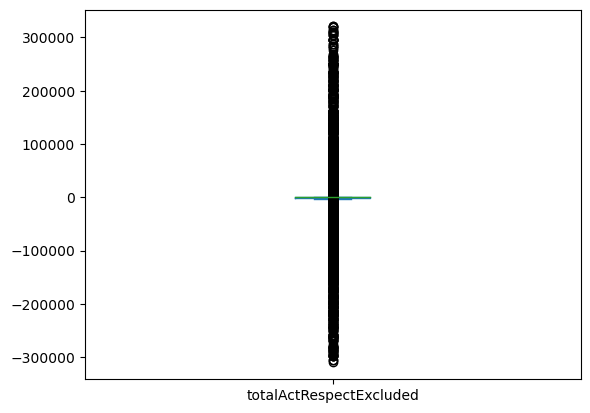

In [11]:
# - totalActRespectExcluded Analyzis
print("NA:", df['totalActRespectExcluded'].isna().sum())
tare = pd.to_numeric(df['totalActRespectExcluded'])
print(" 0:", (tare == 0).sum())
print(">0:", (tare > 0).sum())
print("<0:", (tare < 0).sum())
# print(sorted(tare[tare > 0]))
# tare[tare > 0].plot.box()
# tare[tare < tare.quantile(0.95)][tare > -tare.quantile(0.95)].plot.box()
print(tare.quantile(0.05), tare.quantile(0.95))
tare1 = tare[tare.between(tare.quantile(0.02), tare.quantile(0.98))]
tare1.plot.box()

40
3332


<AxesSubplot: xlabel='entrydate'>

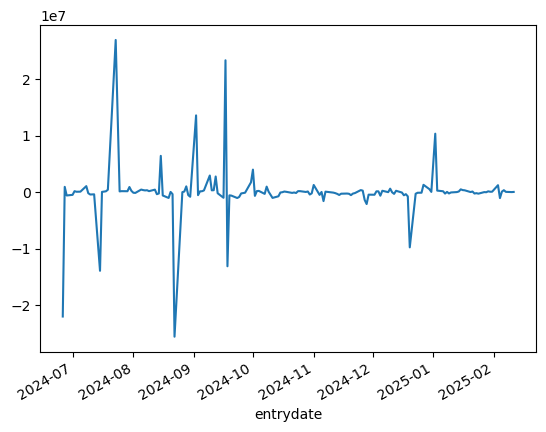

In [71]:
print(df1['totalActRespectExcluded'].isna().sum())
print(len(df1[df1['totalActRespectExcluded'] < 10]))
# tare[tare.between(tare.quantile(0.02), tare.quantile(0.98))]
vvv = df1[(df1['totalActRespectExcluded'] > 10000) | (df1['totalActRespectExcluded'] < -10000)]
# vvv = df1[df1['totalActRespectExcluded'].between(df1['totalActRespectExcluded'].quantile(0.02), df1['totalActRespectExcluded'].quantile(0.98))]
vvv['totalActRespectExcluded'].groupby(vvv['entrydate']).sum().plot()

<AxesSubplot: xlabel='entrydate'>

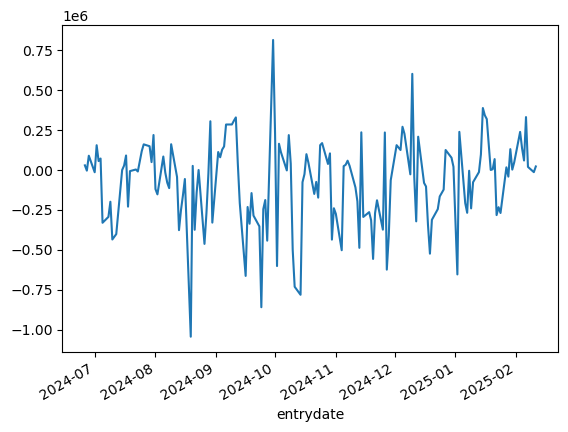

In [74]:
vvv = df1[df1['totalActRespectExcluded'].between(df1['totalActRespectExcluded'].quantile(0.02), df1['totalActRespectExcluded'].quantile(0.98))]
vvv['totalActRespectExcluded'].groupby(vvv['entrydate']).sum().plot()

<AxesSubplot: xlabel='entrydate'>

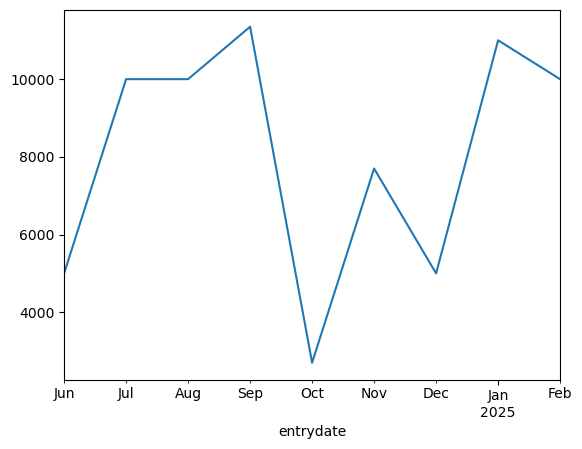

In [255]:
df1q = df1[df1['quantity'].between(df1['quantity'].quantile(0.02), df1['quantity'].quantile(0.98))]

df1q['quantity'].abs().groupby(df1q['entrydate'].dt.to_period('M')).median().plot()

<AxesSubplot: xlabel='entrydate'>

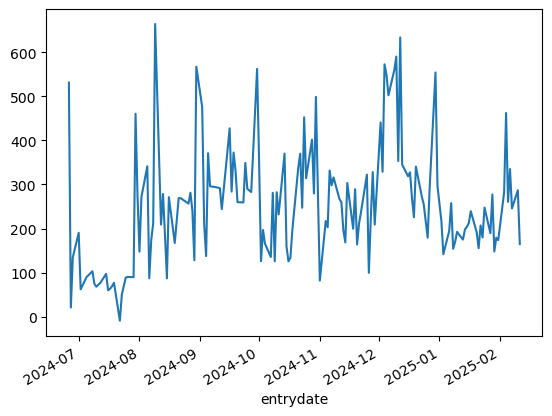

In [79]:
df1p= df1[df1['price'].between(df1['price'].quantile(0.01), df1['price'].quantile(0.99))]
df1p['price'].groupby(df1p['entrydate']).mean().plot()

In [104]:
# TIMESERIES diagrams
# 1) timeseries for sums of totalActRespectExcluded, price, quantity by entrydate
# 2) count of tradeID
# WHOLE/last week STATISTIC for: tradeType, tradeState
# Per TradeID statisitc PnL - what change from export to export files
# difference between TradeID between uploads

In [122]:
# df2.groupby(['tradeID']).price.mean()
print(df2.groupby(df2['entrydate'].dt.to_period('M'))['totalActRespectExcluded'].sum())
# print(df2.groupby(df2['entrydate'].dt.to_period('Y'))['totalActRespectExcluded'].sum())

entrydate
2024-06   -2.169528e+07
2024-07    1.506540e+07
2024-08   -2.042412e+07
2024-09    2.687745e+07
2024-10    3.081874e+06
2024-11   -7.331622e+06
2024-12   -1.032619e+07
2025-01    1.098022e+07
2025-02    4.063671e+05
Freq: M, Name: totalActRespectExcluded, dtype: float64


AxesSubplot(0.125,0.11;0.775x0.77)


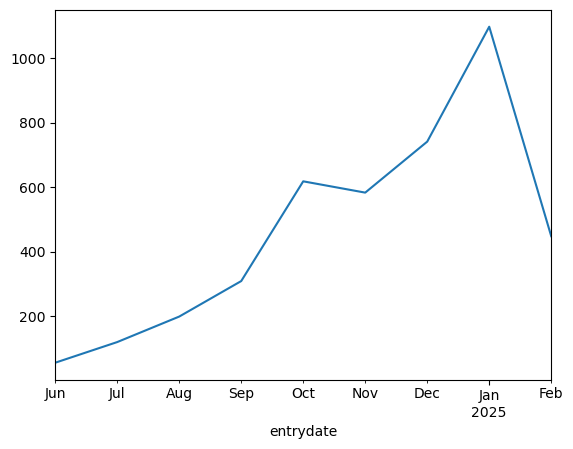

In [134]:
df2.groupby(df2['entrydate'].dt.to_period('M'))['tradeID'].nunique().plot()

<AxesSubplot: xlabel='entrydate'>

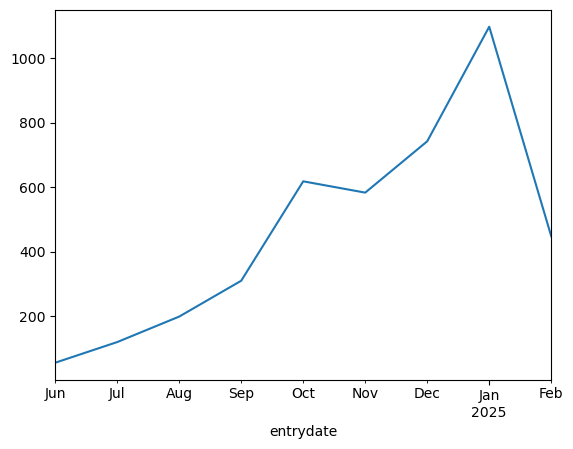

In [141]:
df2.groupby(df2['entrydate'].dt.to_period('M'))['item'].nunique().plot()

AxesSubplot(0.125,0.11;0.775x0.77)


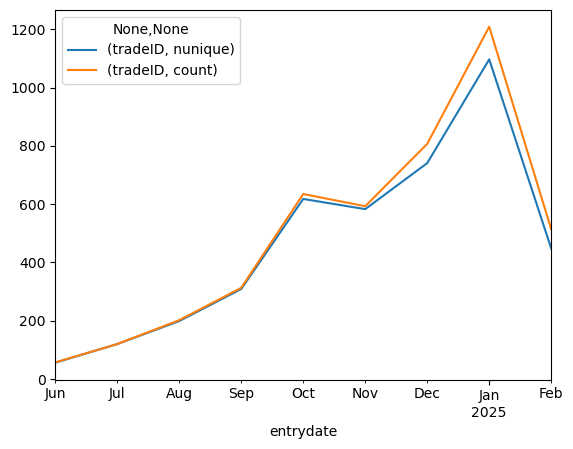

In [147]:
result = df2.groupby(df2['entrydate'].dt.to_period('M')).agg({
    'tradeID': ['nunique', 'count']
})

print(result.plot())

<AxesSubplot: title={'center': 'Percentage of tradeType'}, xlabel='entrydate'>

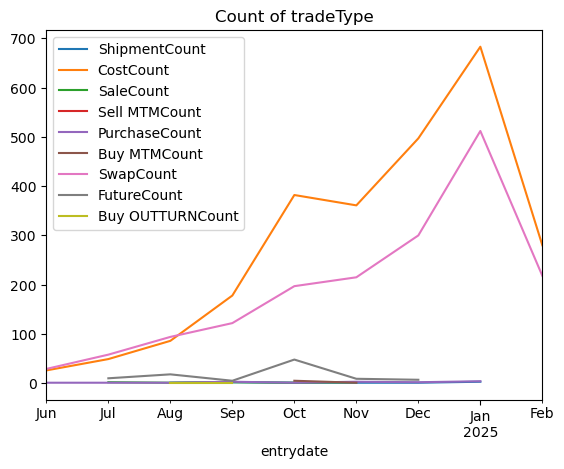

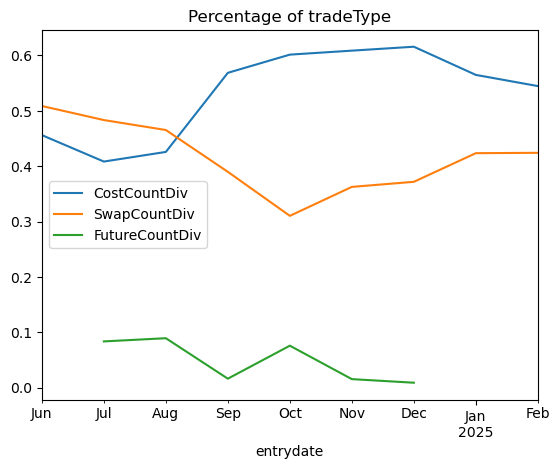

In [244]:
# - TradeTypes
from functools import reduce

def get_tradeType_unique_by_etrydate(df, period='M') -> pd.DataFrame:
    "Return ['entrydate', 'ShipmentUniq', 'ShipmentCount' ...]"
    df.tradeType.unique()
    dfs = []
    for x in df.tradeType.unique():
        result = df[df['tradeType'] == x].groupby(df['entrydate'].dt.to_period(period)).agg({
       'tradeID': ['nunique', 'count']
        })
        result.columns = ['_'.join(col).strip() for col in result.columns.values]
        result = result.reset_index()
        result.rename(columns={'tradeID_nunique':x+"Uniq", 'tradeID_count':x+"Count"}, inplace=True)
        dfs.append(result)
        # print(result)
        # result.plot(title=x)
    return reduce(lambda left, right: pd.merge(left, right, on='entrydate', how='outer'), dfs)

df_res = get_tradeType_unique_by_etrydate(df2)
# print(res.columns)
df_resc = df_res.filter(regex='(Count$|entrydate)', axis=1)
df_resc.plot(x='entrydate', title='Count of tradeType')

# - divide by all count
columns_to_divide = df_res.columns.str.endswith('Count')
columns_to_divide = df_res.columns[columns_to_divide]

crows = df2.groupby(df2['entrydate'].dt.to_period('M')).size()
crows = crows.rename("count")
# print(crows)
df_res.set_index('entrydate', inplace=True, drop=False, verify_integrity=True)
dfm = df_res.join(crows)
# merged = pd.concat([df_resc, crows], axis=1)
# print(dfm)
for col in columns_to_divide:
    dfm[col + 'Div'] = dfm[col] / dfm['count']
del dfm['count']
cols = []
for co in dfm.columns:
    if co != 'entrydate' and co.endswith('Div'):
        if dfm[co].sum()/len(dfm)> 0.01:
            cols.append(str(co))
            
dfm[cols + ['entrydate']].plot(x='entrydate', title="Percentage of tradeType")

    

In [276]:
print(dfmm.shape)
print(df1.columns)

(5009, 175)
Index(['item', 'Product', 'tradeState', 'tradeType', 'tradeID',
       'totalActRespectExcluded', 'currency', 'companyShortName', 'books',
       'parent strategy', 'Shipment Strategy ID', 'Shipment Strategy',
       'vessel', 'counterparty', 'quantity', 'quantityUoM', 'quantityMT',
       'ActualEstimated', 'incoterms', 'pricingFrom', 'pricingTo',
       'pricingMonth', 'pricingFormula', 'PricingCurrency', 'price', 'mtm',
       'location', 'broker', 'ticket', 'costcomment', 'company', 'titleevent',
       'titledate', 'blDate', 'norDate', 'codDate', 'tradeDate', 'conversion',
       'quantityBBLS', 'type', 'aspectInvoiceIdP', 'issueDateP',
       'InvoiceAmountP', 'invoiceReferenceP', 'taxAmountP', 'dueDateP',
       'provisonalPaymentTerms', 'paymentDateP', 'paidAmountP', 'bankAccountP',
       'invoiceVouchedByP', 'invoiceStateP', 'aspectInvoiceIdF', 'issueDateF',
       'InvoiceAmountF', 'invoiceReferenceF', 'taxAmountF', 'dueDateF',
       'finalPaymentTermsF', 'payme

In [269]:
dfmm['_merge'].value_counts()

_merge
both          4899
right_only     109
left_only        1
Name: count, dtype: int64

In [21]:
df1, df2, df = read_uploads(f1path,
                            f2path)
dfmm = df1.merge(df2, on=['item', 'tradeID', 'tradeState'], how='outer', suffixes=('_1', '_2'), indicator=True)
dfmm['_merge'].value_counts()
# print(dfmm[dfmm['_merge'] == 'both'])

/home/jup/juputils.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col] = df2[col].replace(r'^\s*$', np.nan, regex=True)
/home/jup/juputils.py:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col] = df2[col].replace(r'^\s*$', np.nan, regex=True)


_merge
both          4886
right_only     114
left_only        6
Name: count, dtype: int64

In [22]:
df1['composite_key'] = df1['item'].astype(str) + '_' + df1['tradeID'].astype(str)
df2['composite_key'] = df2['item'].astype(str) + '_' + df2['tradeID'].astype(str)

# 2. Merge the DataFrames
# 2. Merge the DataFrames
merged = df1.merge(df2, on='composite_key', how='outer', suffixes=('_1', '_2'))

diff_columns = [col for col in df1.columns if col not in ['item', 'tradeID', 'composite_key'] and col not in merged.columns]
print(diff_columns)


['Product', 'tradeState', 'tradeType', 'totalActRespectExcluded', 'currency', 'companyShortName', 'books', 'vessel', 'counterparty', 'quantity', 'quantityUoM', 'quantityMT', 'ActualEstimated', 'incoterms', 'pricingFrom', 'pricingTo', 'pricingMonth', 'pricingFormula', 'PricingCurrency', 'price', 'mtm', 'location', 'broker', 'ticket', 'costcomment', 'company', 'titleevent', 'titledate', 'blDate', 'norDate', 'codDate', 'tradeDate', 'conversion', 'quantityBBLS', 'type', 'aspectInvoiceIdP', 'issueDateP', 'InvoiceAmountP', 'invoiceReferenceP', 'taxAmountP', 'dueDateP', 'provisonalPaymentTerms', 'paymentDateP', 'paidAmountP', 'bankAccountP', 'invoiceVouchedByP', 'invoiceStateP', 'aspectInvoiceIdF', 'issueDateF', 'InvoiceAmountF', 'invoiceReferenceF', 'taxAmountF', 'dueDateF', 'finalPaymentTermsF', 'paymentDateF', 'paidAmountF', 'bankAccountF', 'invoiceVouchedByF', 'invoiceStateF', 'vatGST', 'balancedue', 'totalAct', 'financingBank', 'creditType', 'letterOfCredit', 'lcIssuingBank', 'lcIssuingB

In [23]:
# 3. Identify differences
def compare_columns(row, col):
    val1 = row[f'{col}_1']
    val2 = row[f'{col}_2']
    if pd.isna(val1) and pd.isna(val2):
        return np.nan
    elif pd.isna(val1) or pd.isna(val2):
        return True
    else:
        return val1 != val2

for col in diff_columns:
    merged[f'diff_{col}'] = merged.apply(lambda row: compare_columns(row, col), axis=1)

# 4. Analyze differences
diff_count = merged[merged[[f'diff_{col}' for col in diff_columns]].any(axis=1)].shape[0]  # Use shape to get the number of rows
total_rows = max(len(df1), len(df2))
print(diff_count)

1527


In [24]:
total_rows = max(len(df1), len(df2))
print(total_rows)
diff_percentage = (diff_count / total_rows) * 100

print(f"Number of differing rows: {diff_count}")
print(f"Percentage of differing rows: {diff_percentage:.2f}%")
# print(f"Columns with differences: {diff_columns}")

4450
Number of differing rows: 1527
Percentage of differing rows: 34.31%


In [25]:
# 5. Detailed analysis of differences
for col in diff_columns:
    col_diff = merged[merged[f'diff_{col}'] == True]
    print(f"\nDifferences in {col}:")
    print(col_diff[[f"{col}_1", f"{col}_2"]])
    print(f"Total differences: {len(col_diff)}")



Differences in Product:
     Product_1   Product_2
1278       NaN   Brokerage
1279       NaN  COMMISSION
1280       NaN   Brokerage
1281       NaN  COMMISSION
1282       NaN   Brokerage
...        ...         ...
5004       NaN      GasOil
5005       NaN      GasOil
5006       NaN      GasOil
5007       NaN      GasOil
5008       NaN      GasOil

[114 rows x 2 columns]
Total differences: 114

Differences in tradeState:
     tradeState_1 tradeState_2
1278          NaN     commited
1279          NaN     commited
1280          NaN     commited
1281          NaN     commited
1282          NaN     commited
...           ...          ...
5004          NaN     commited
5005          NaN     commited
5006          NaN     commited
5007          NaN     commited
5008          NaN     commited

[123 rows x 2 columns]
Total differences: 123

Differences in tradeType:
     tradeType_1 tradeType_2
1278         NaN        Cost
1279         NaN        Cost
1280         NaN        Cost
1281         N


Differences in hierarchies:
     hierarchies_1   hierarchies_2
1278           NaN      2025 Mogas
1279           NaN      2025 Mogas
1280           NaN       2025 Flow
1281           NaN       2025 Flow
1282           NaN       2025 Flow
...            ...             ...
5004           NaN  2025 Nuvo Spec
5005           NaN  2025 Nuvo Spec
5006           NaN  2025 Nuvo Spec
5007           NaN  2025 Nuvo Spec
5008           NaN  2025 Nuvo Spec

[566 rows x 2 columns]
Total differences: 566


In [26]:
# 6. Identify rows present in one DataFrame but not in the other
only_in_df1 = merged[merged.filter(regex='_2$').isna().all(axis=1)]
only_in_df2 = merged[merged.filter(regex='_1$').isna().all(axis=1)]

print(f"\nRows only in df1: {len(only_in_df1)}")
print(f"Rows only in df2: {len(only_in_df2)}")



Rows only in df1: 1
Rows only in df2: 109


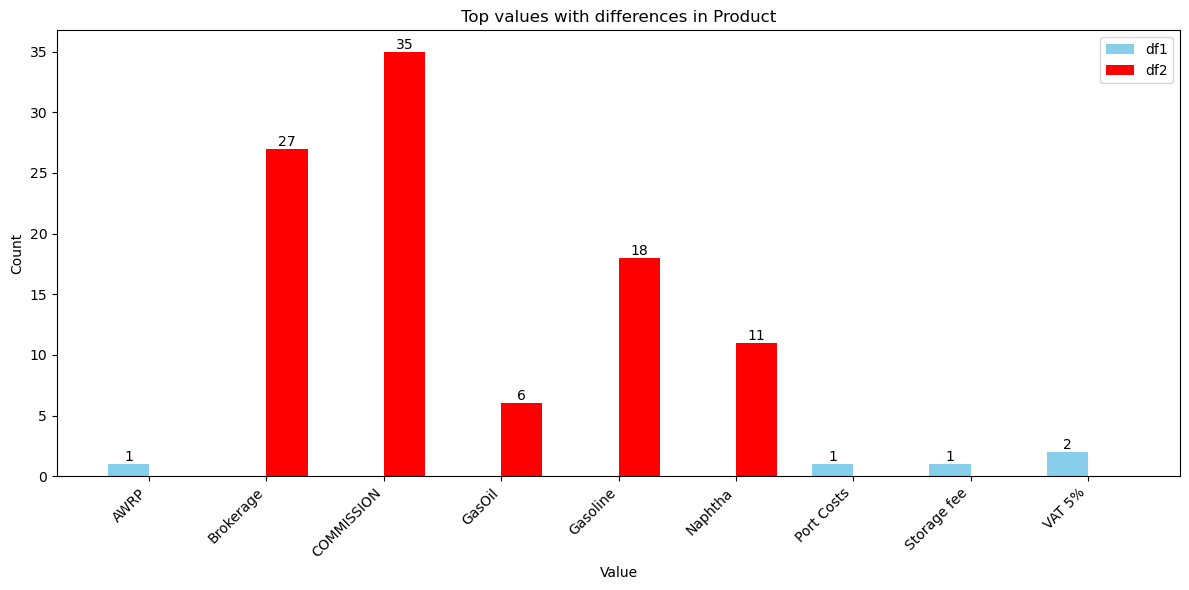

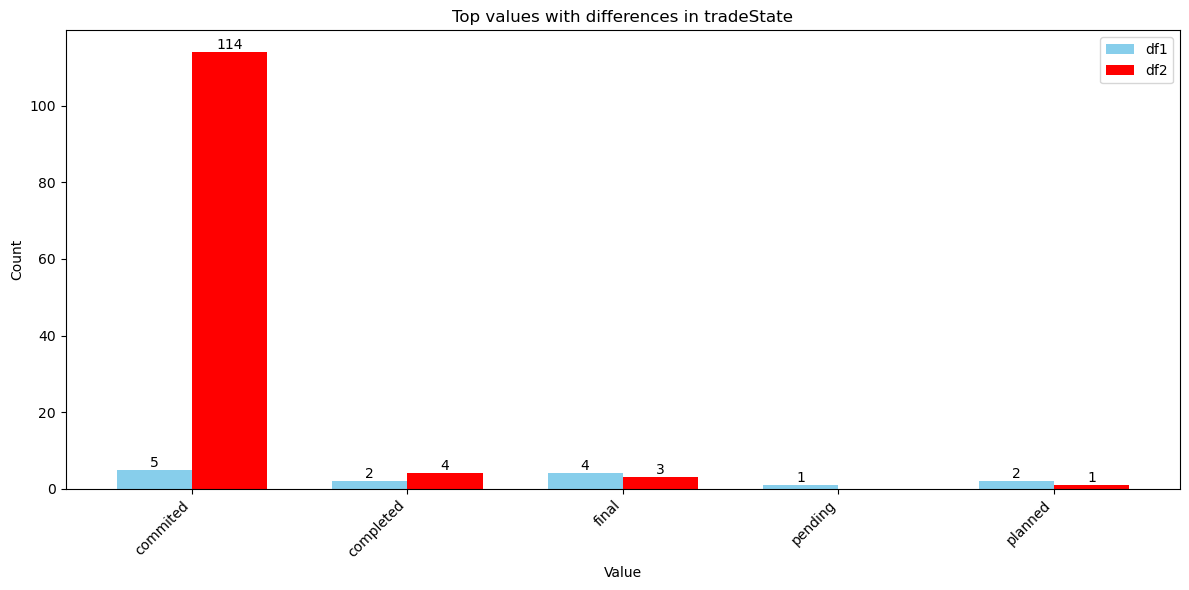

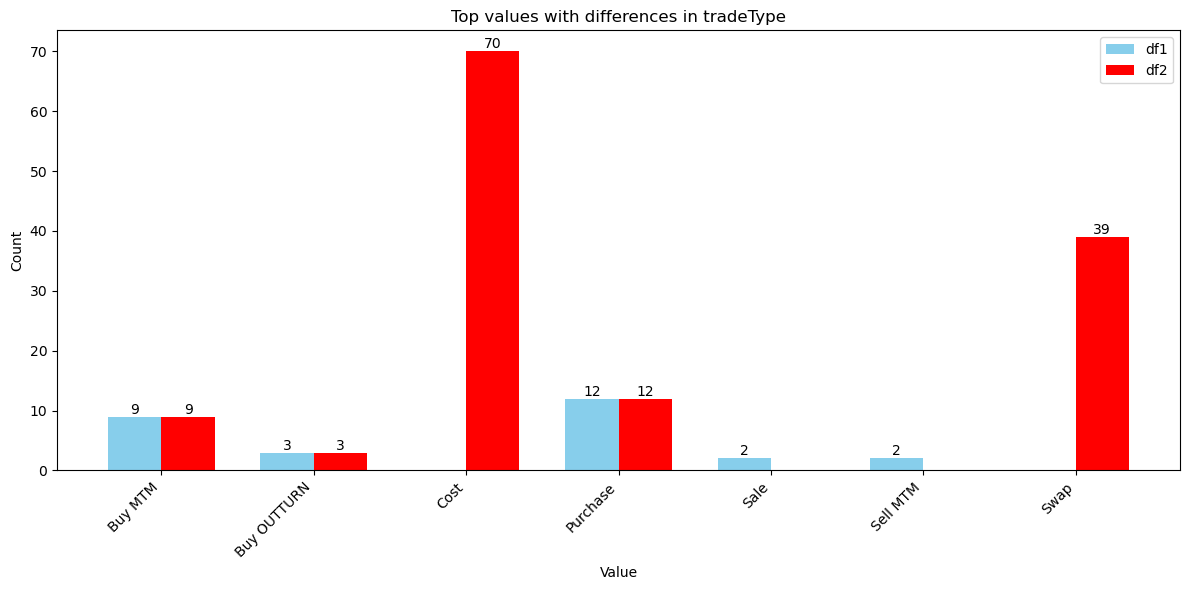

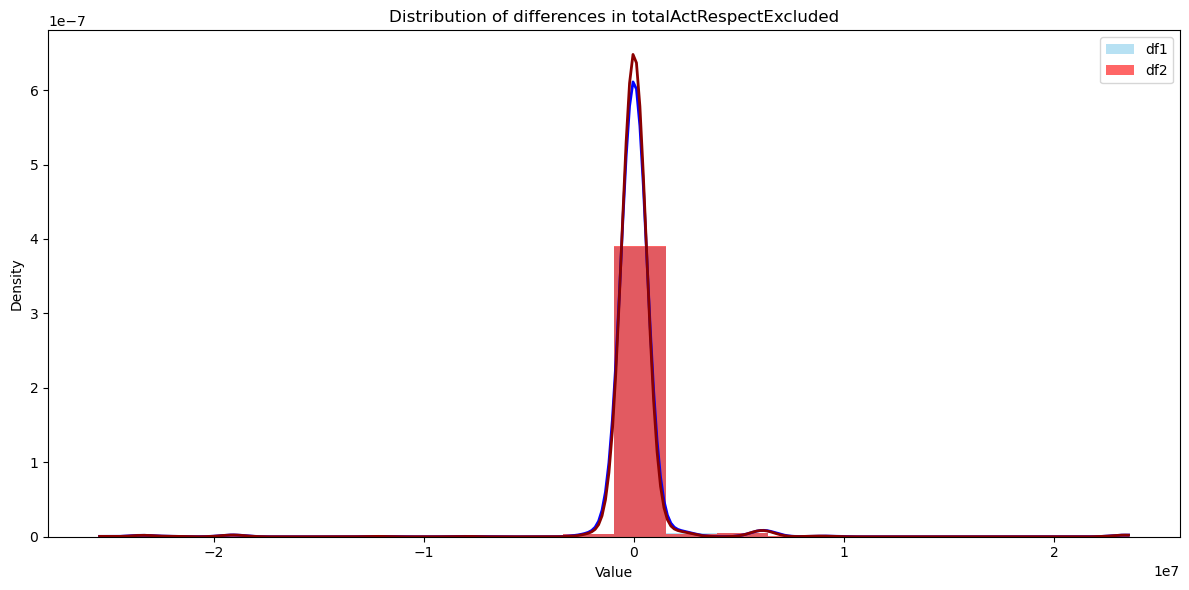

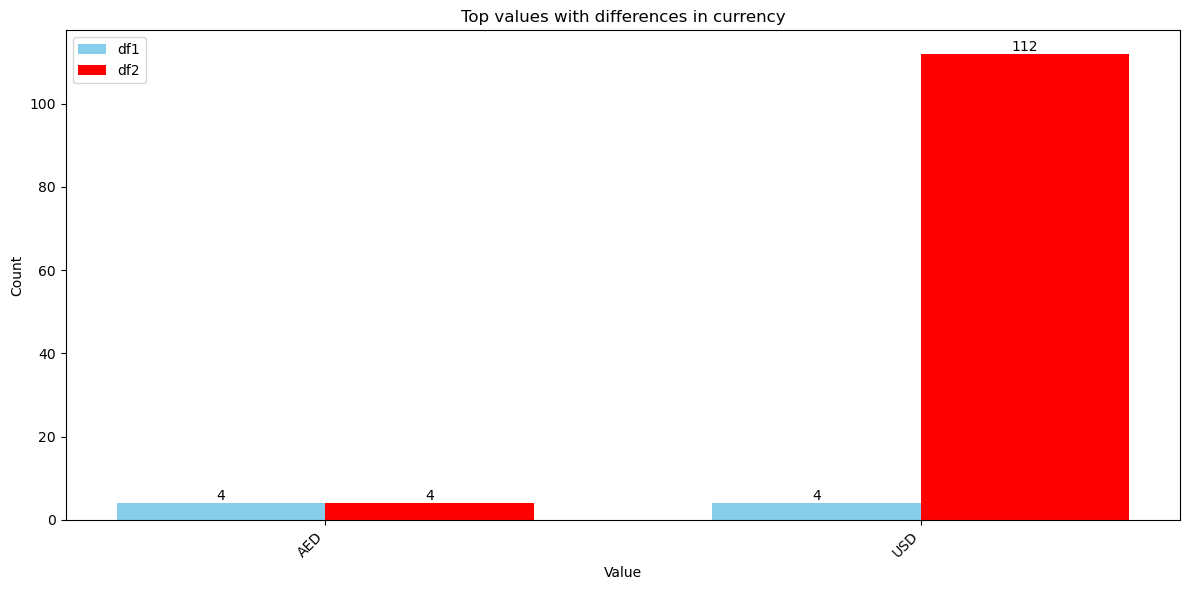

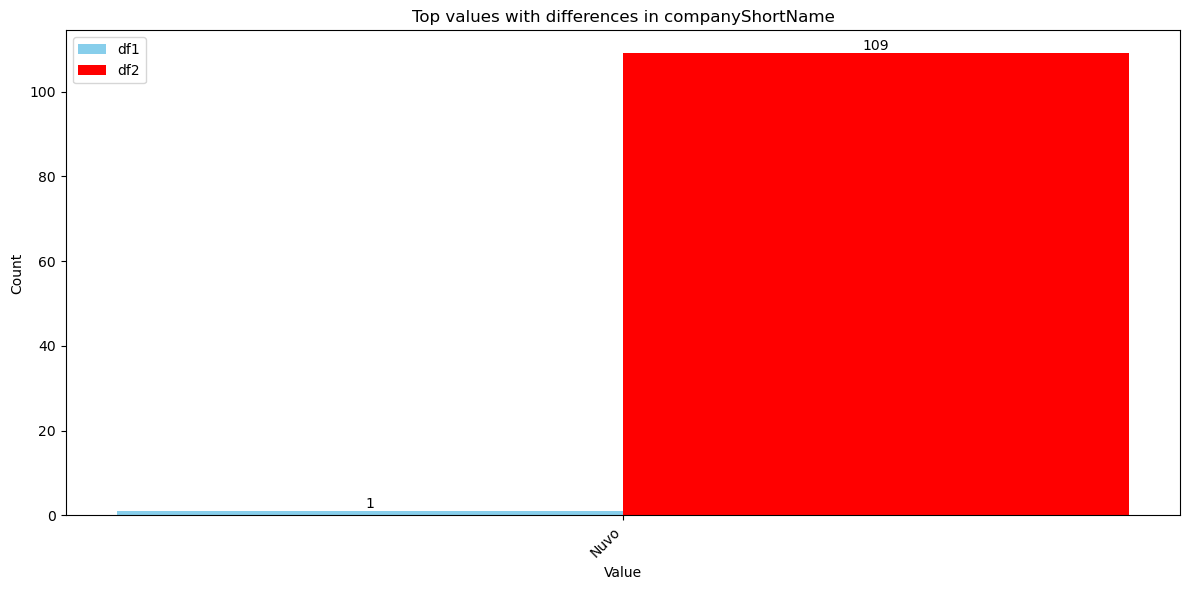

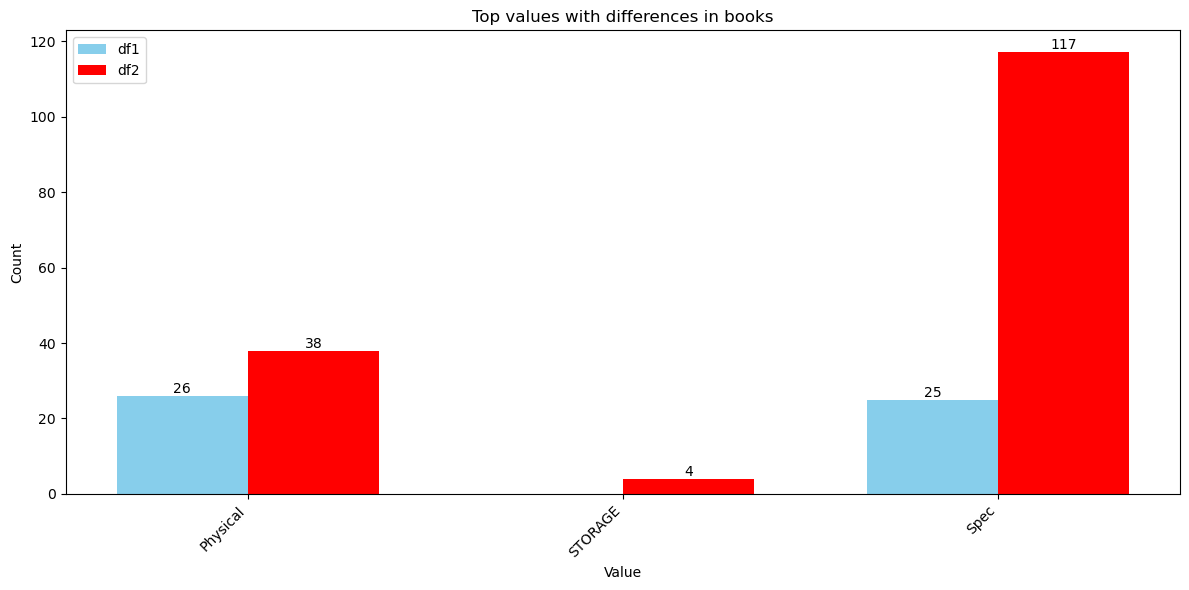

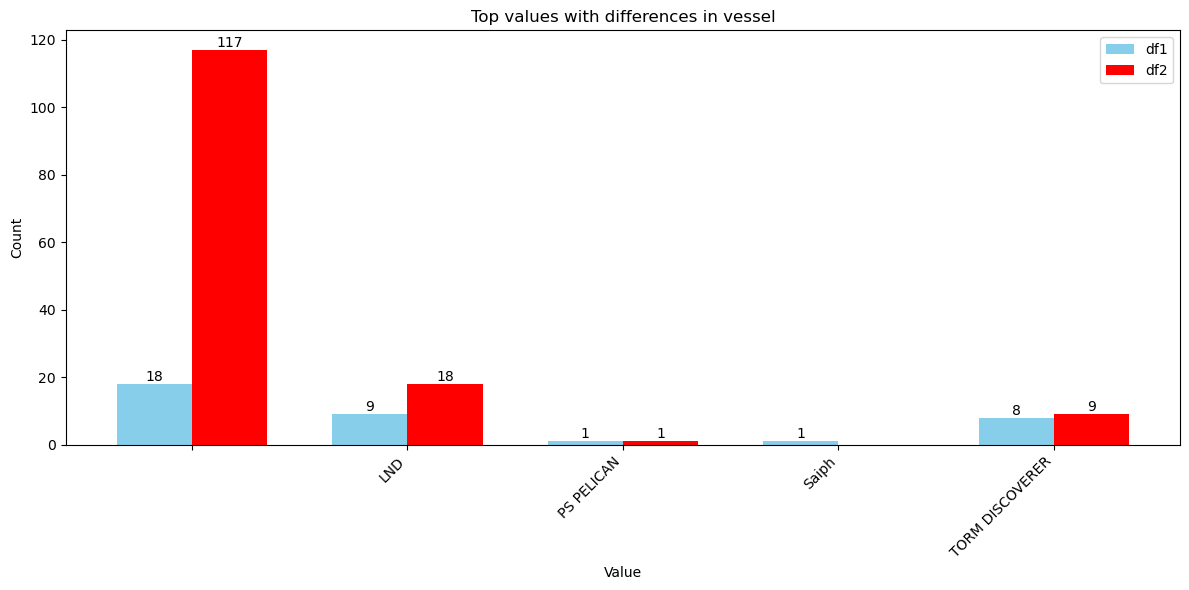

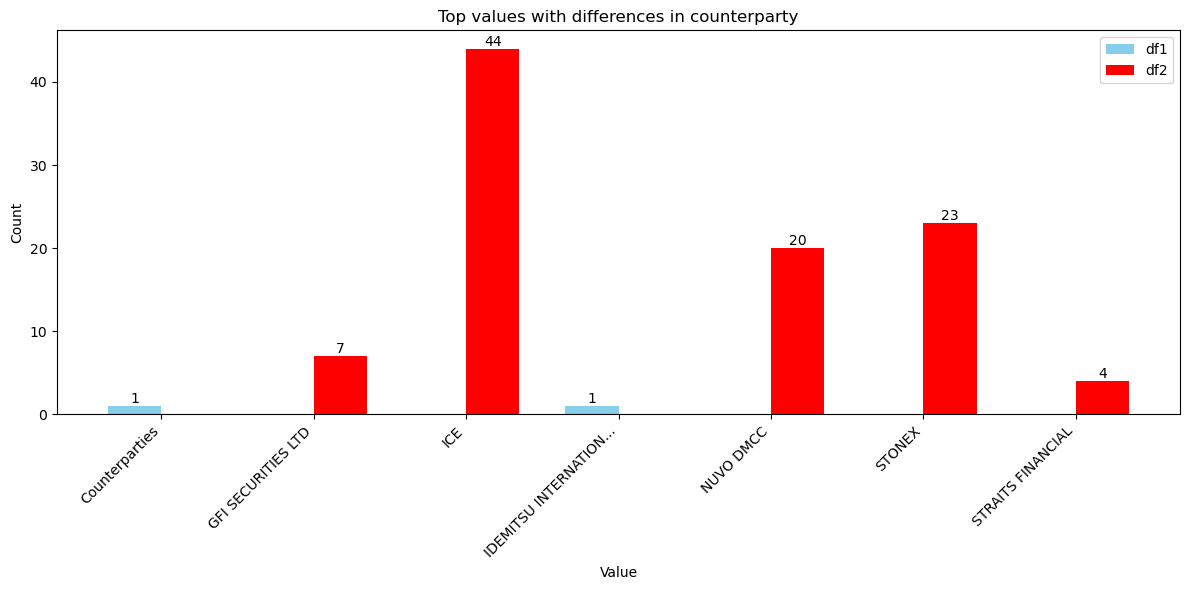

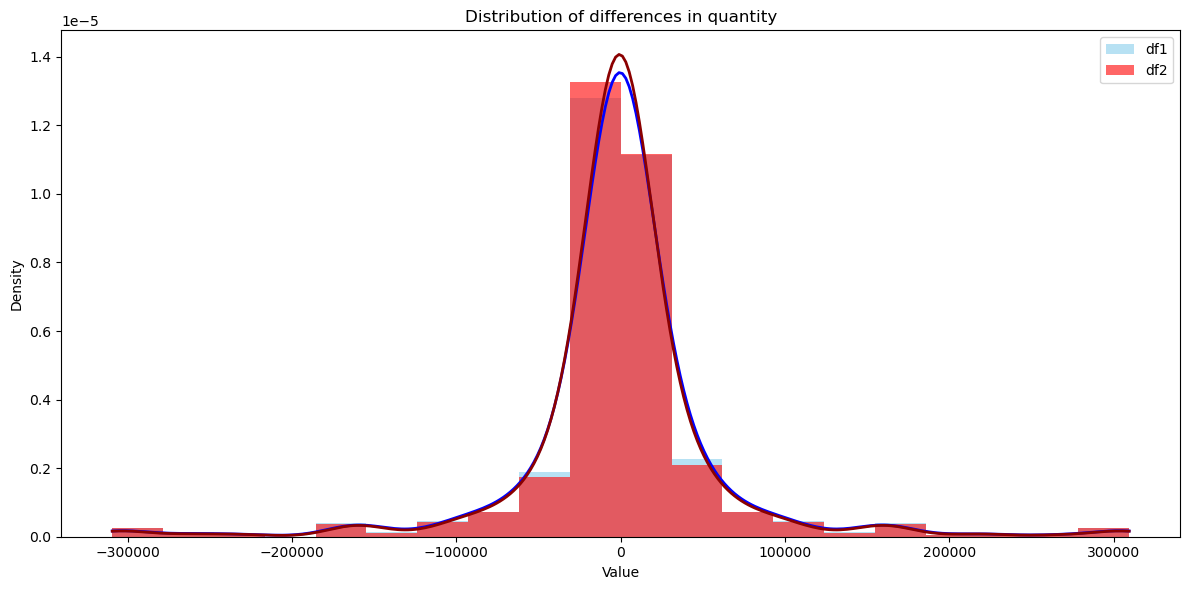

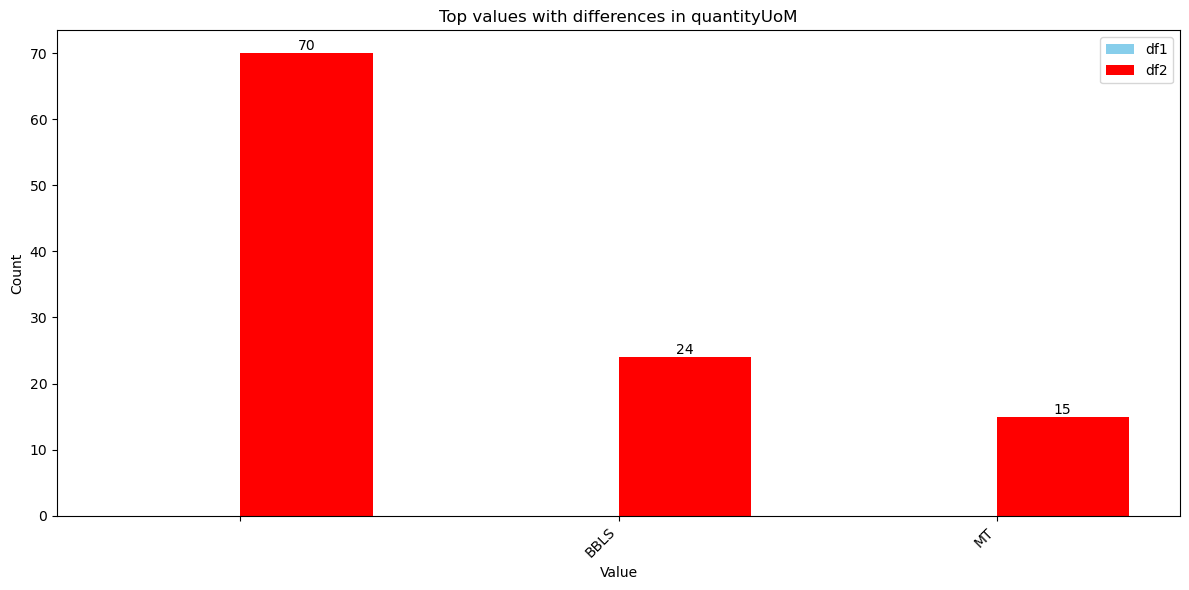

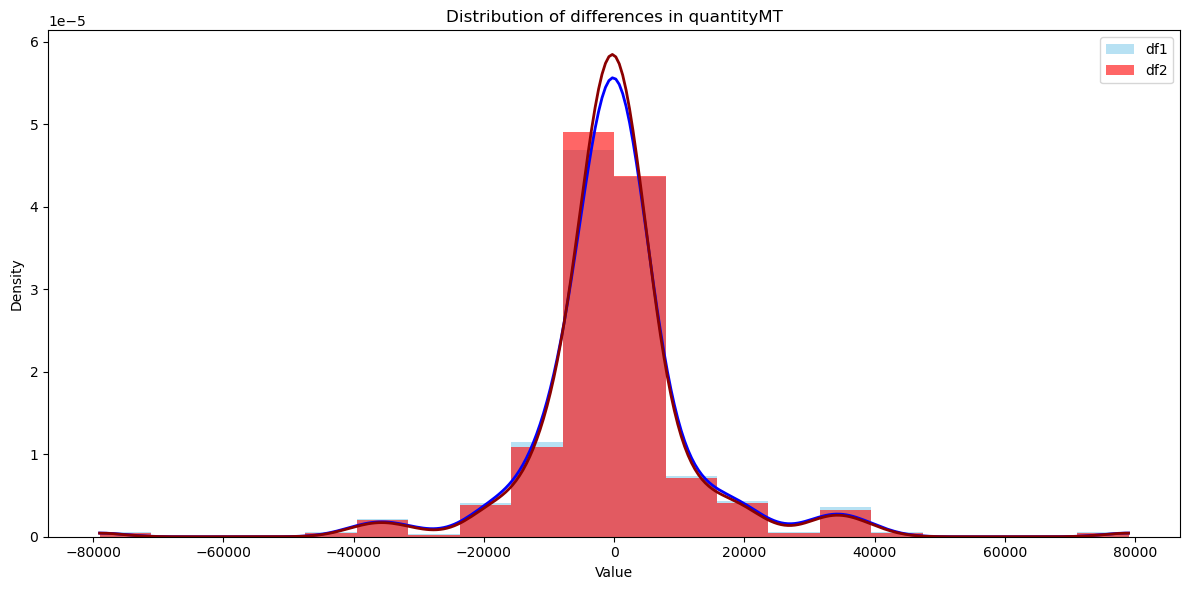

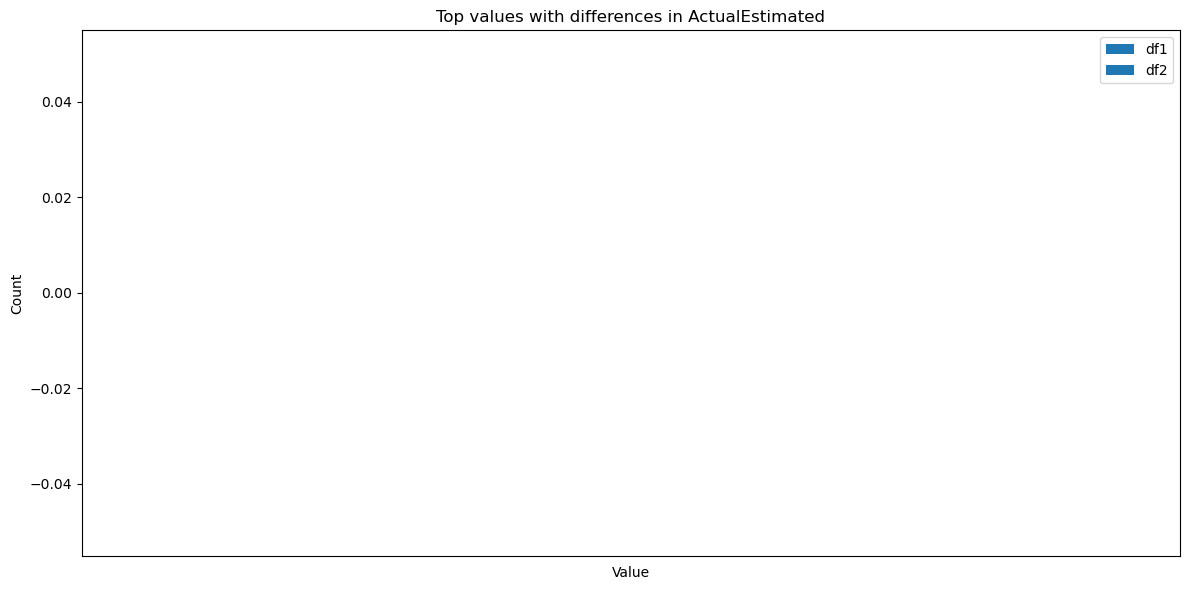

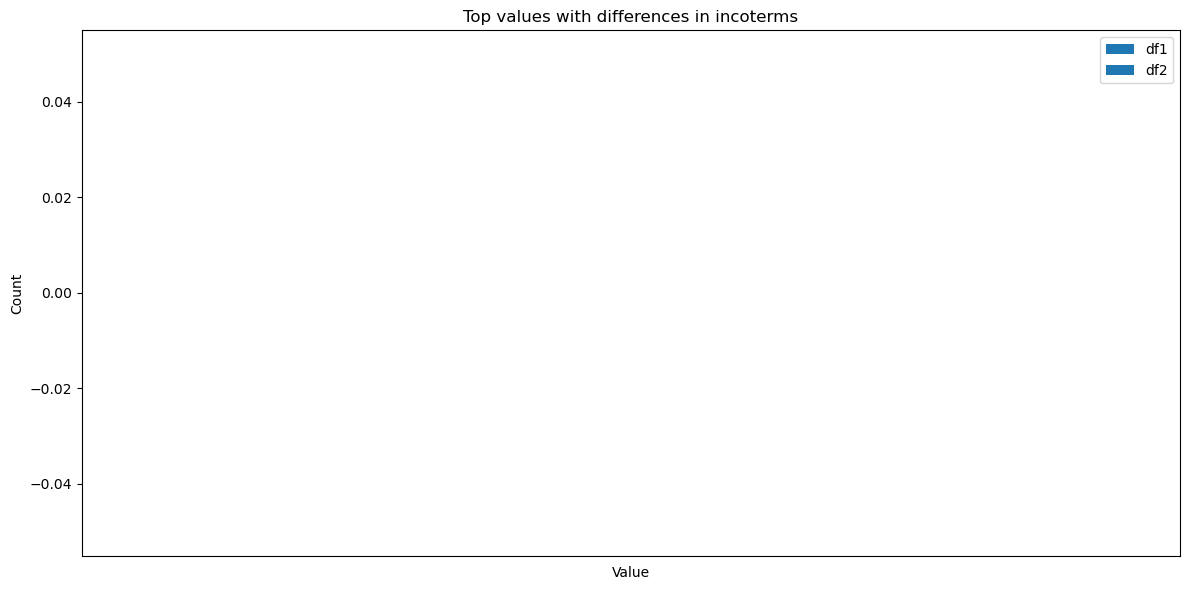

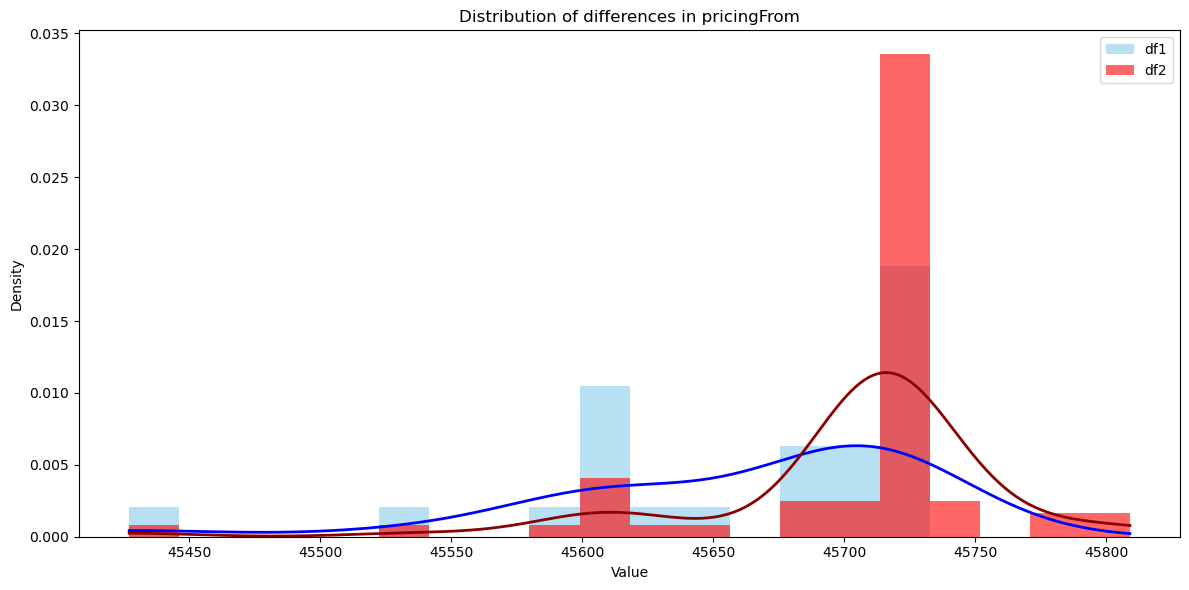

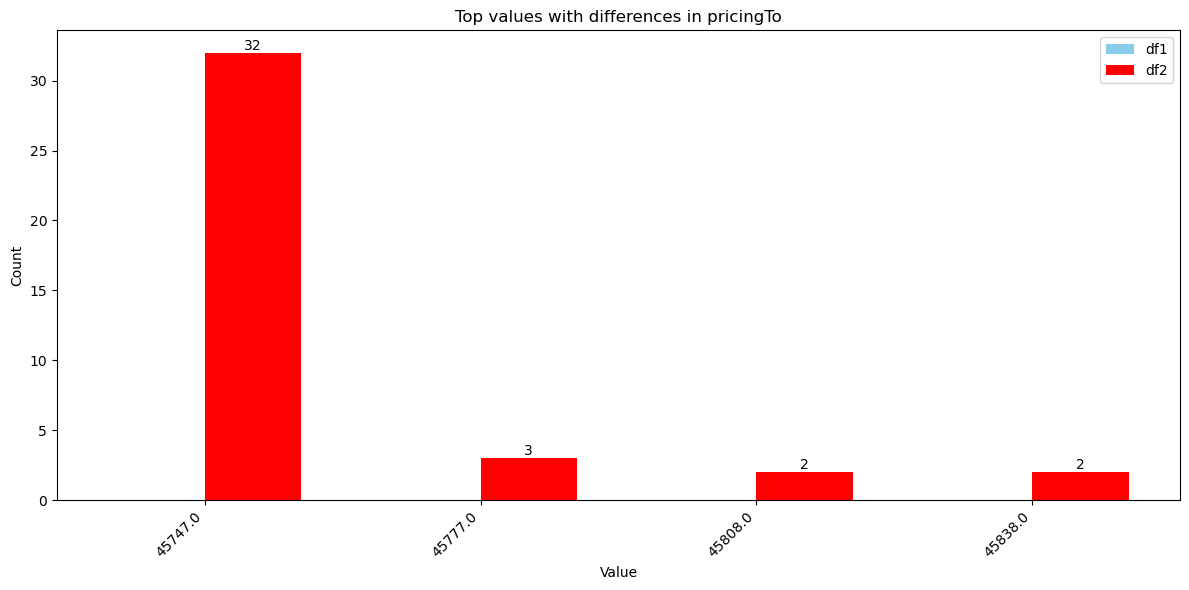

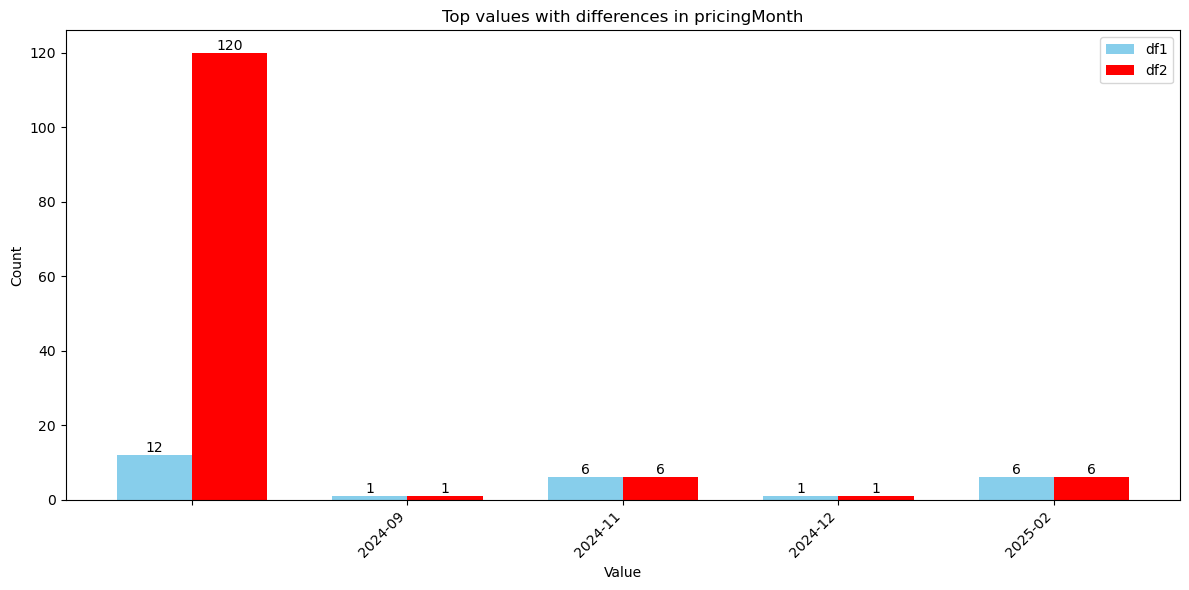

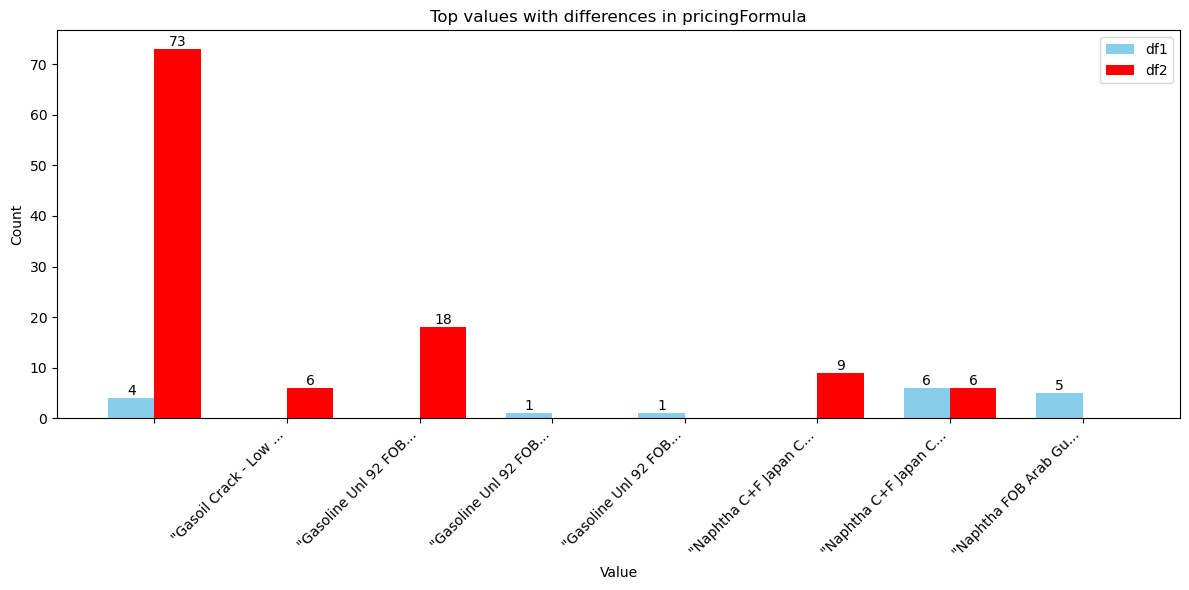

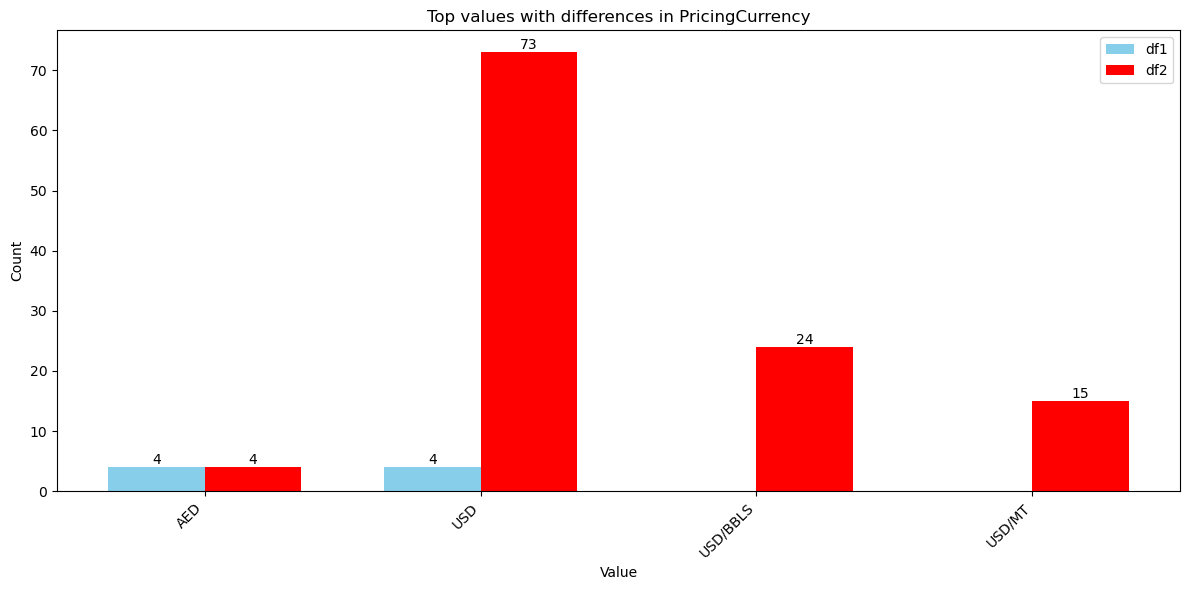

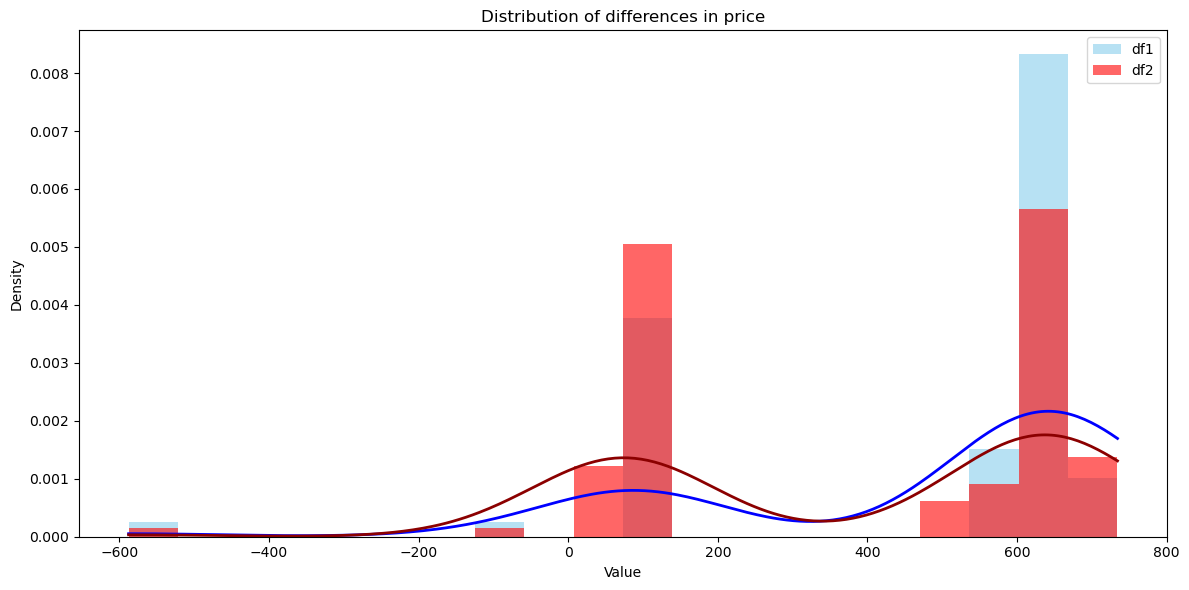

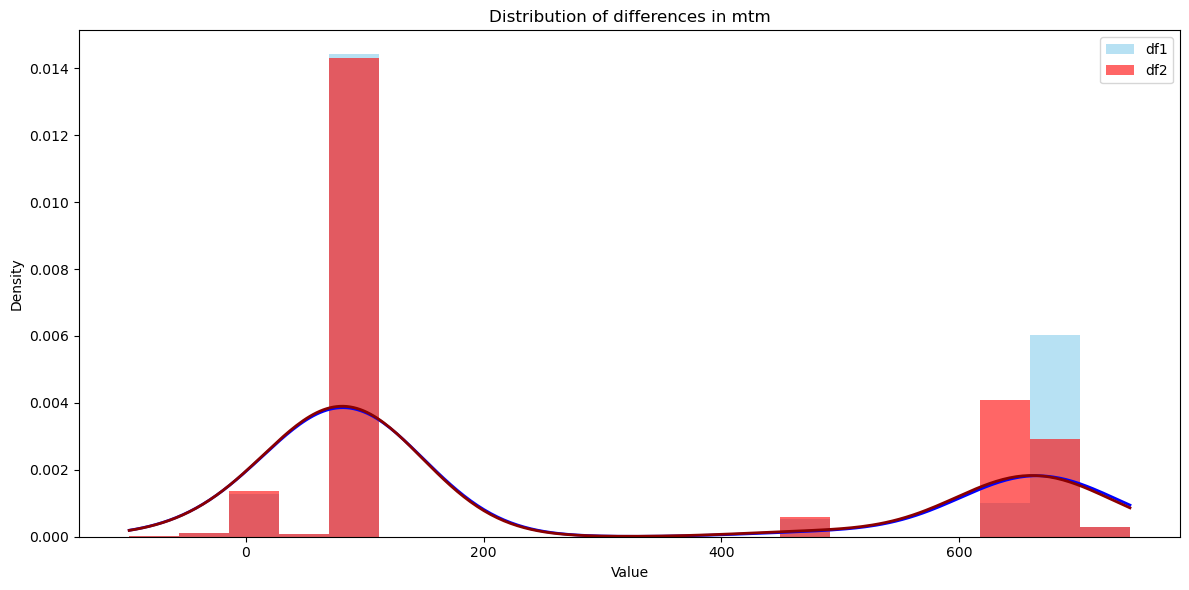

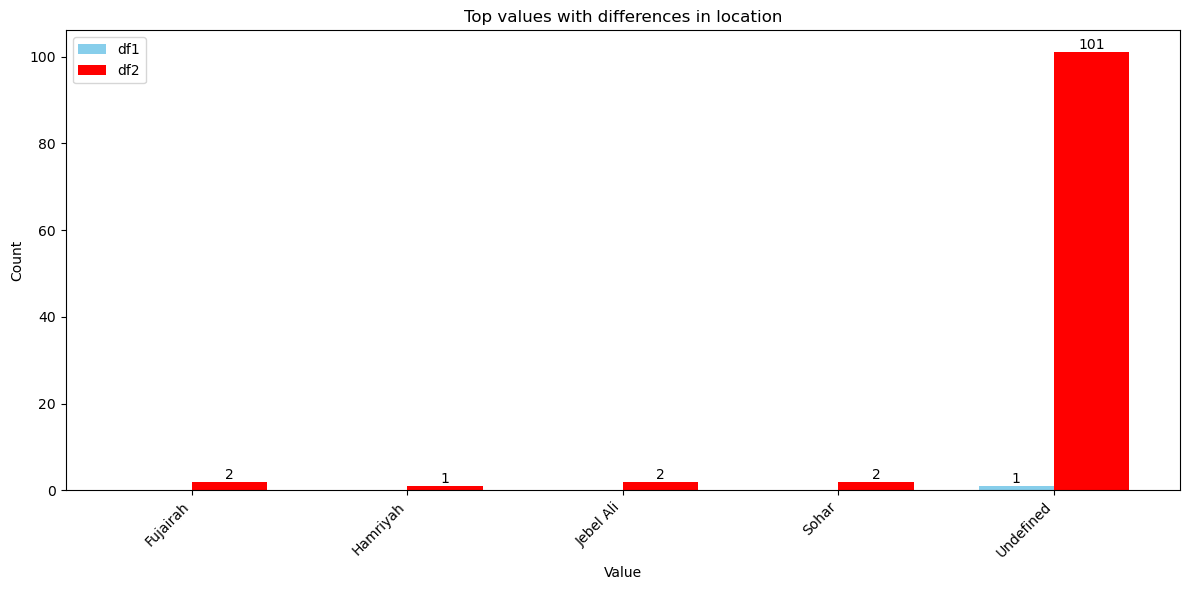

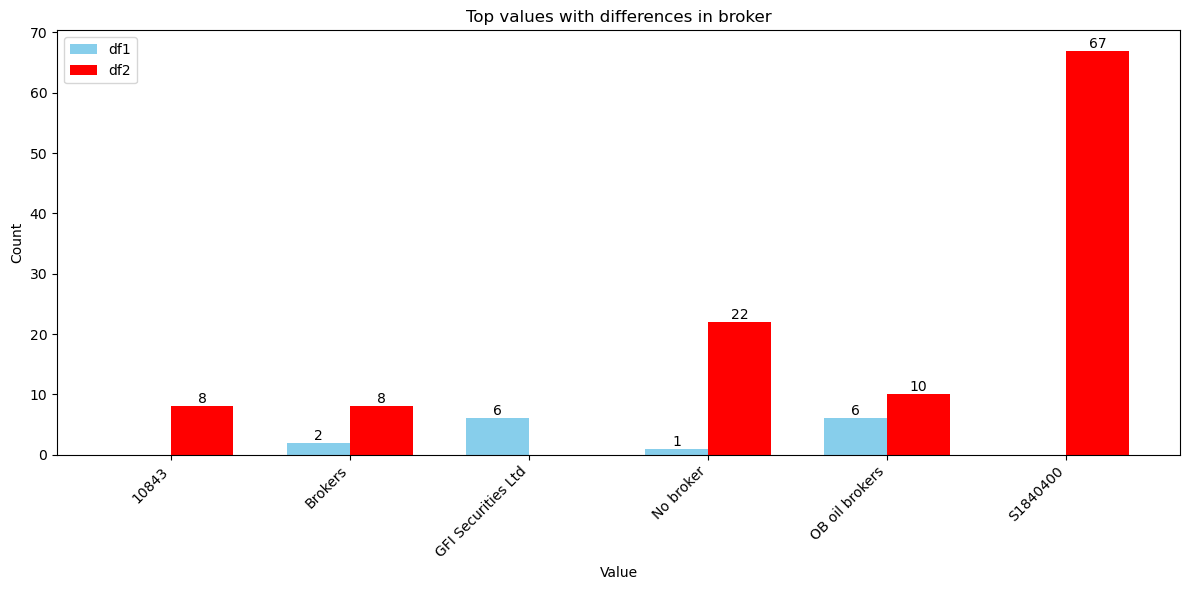

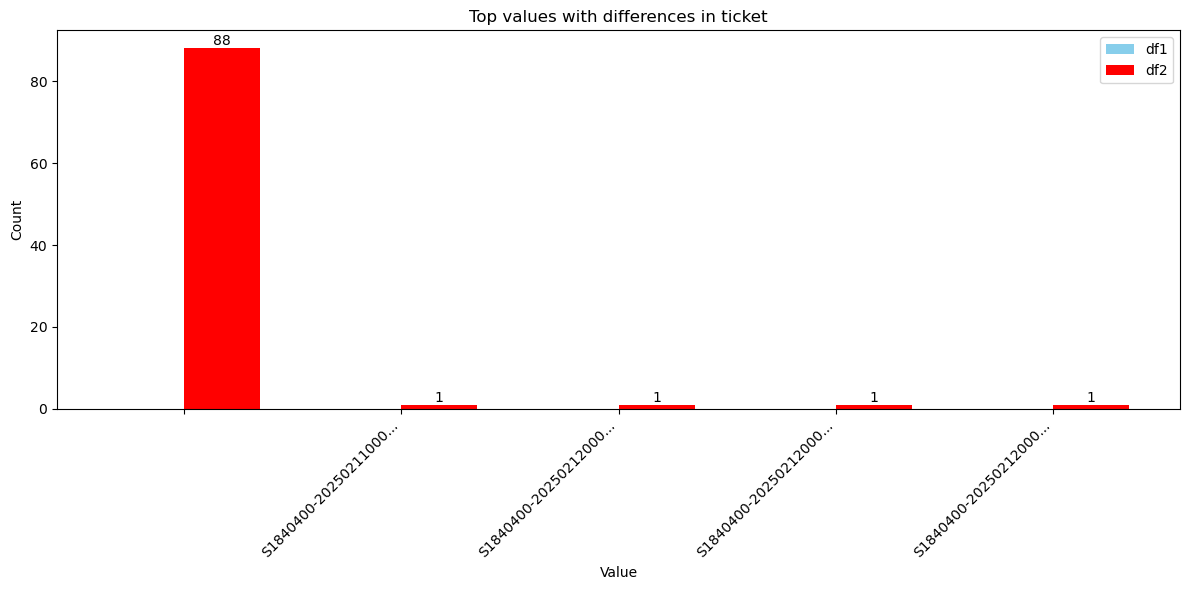

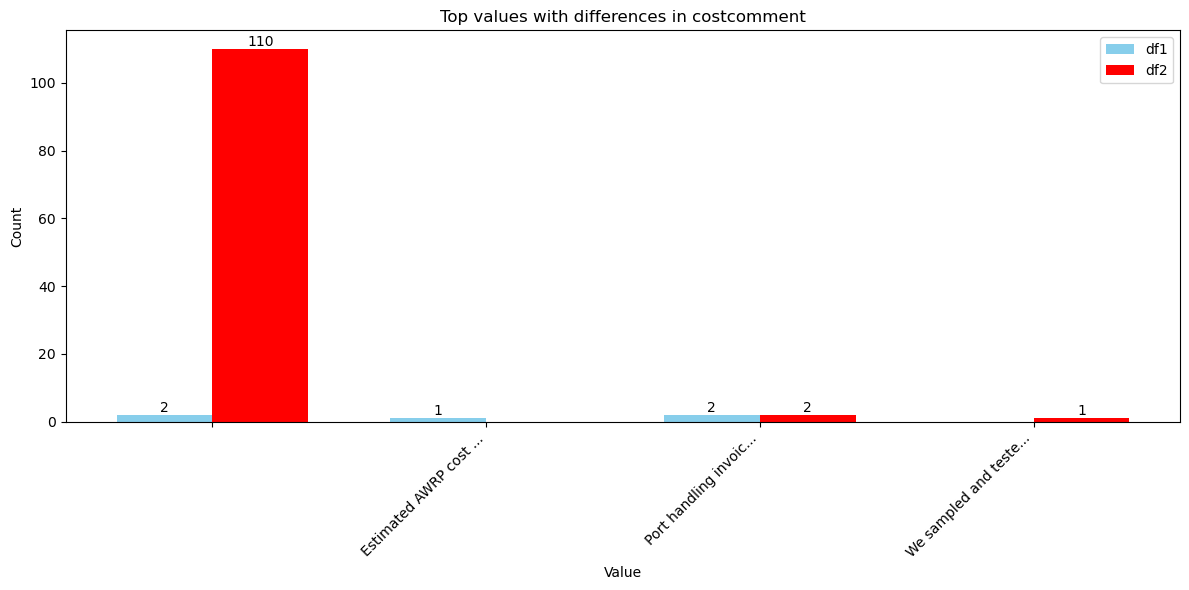

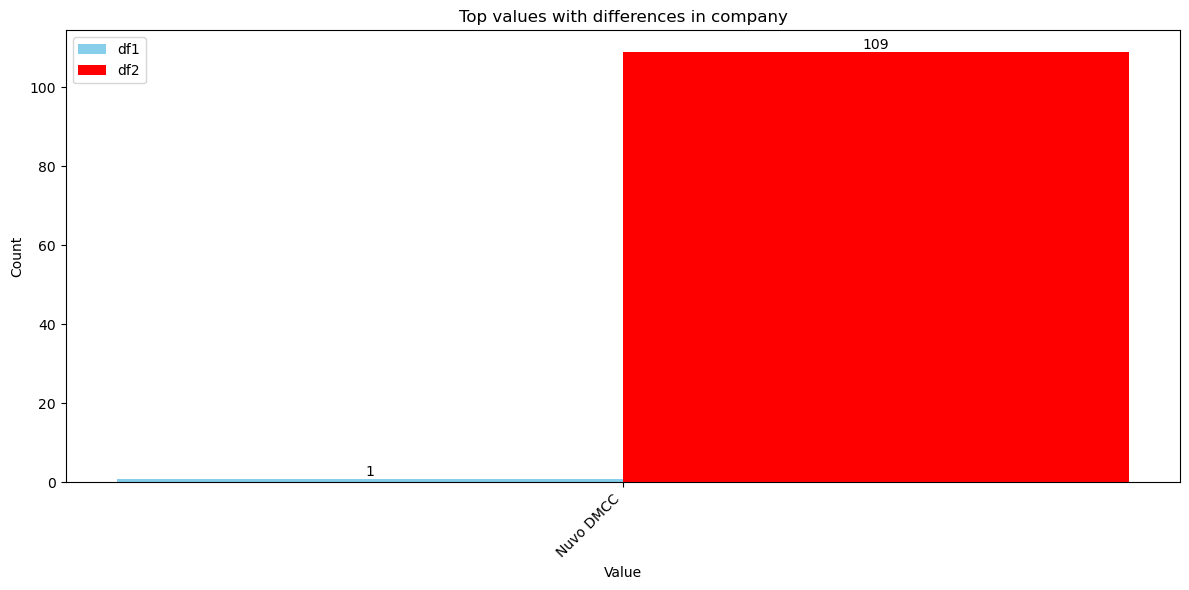

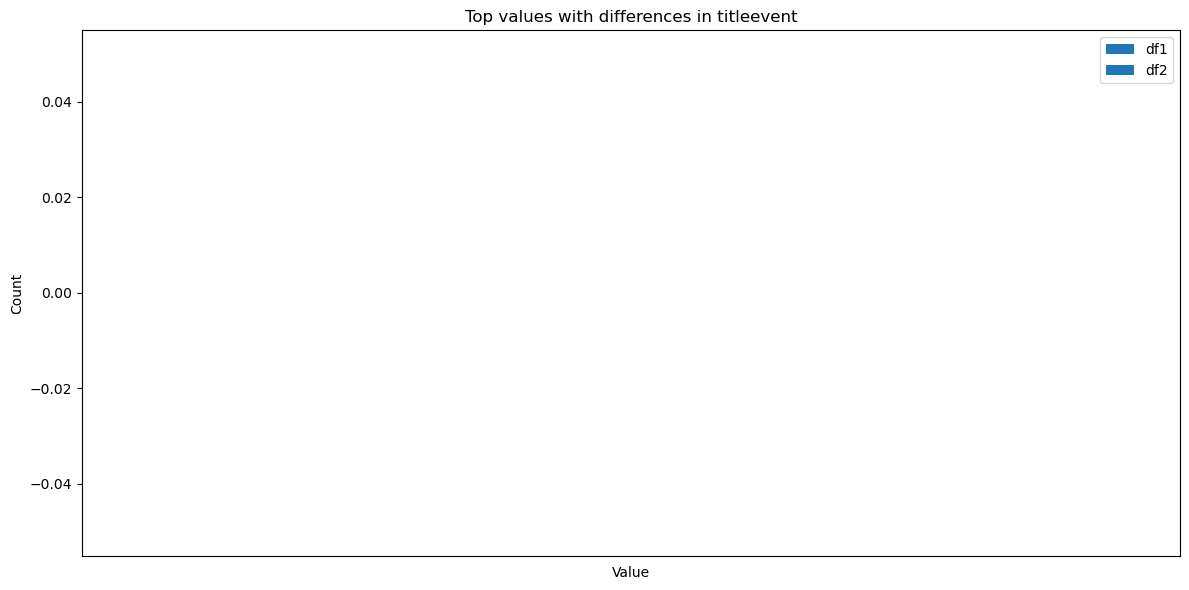

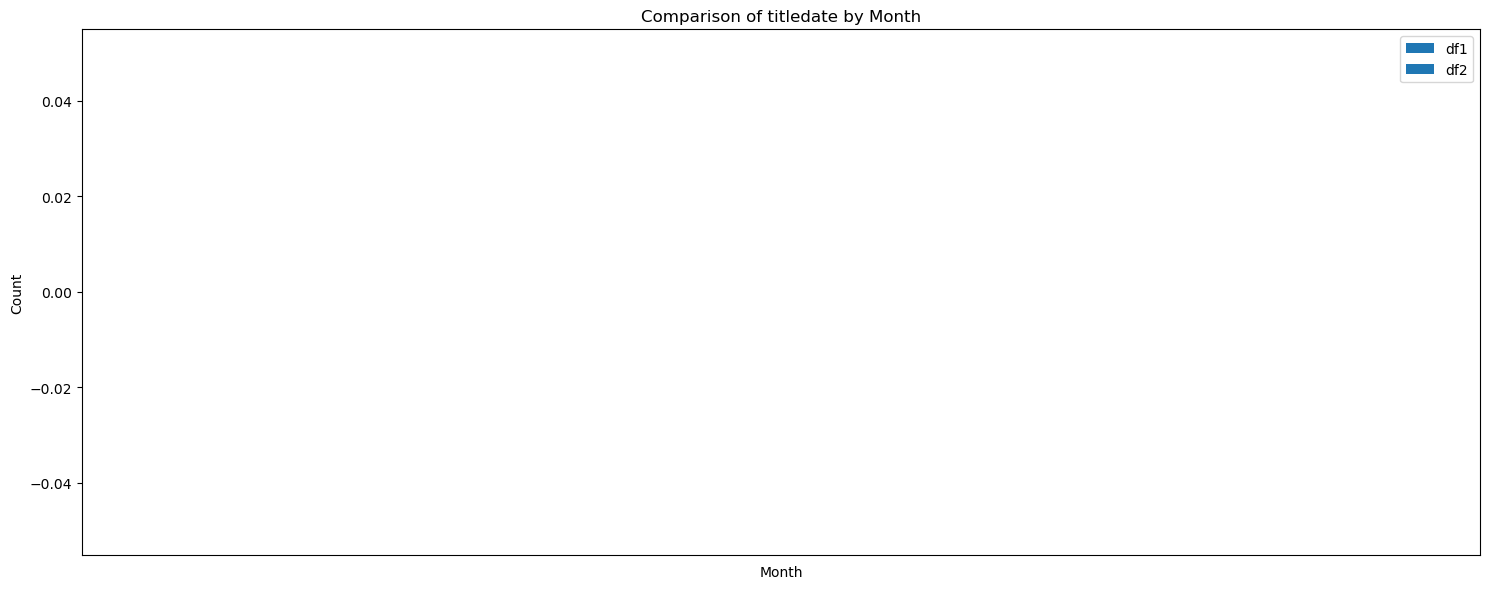

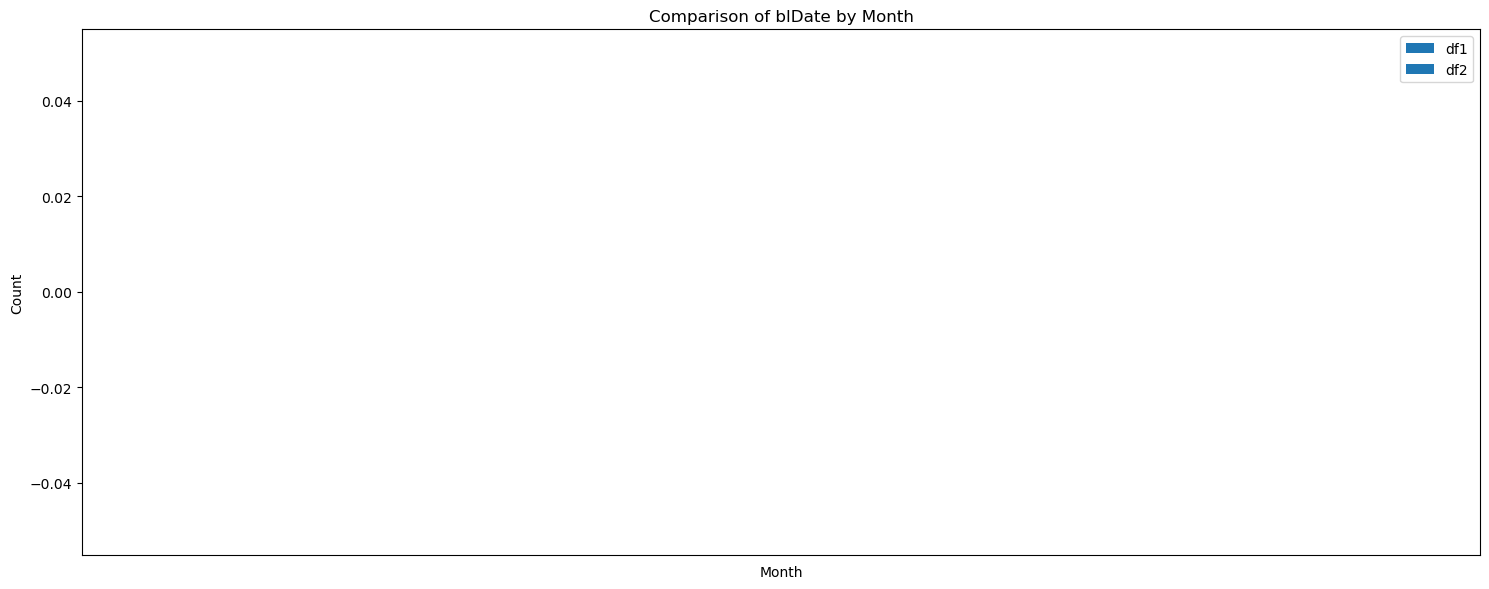

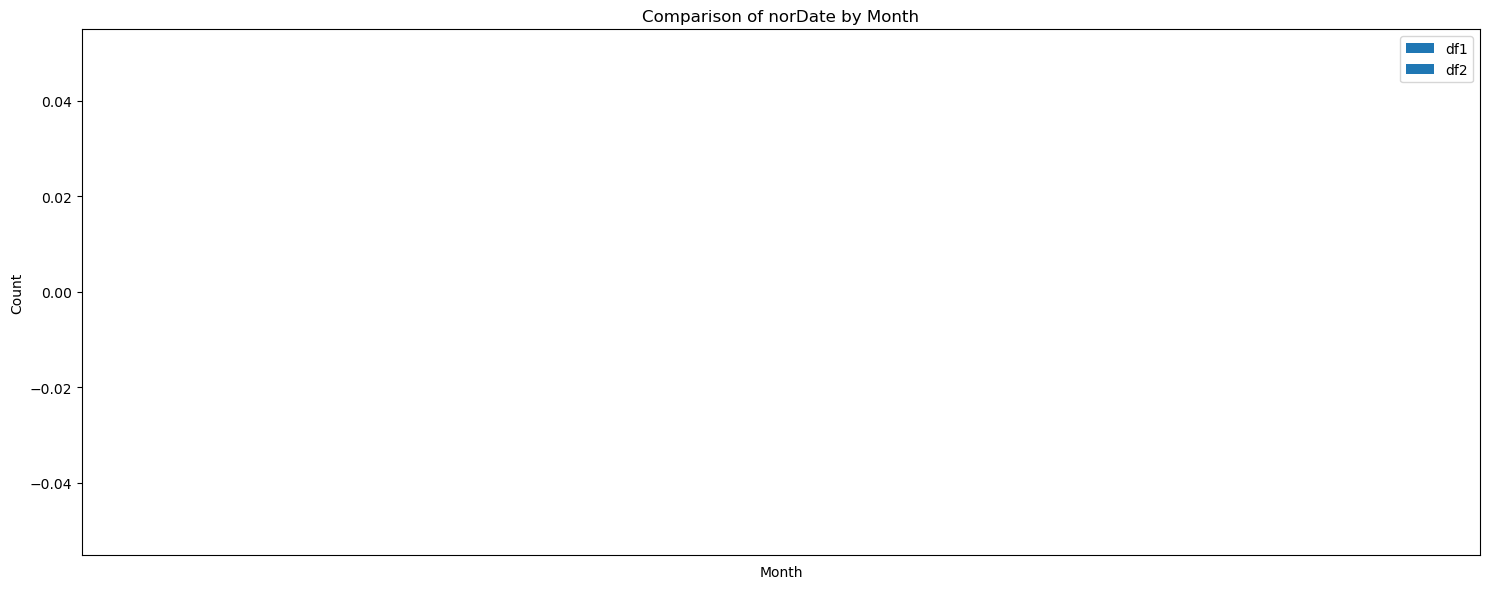

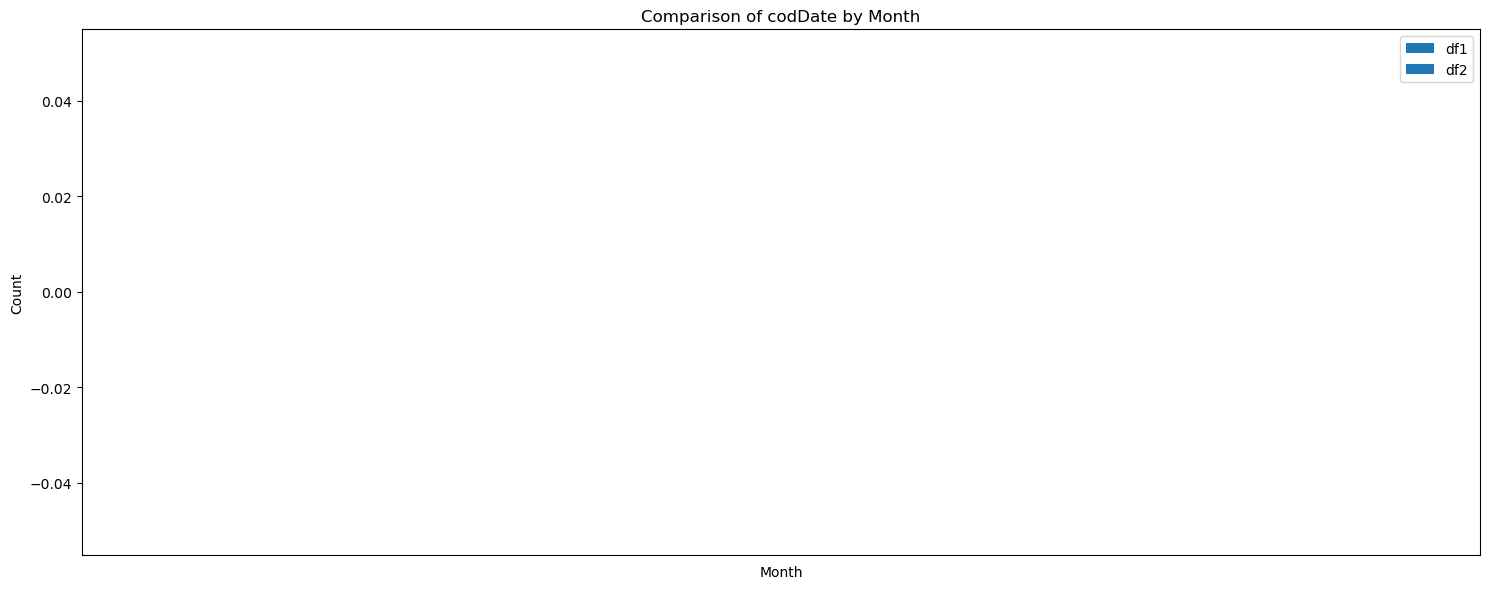

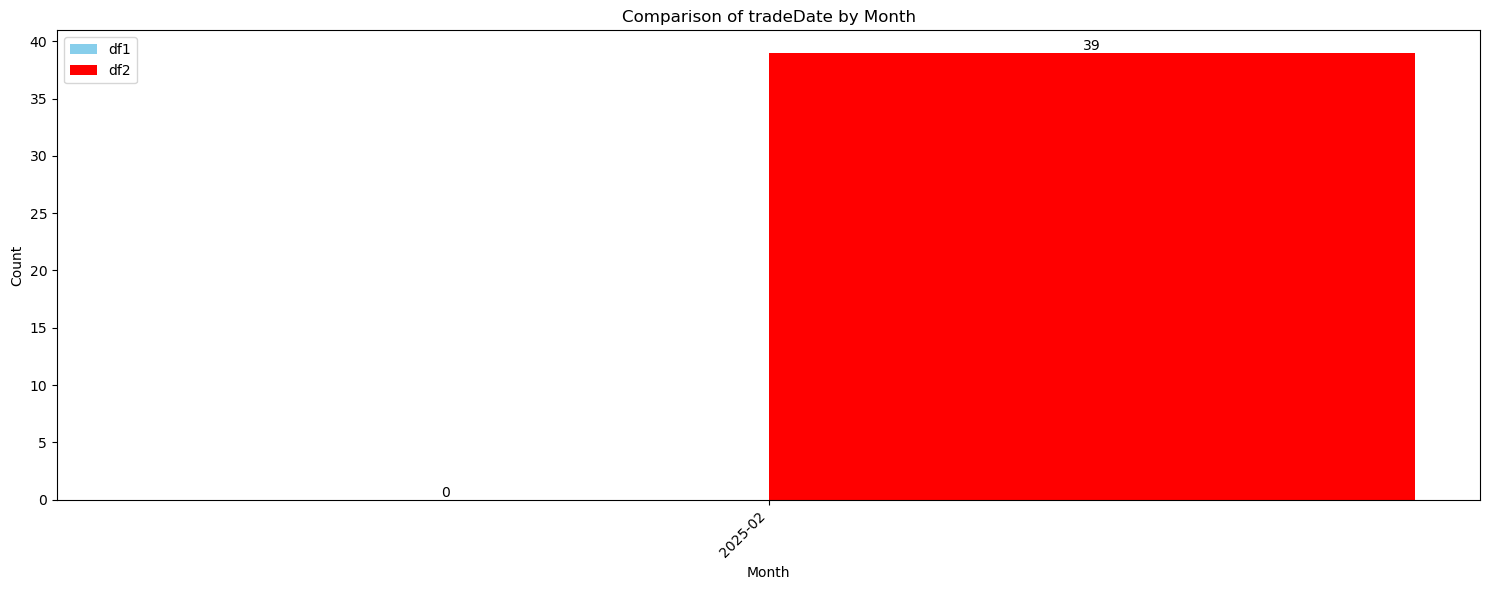

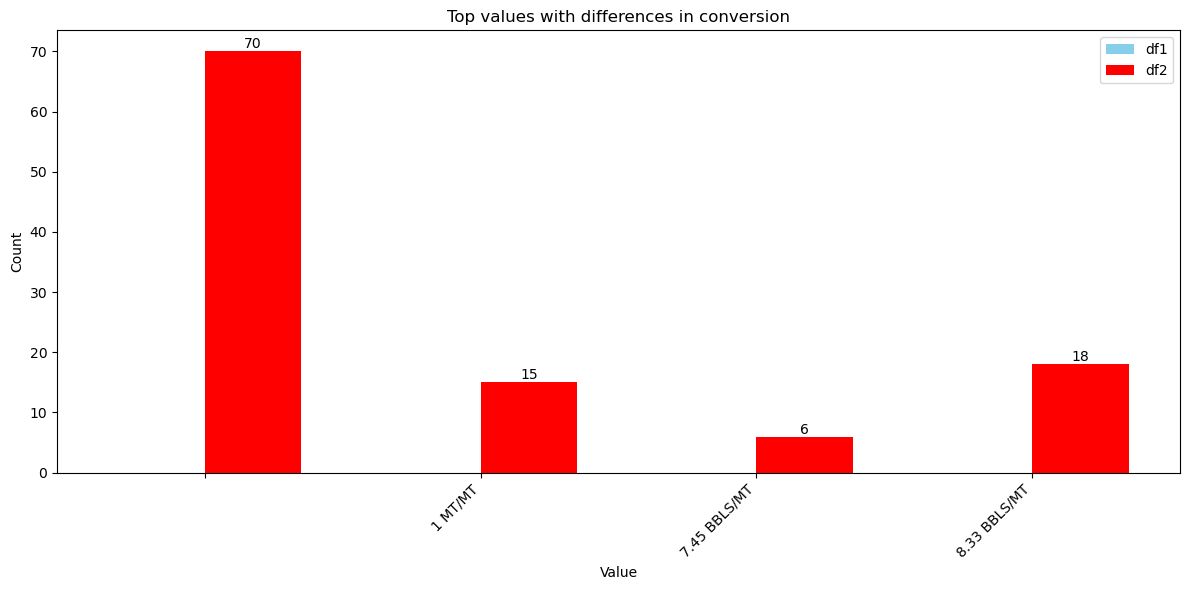

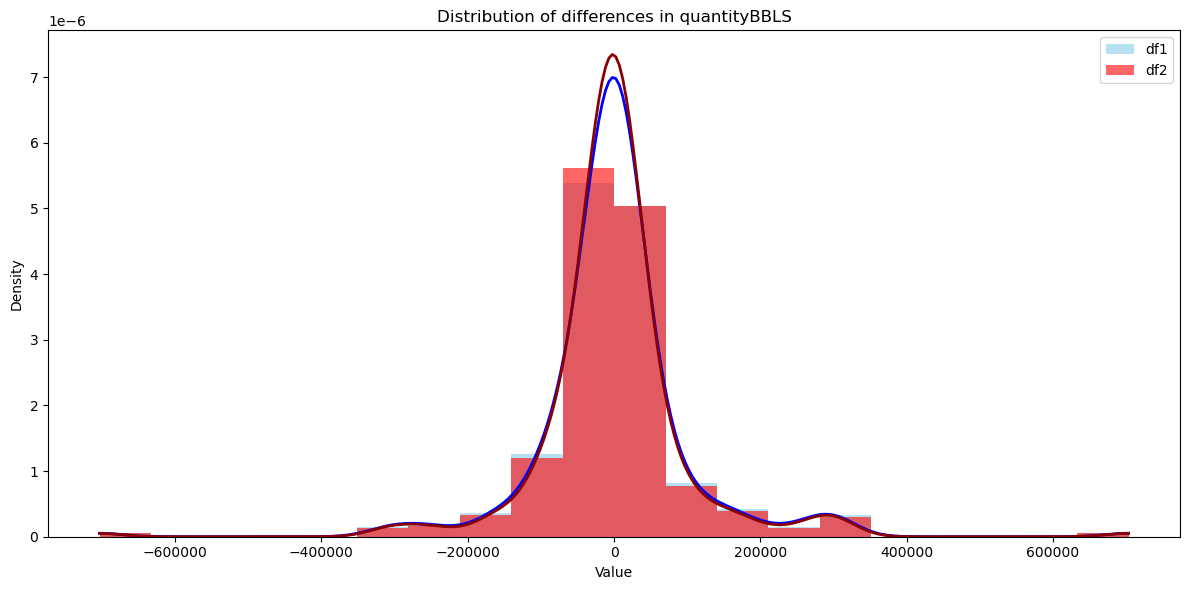

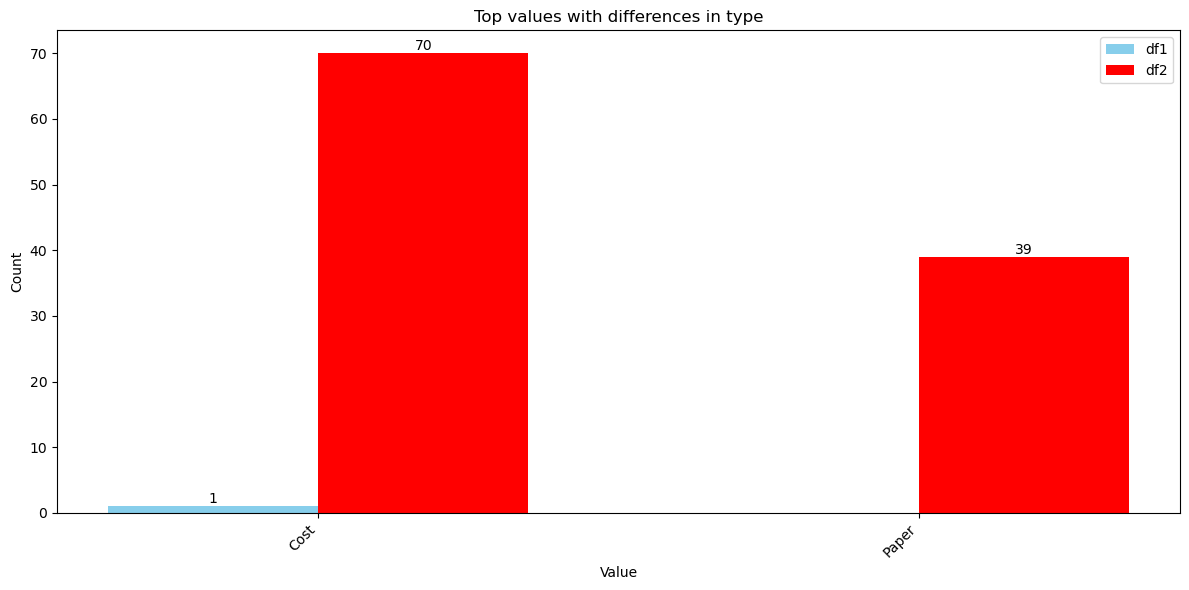

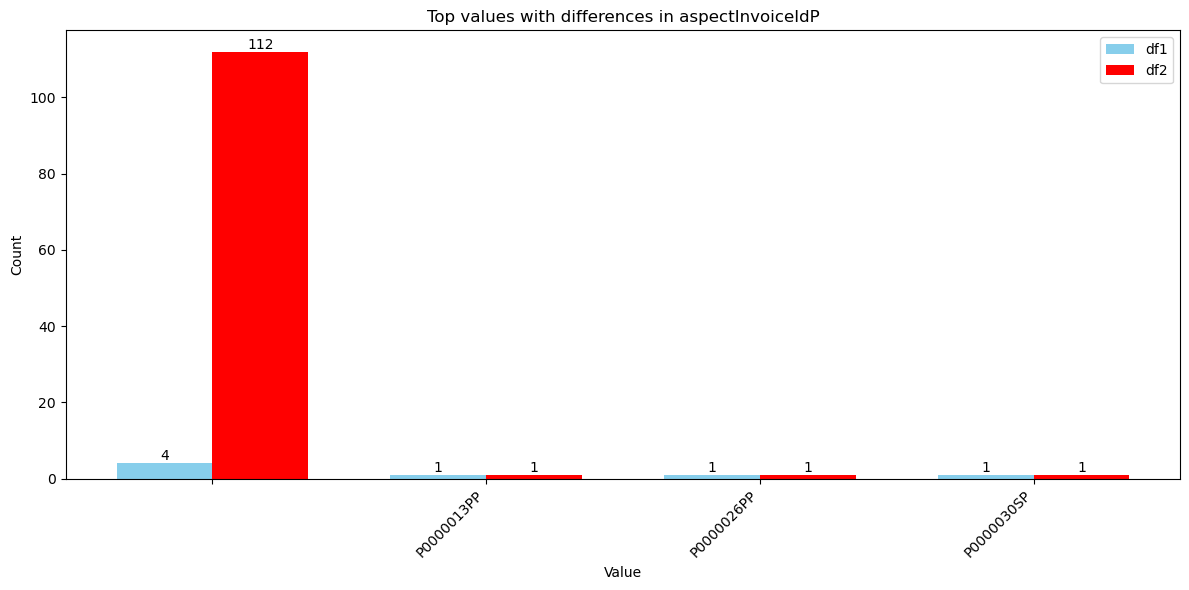

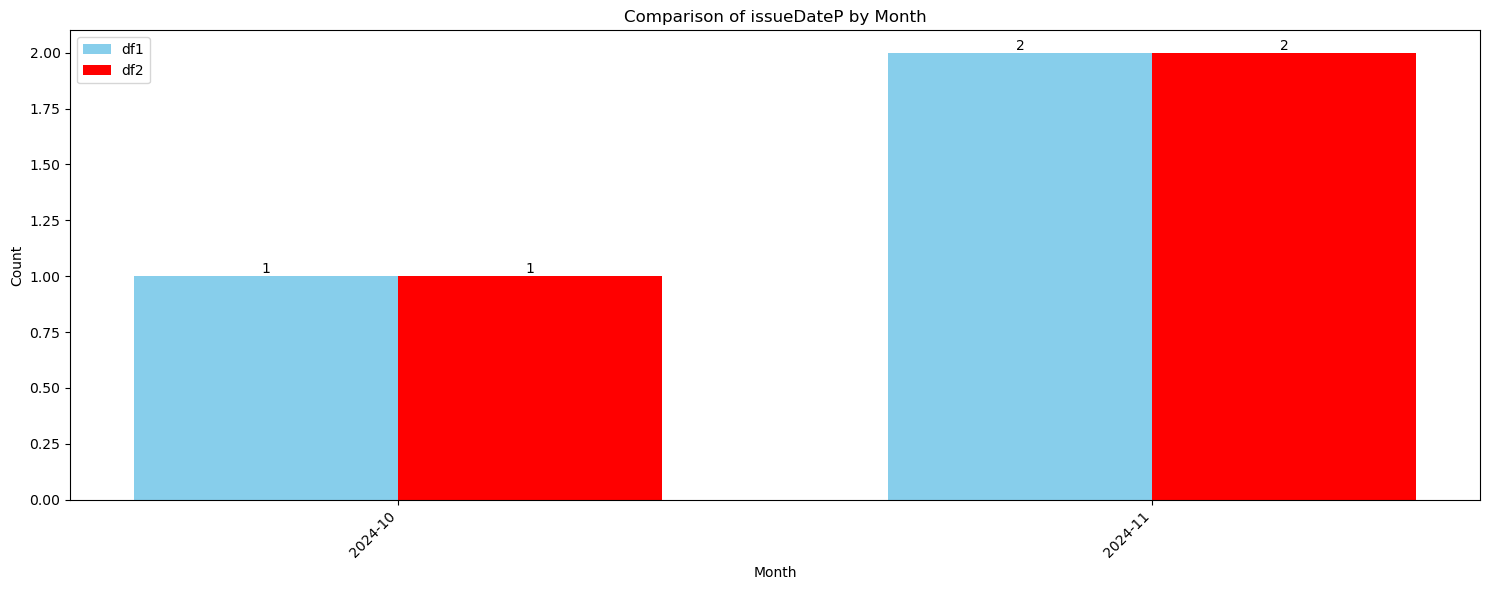

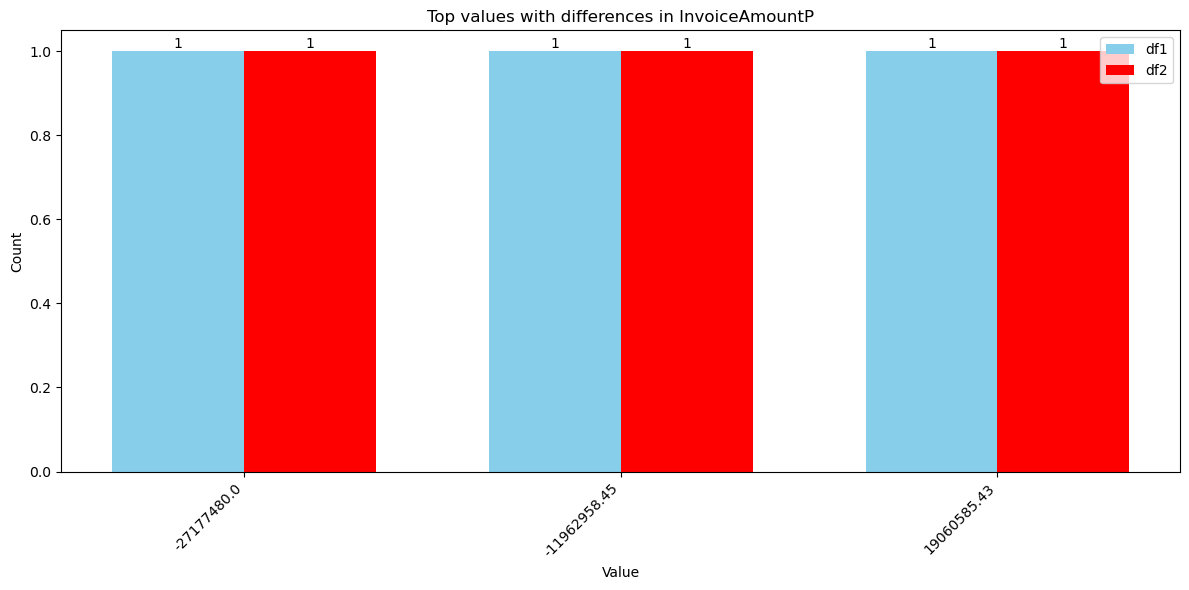

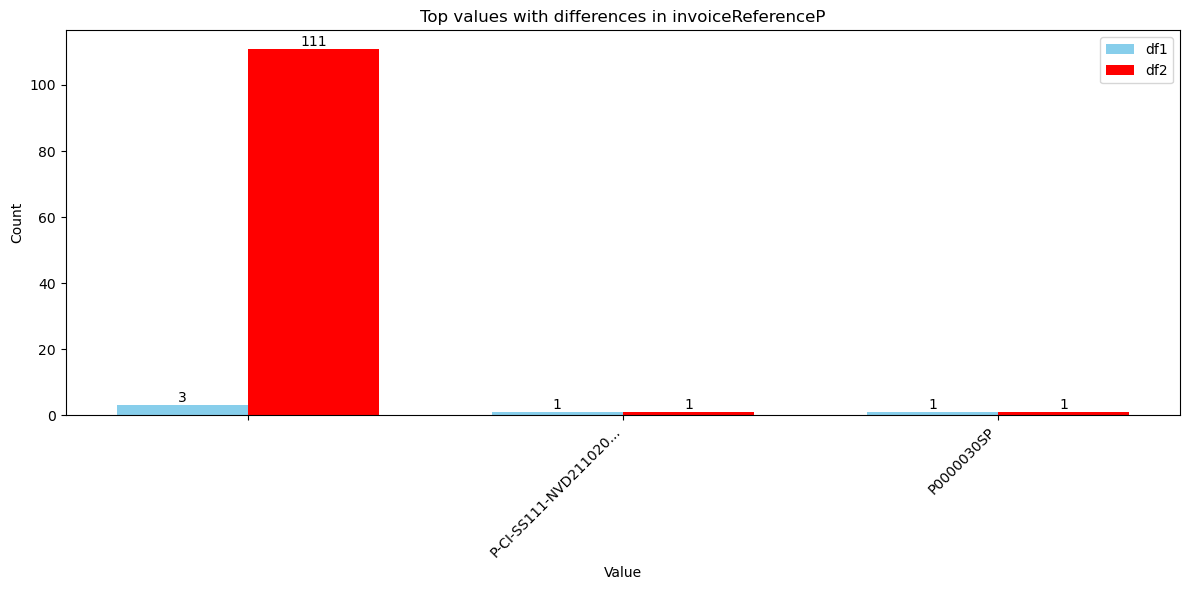

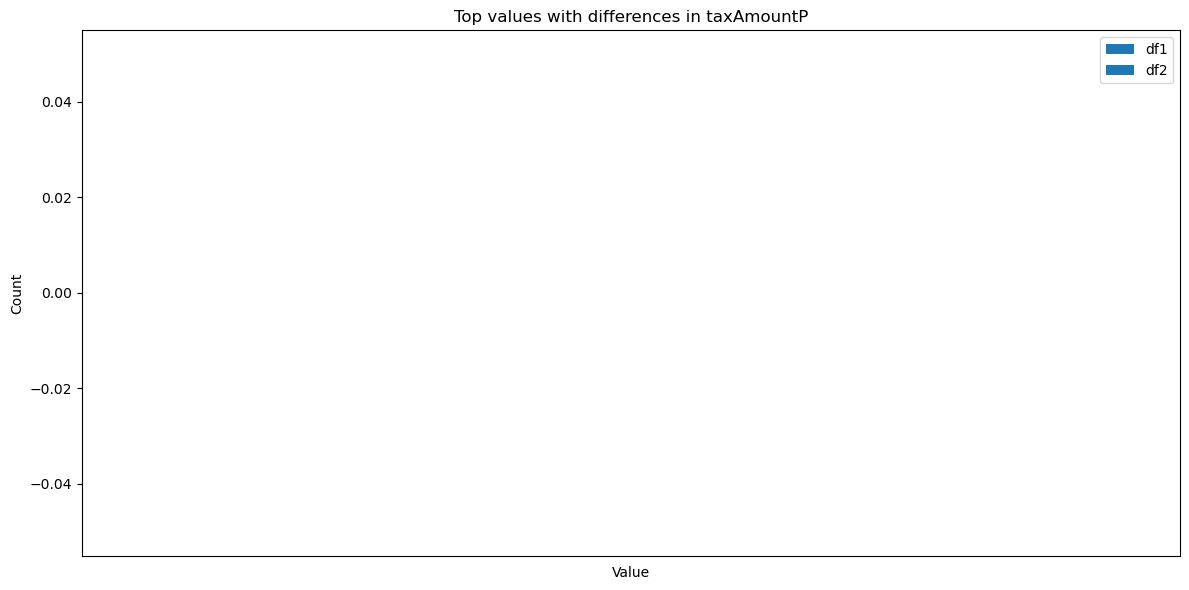

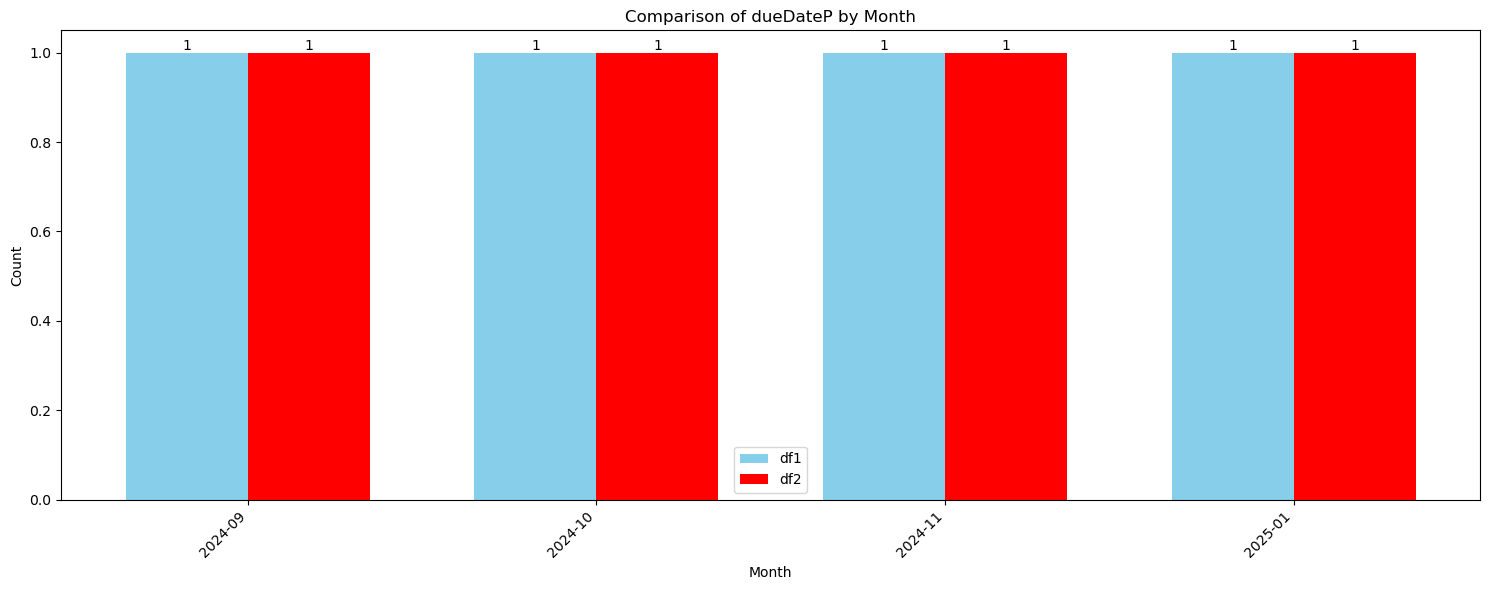

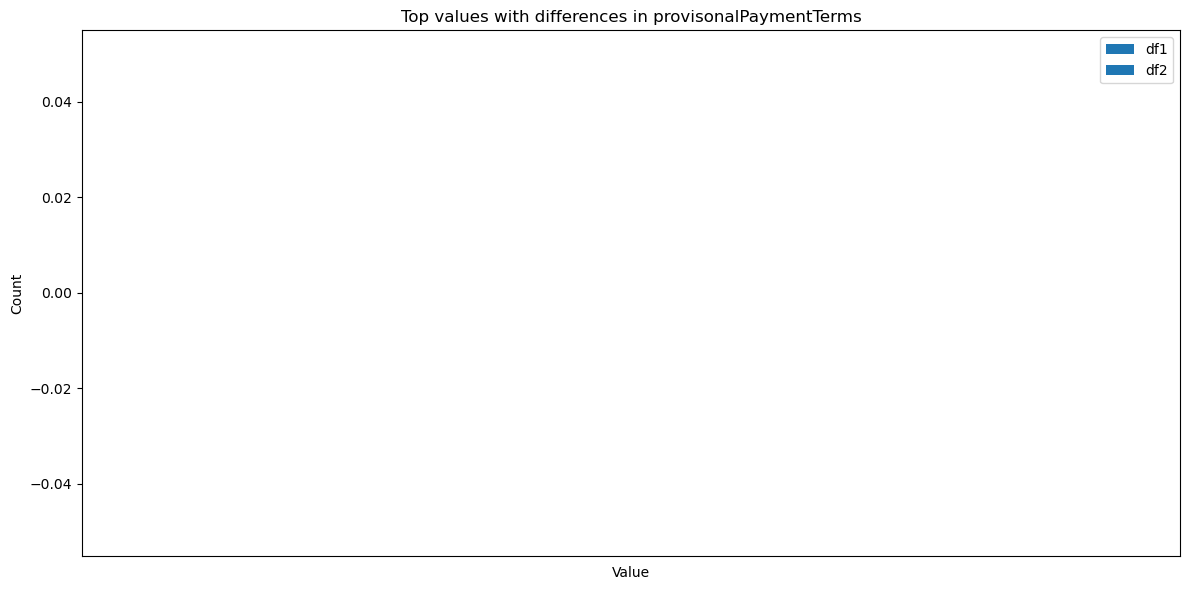

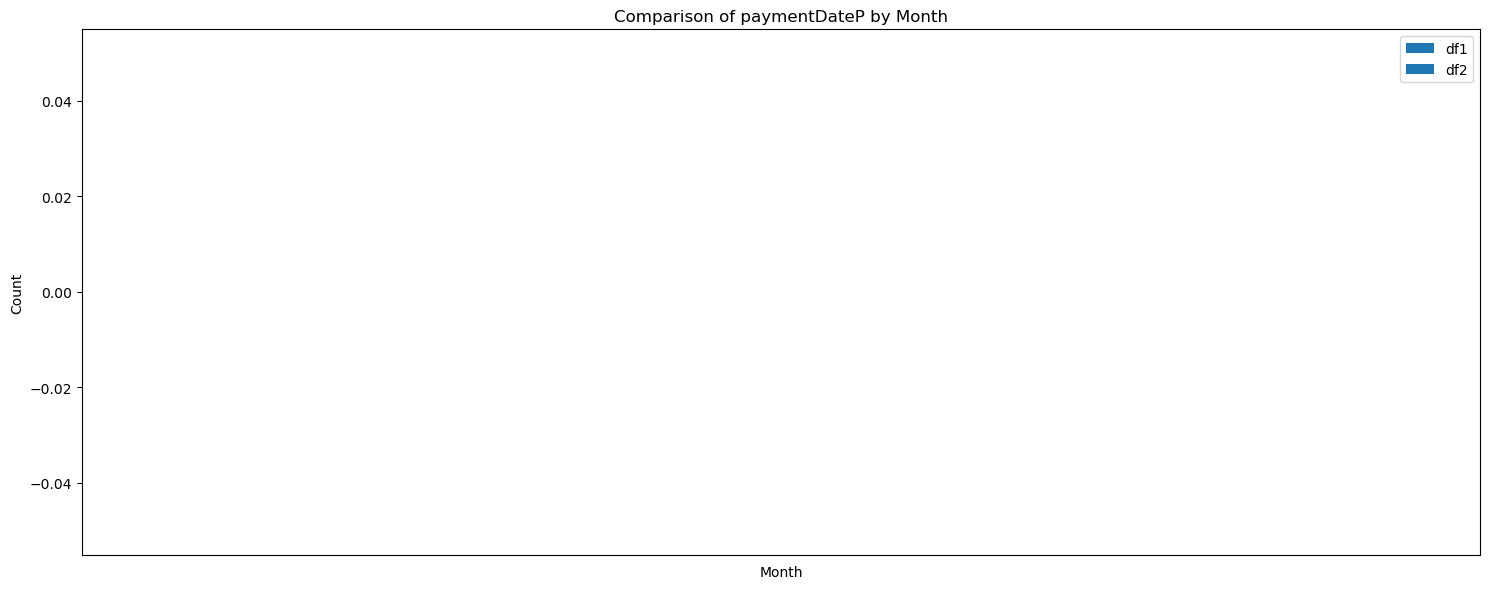

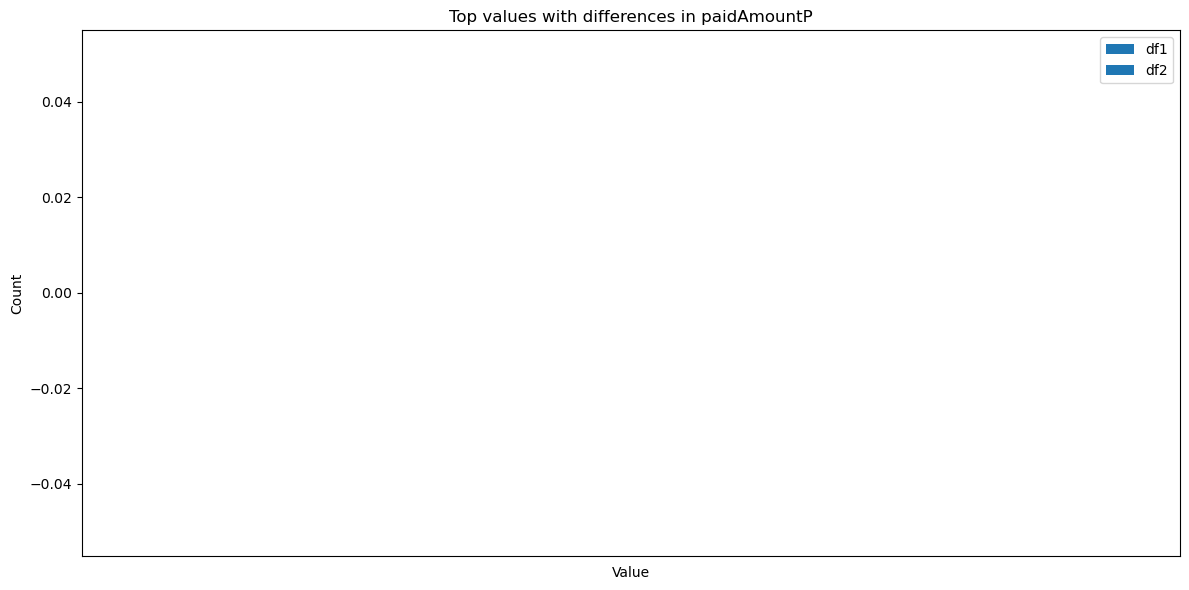

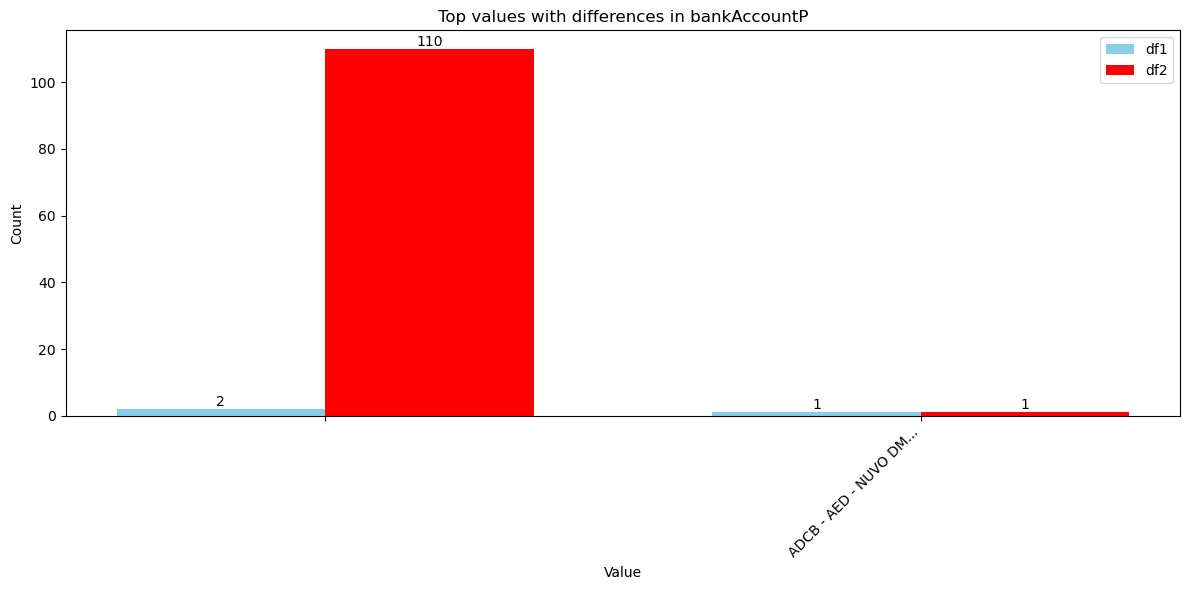

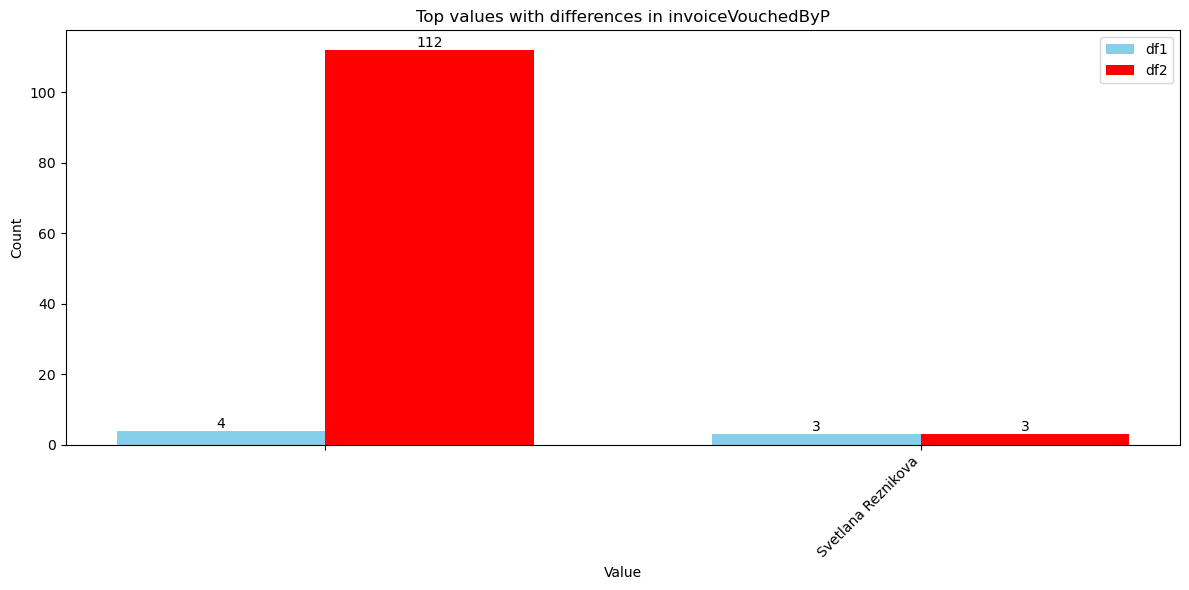

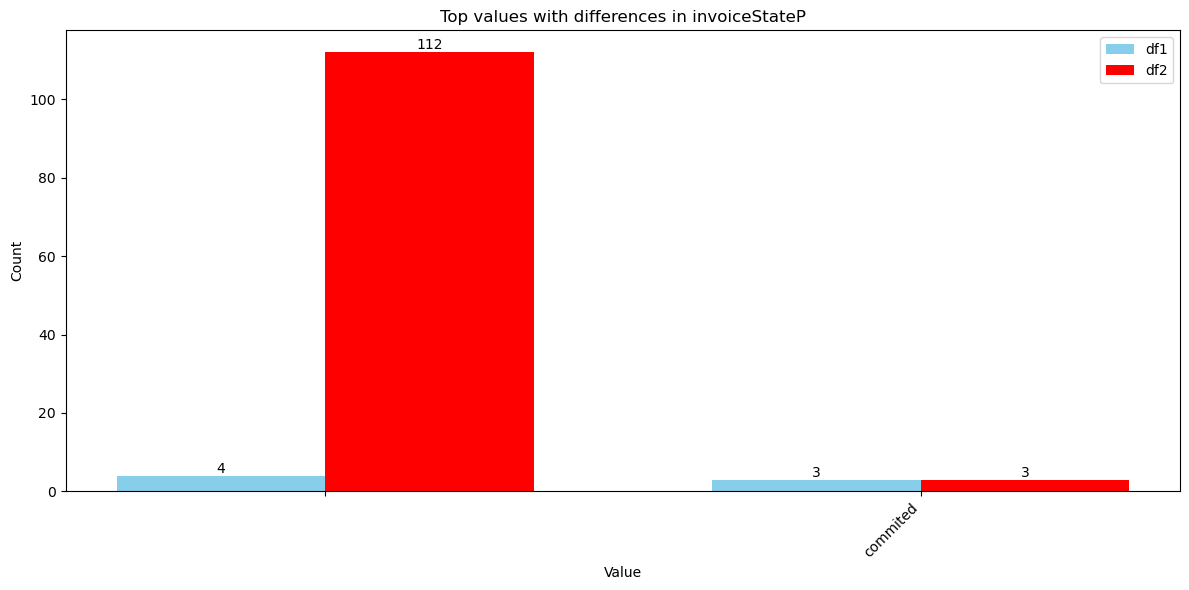

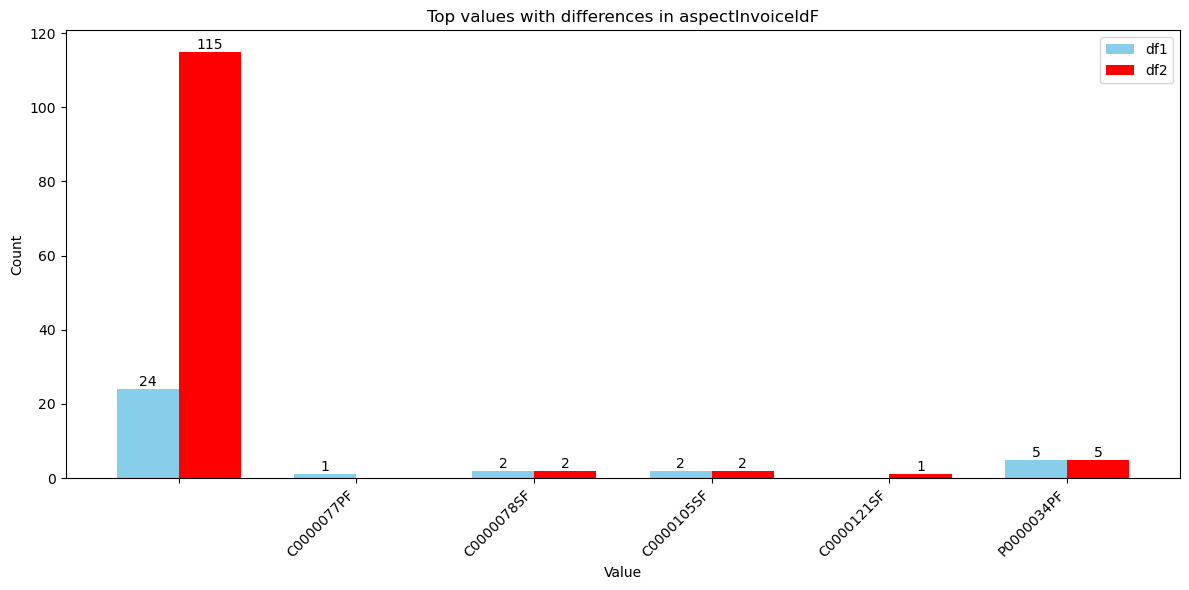

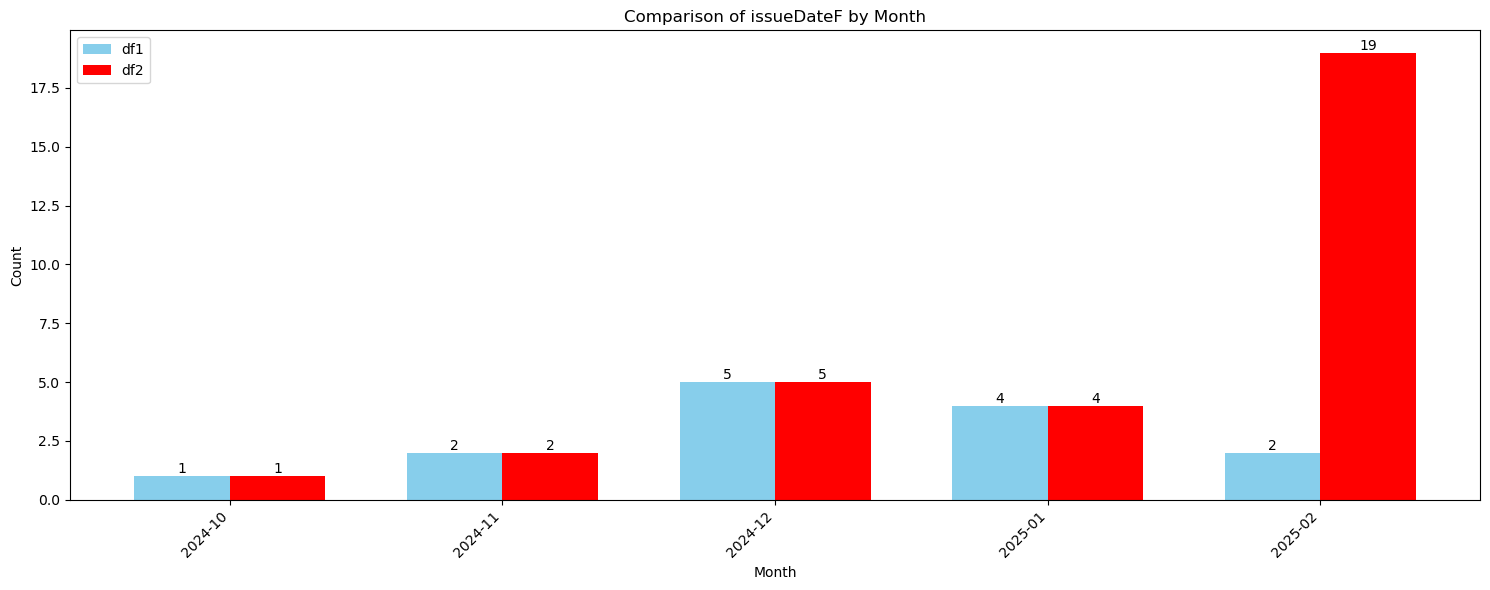

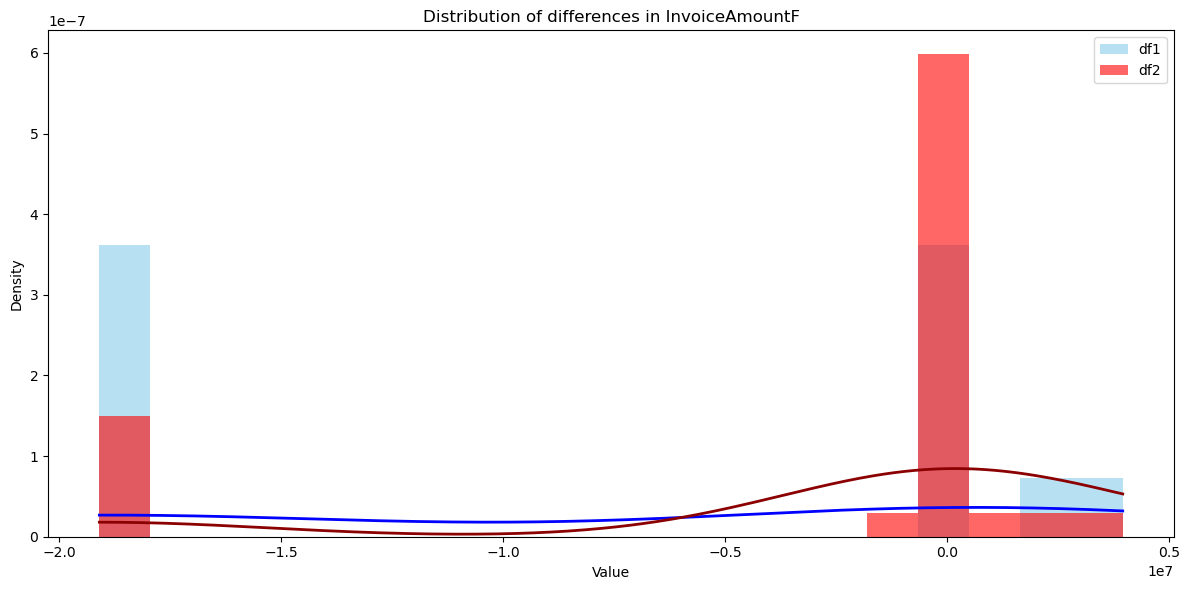

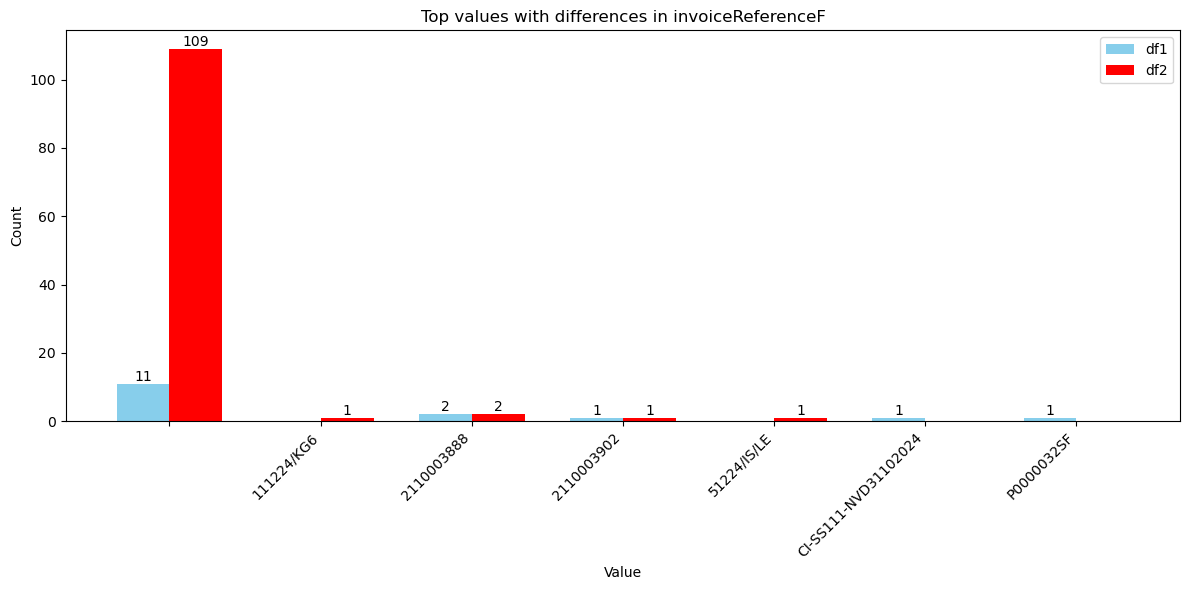

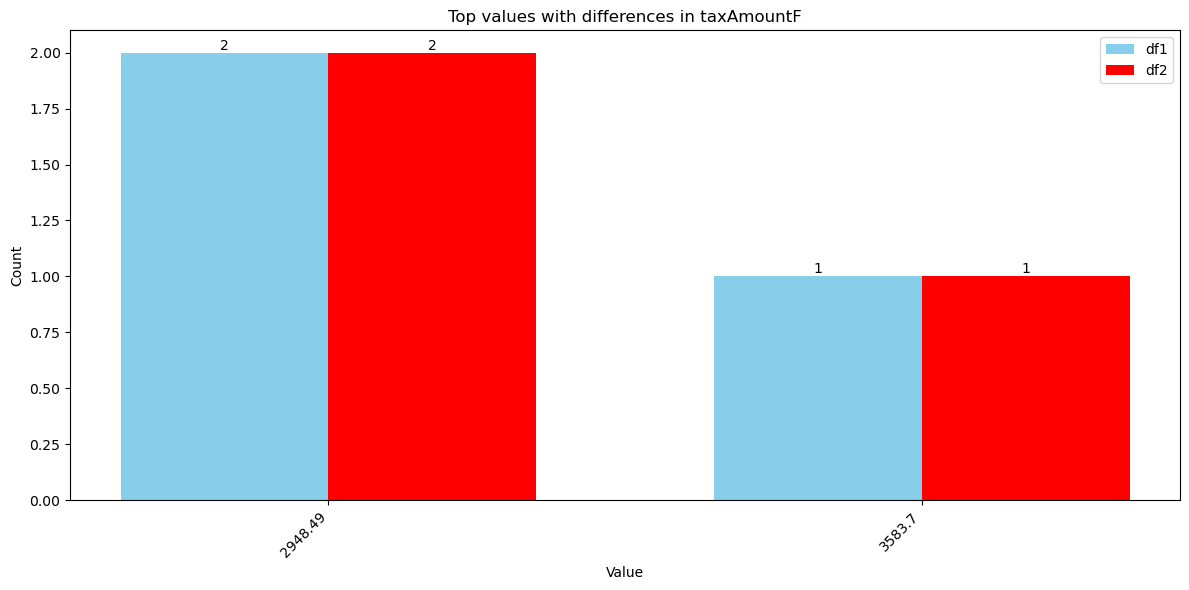

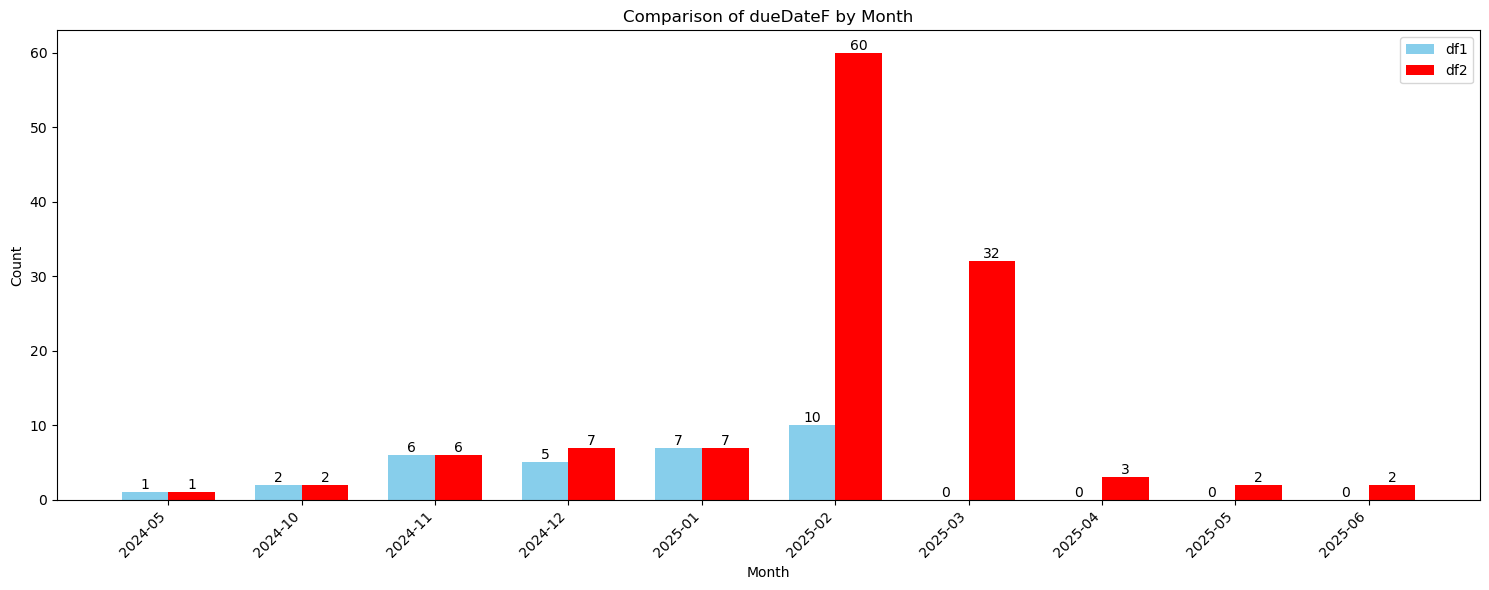

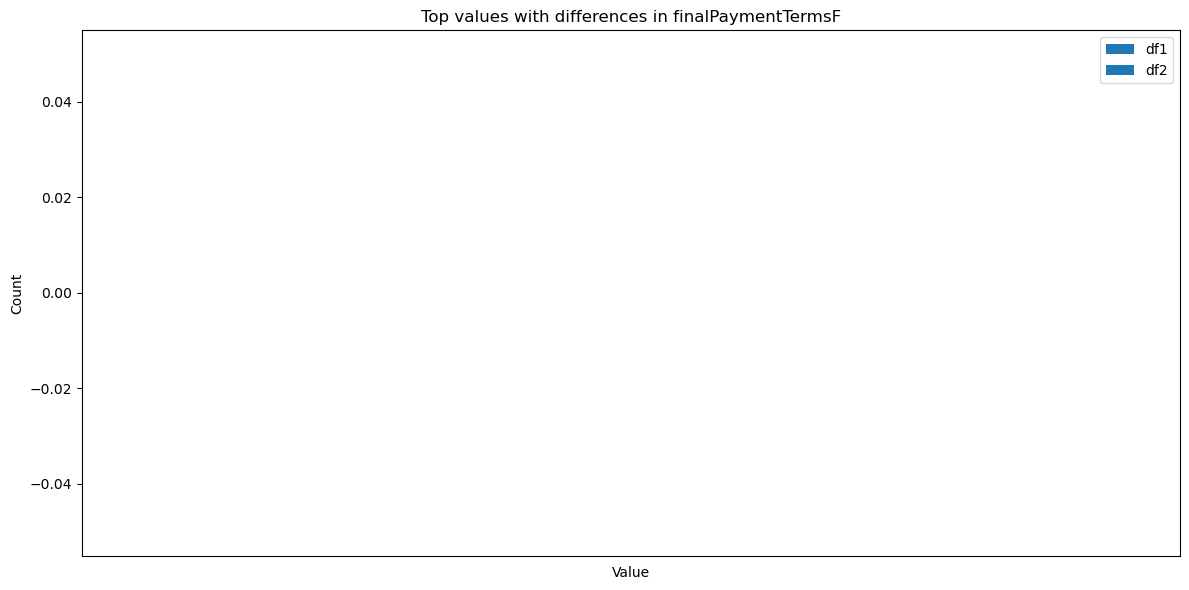

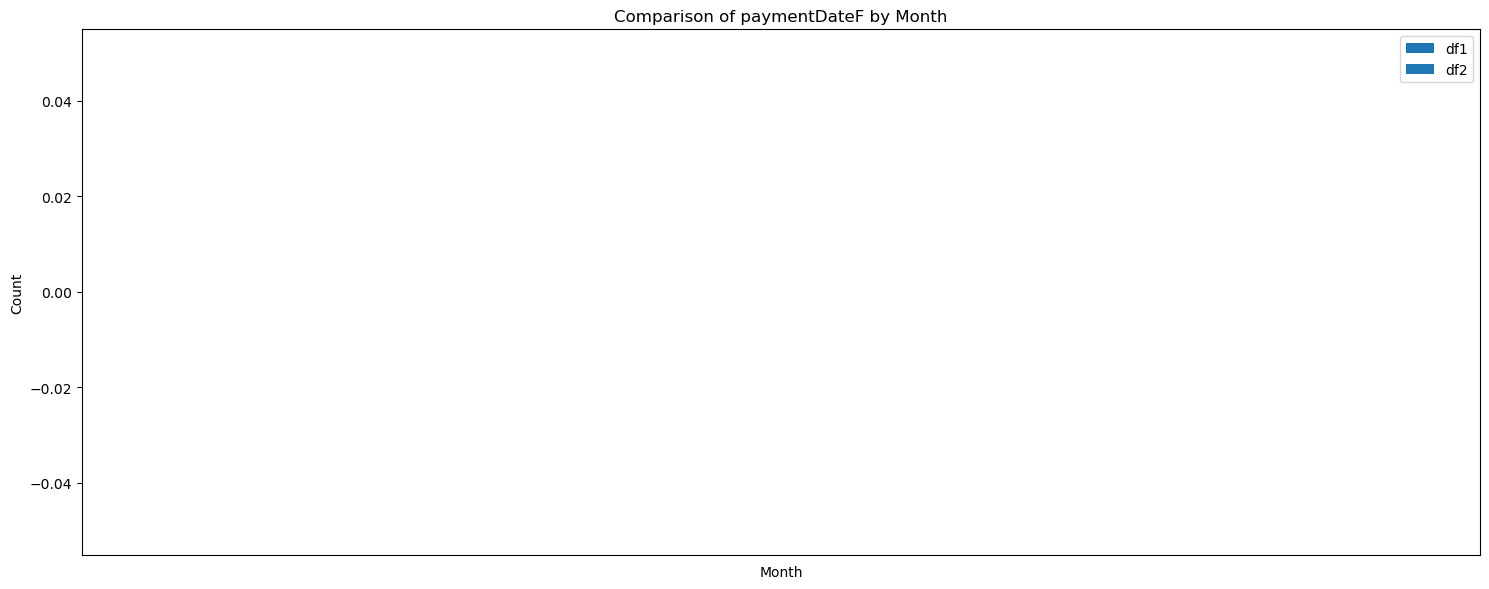

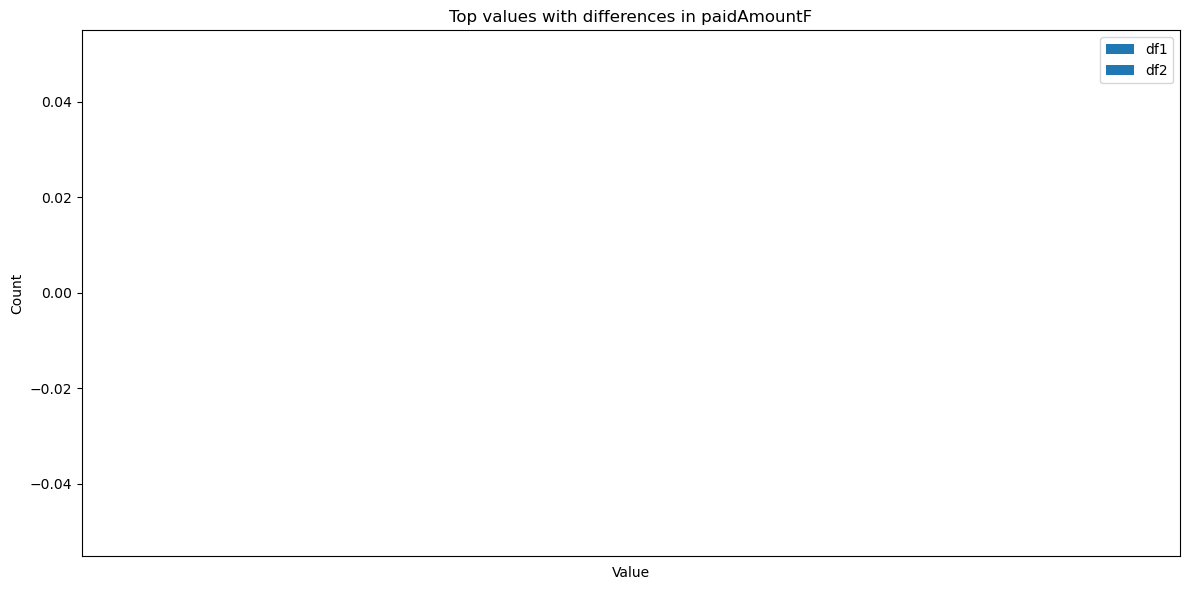

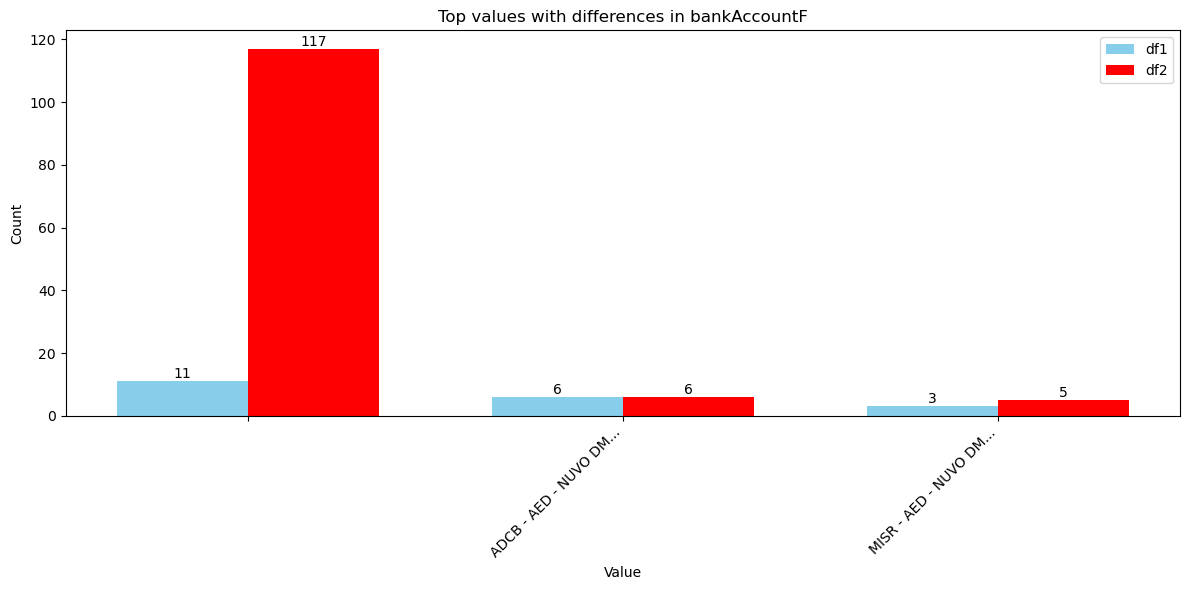

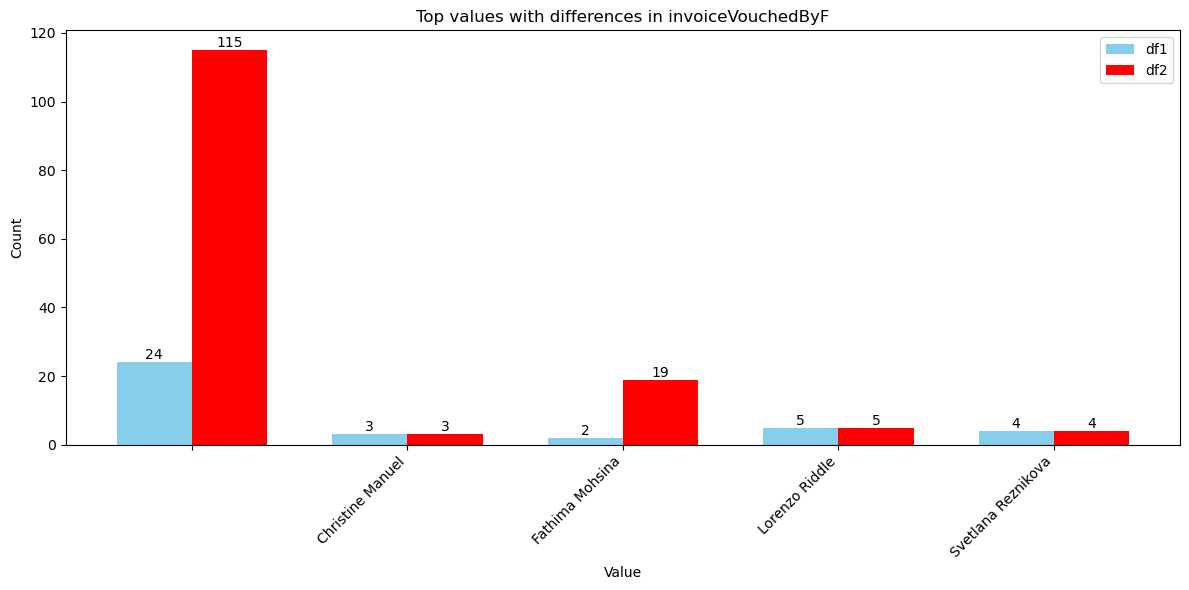

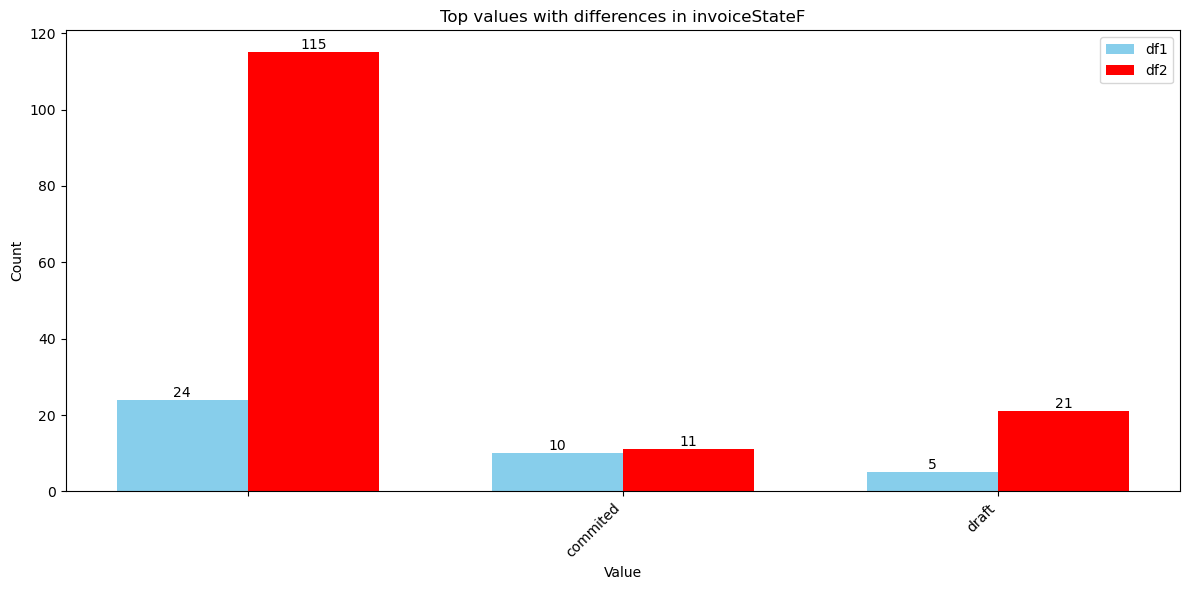

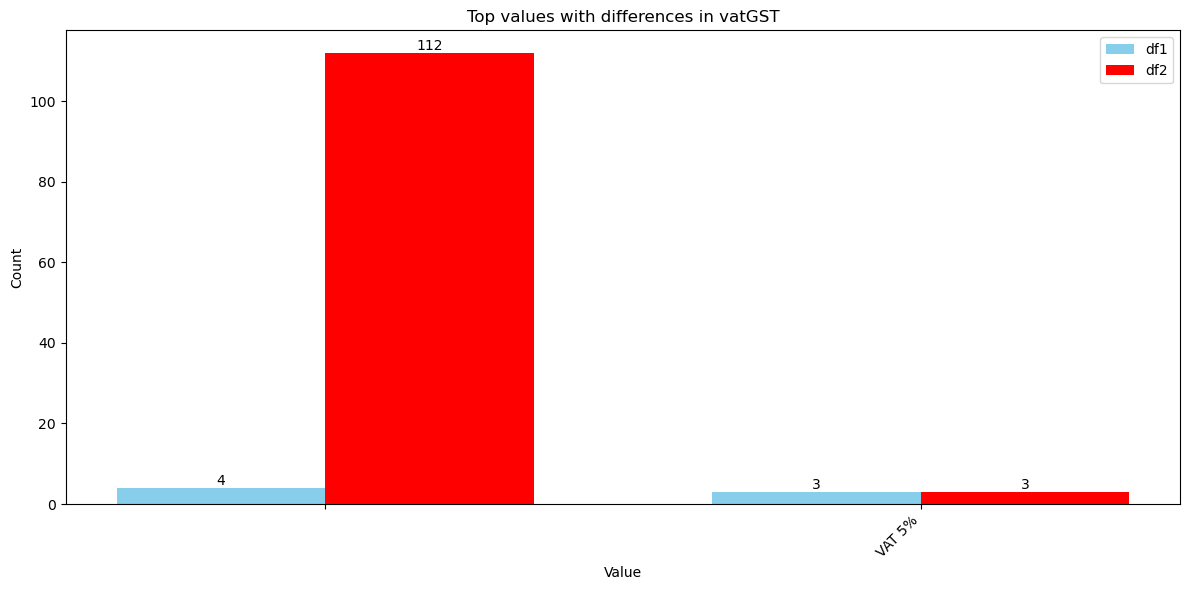

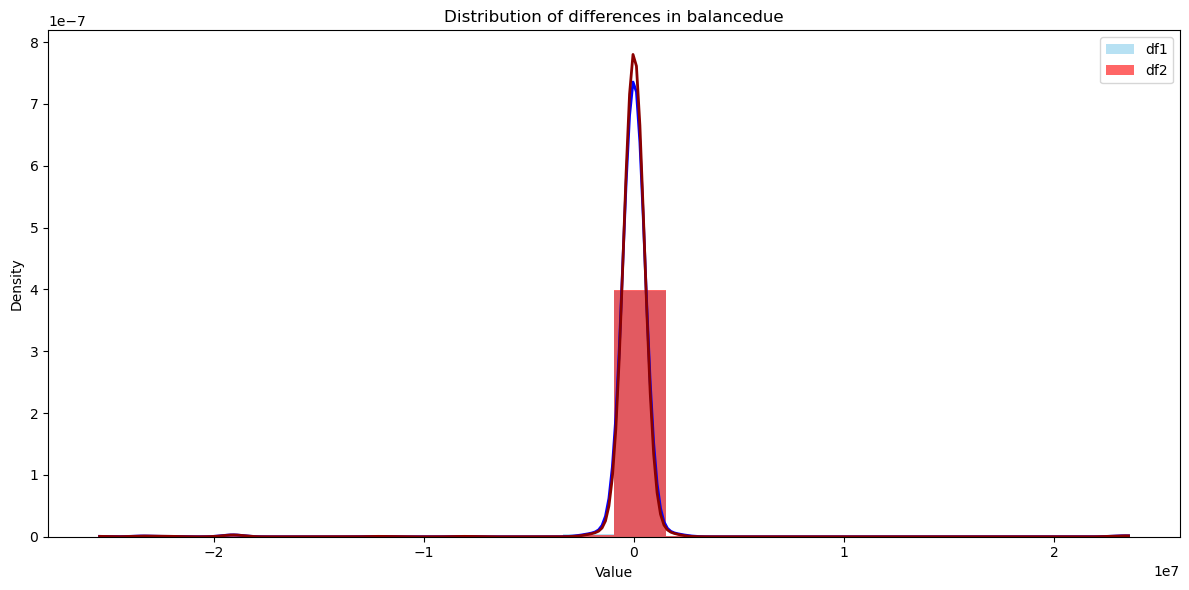

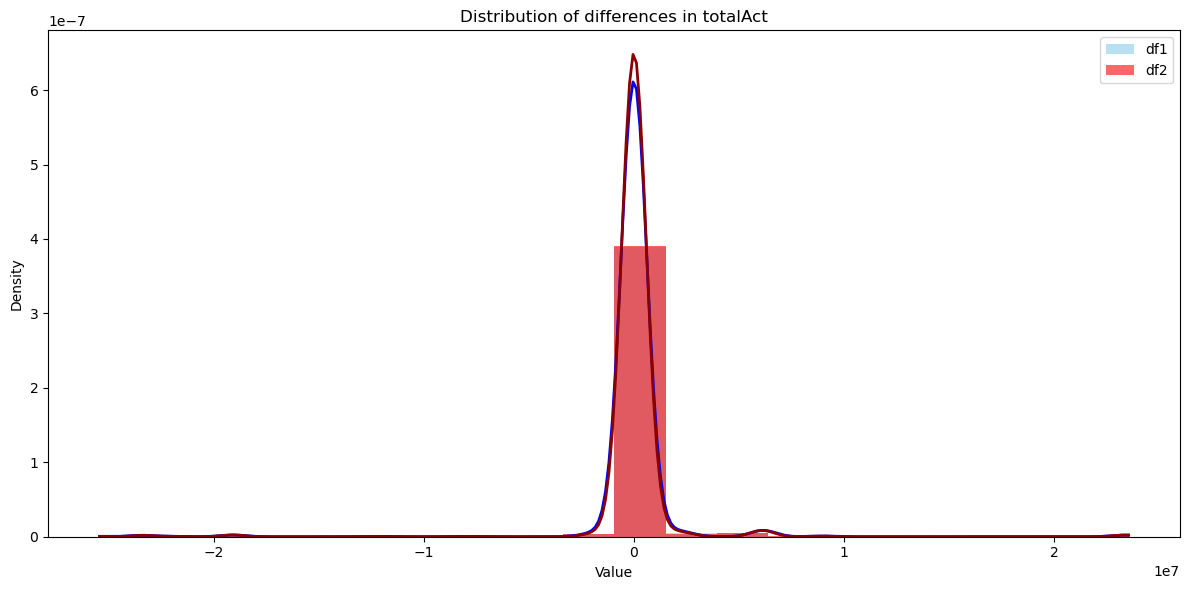

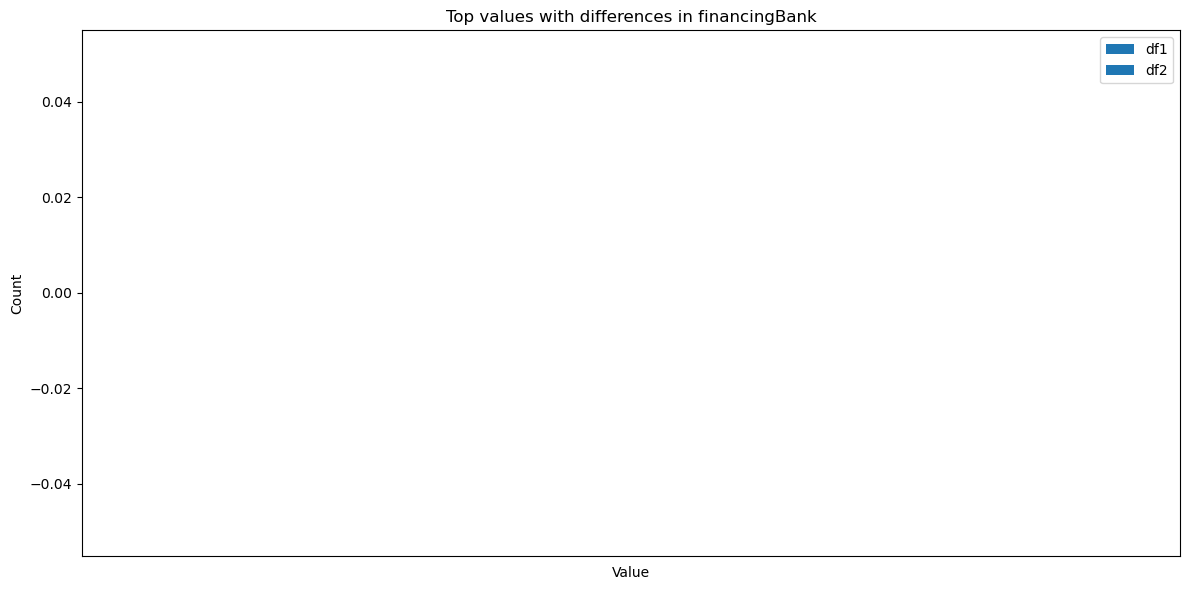

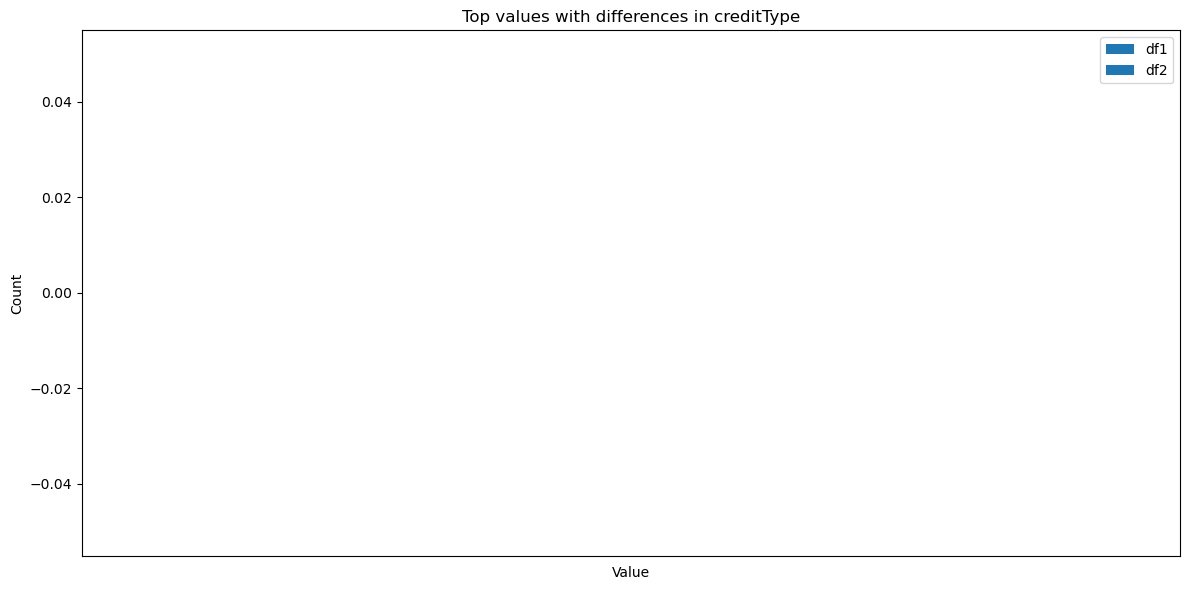

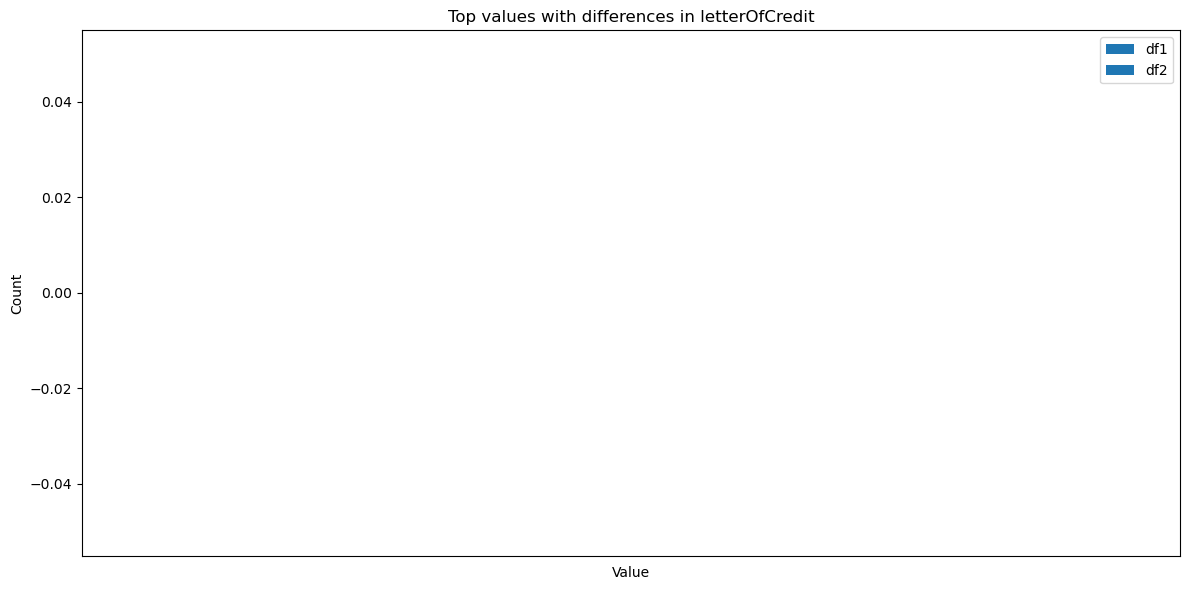

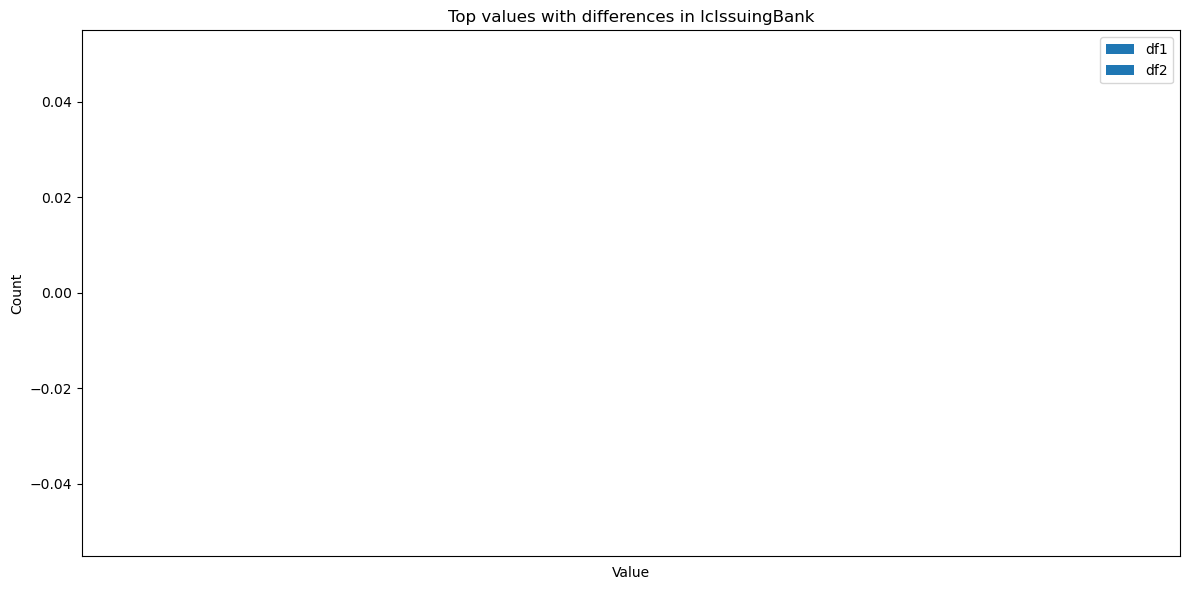

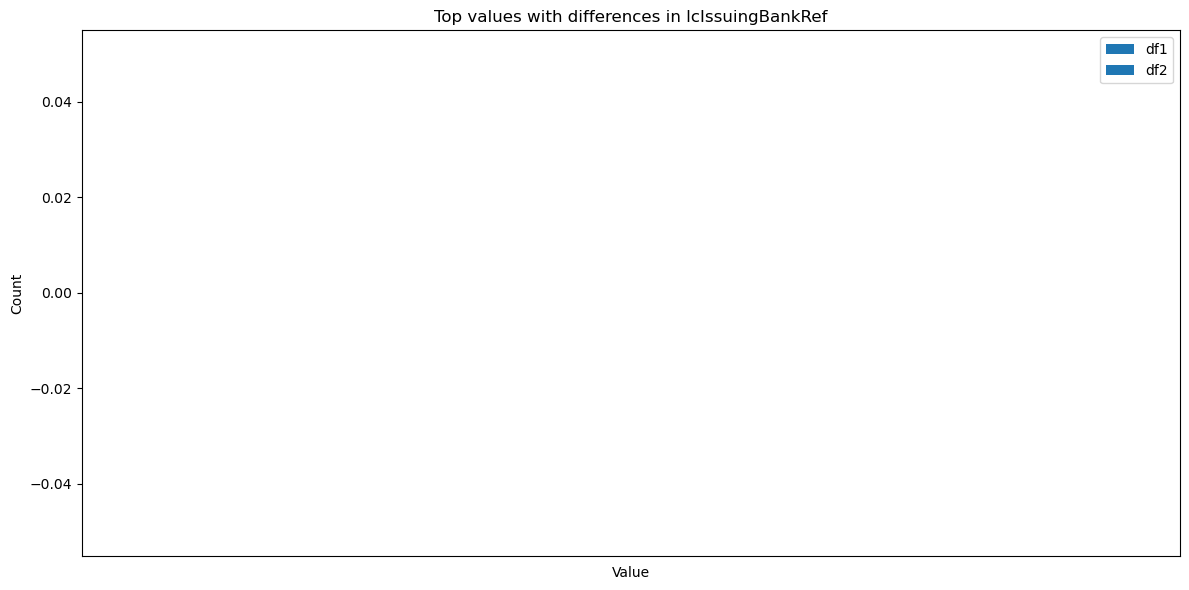

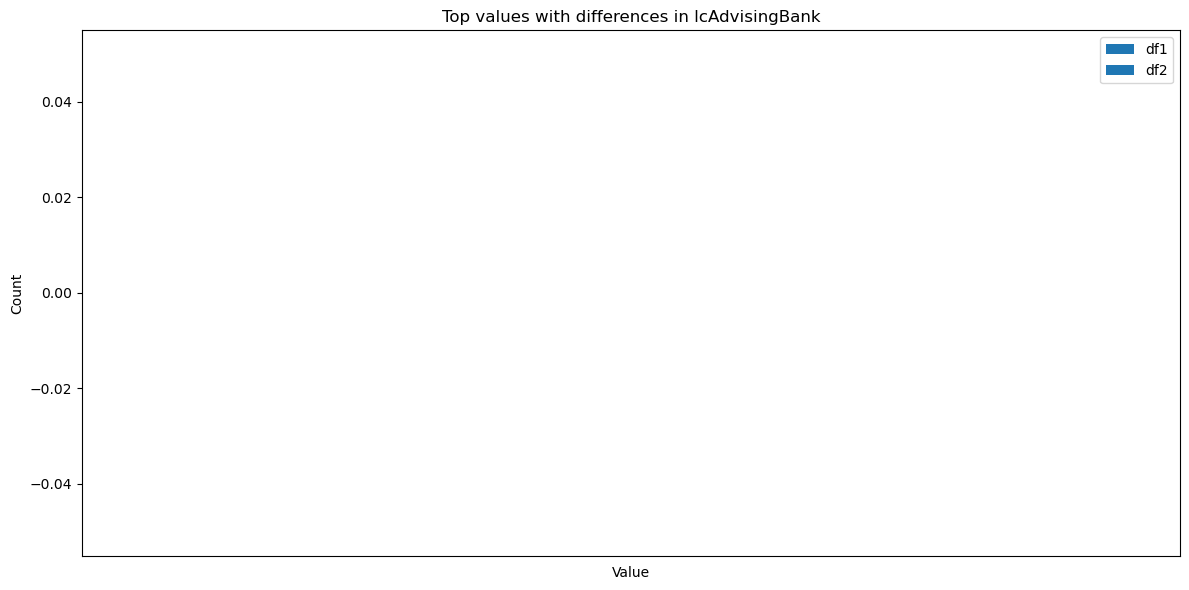

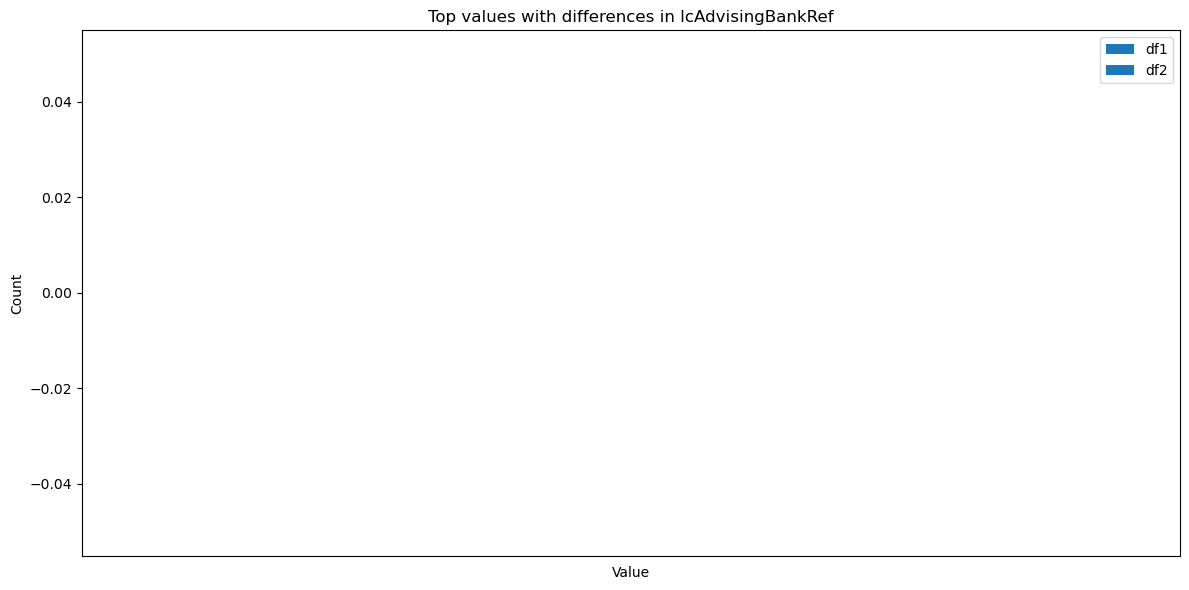

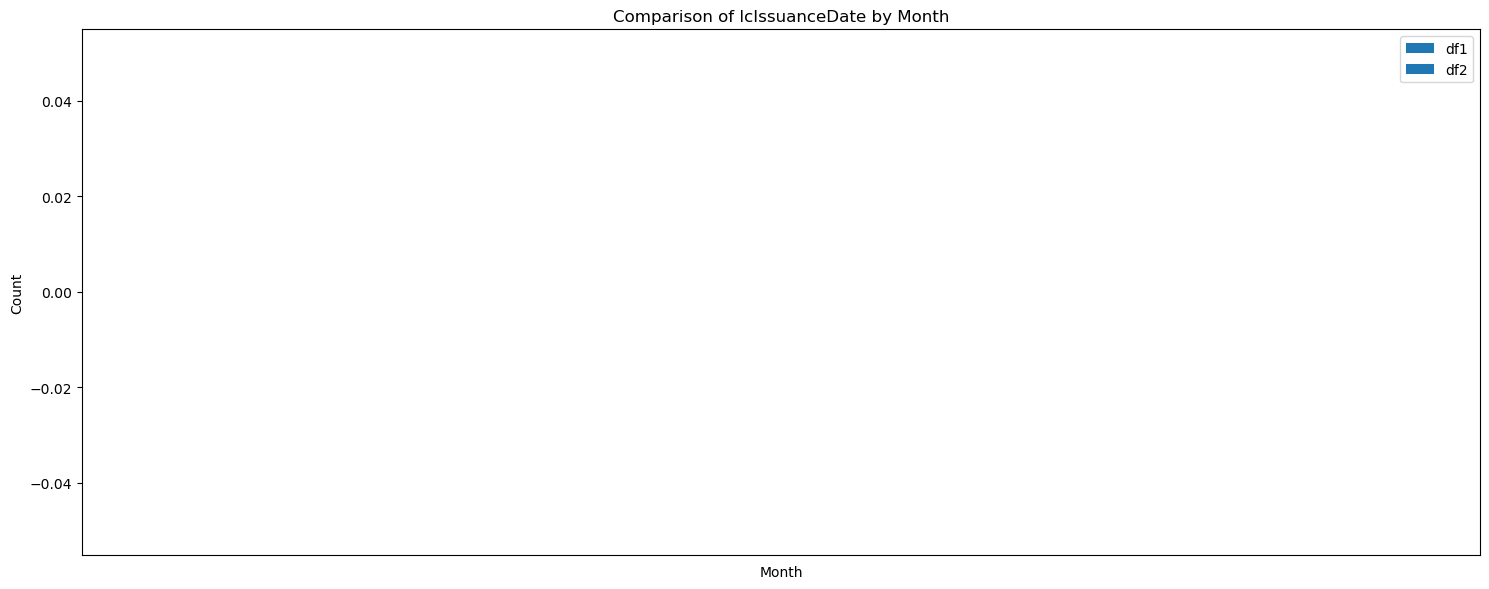

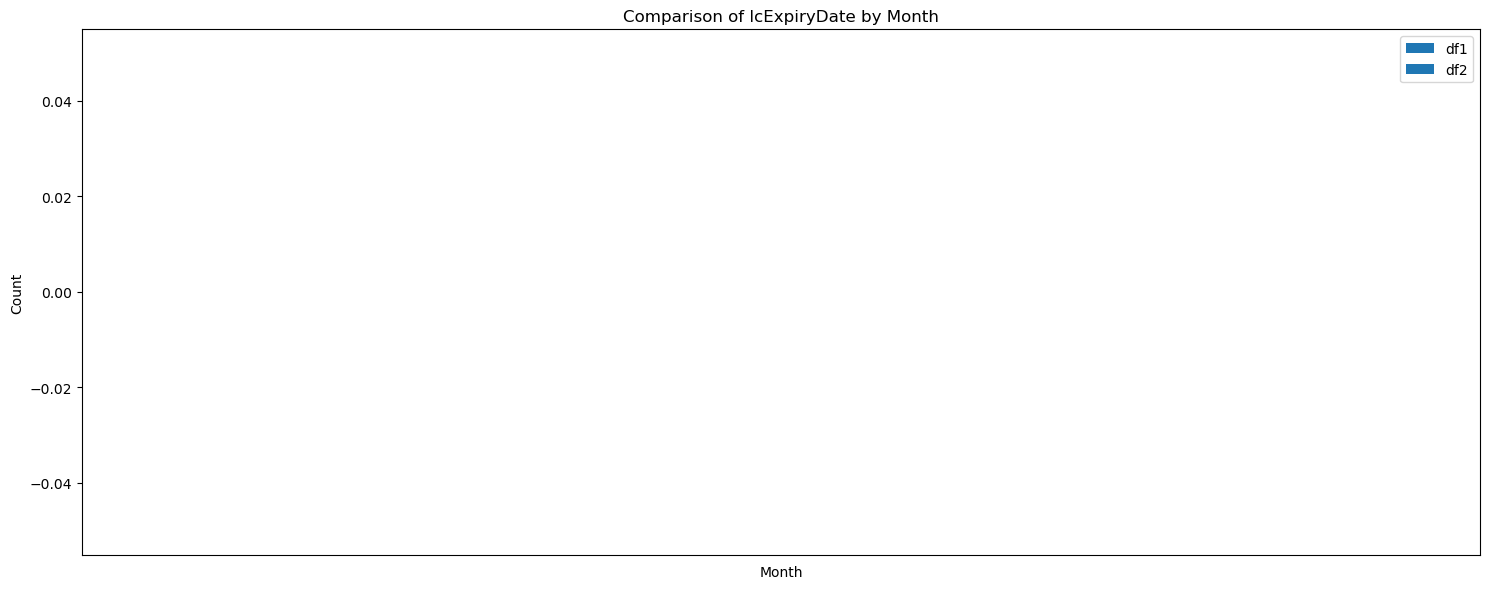

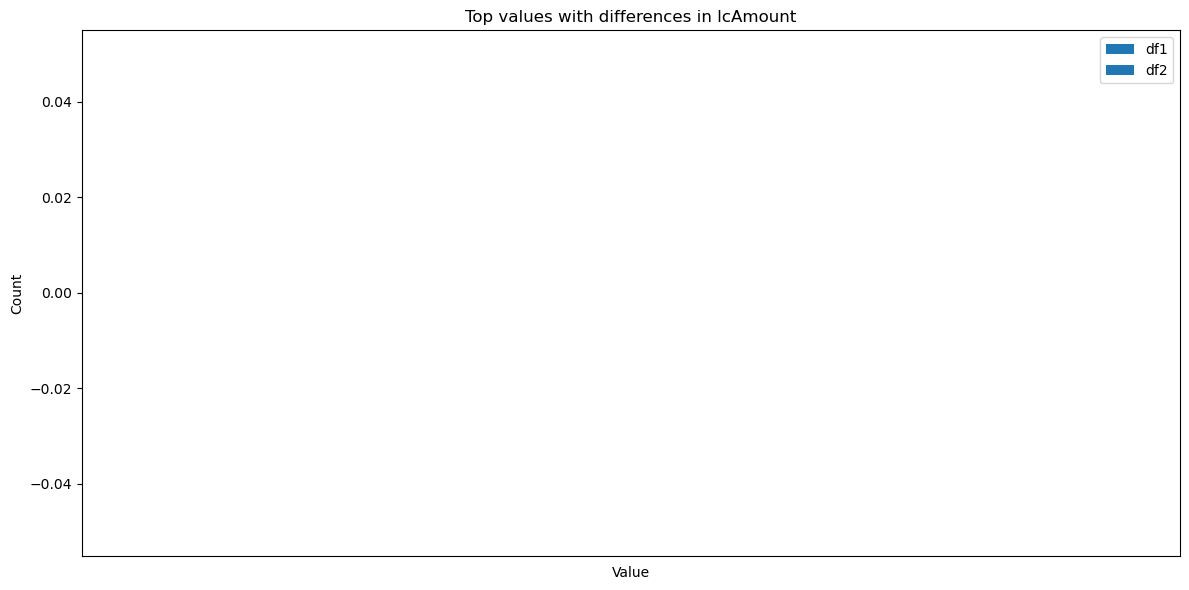

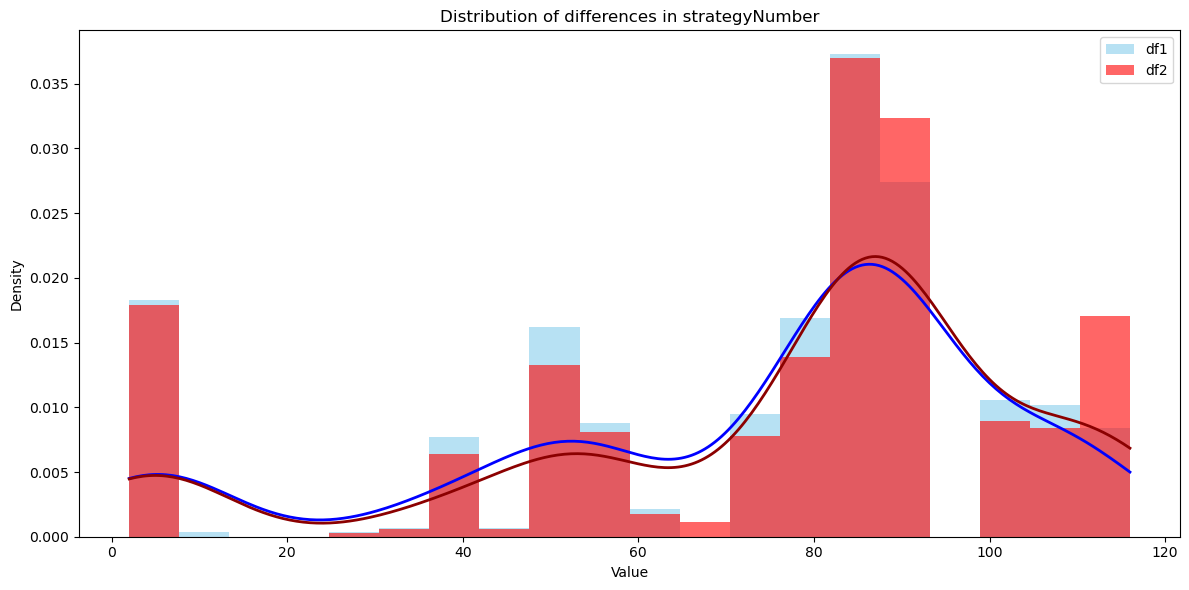

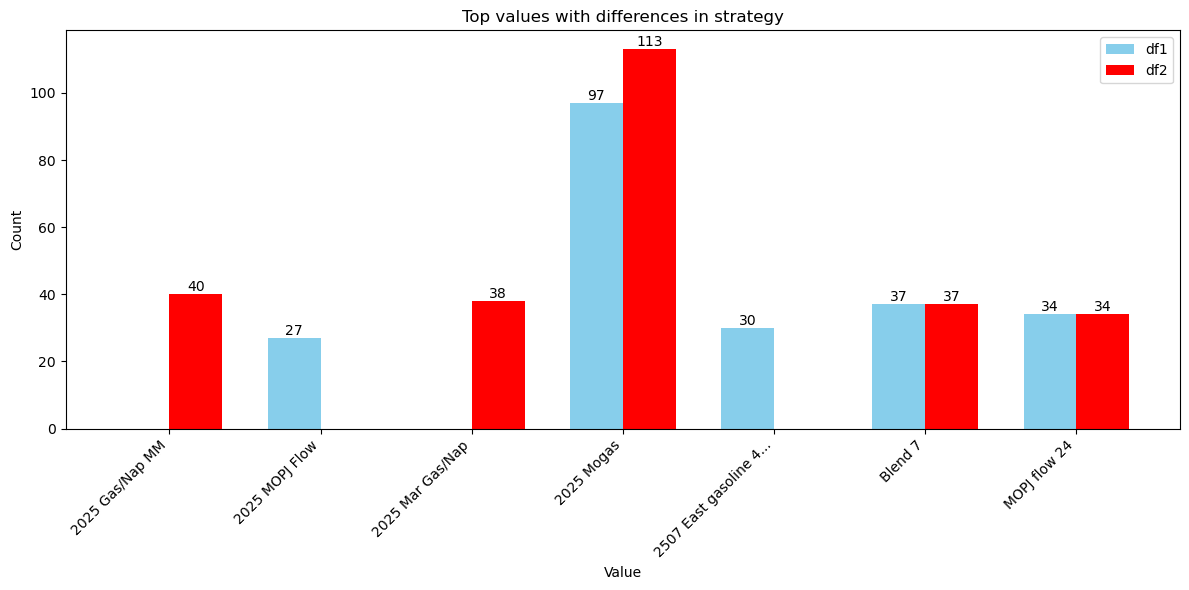

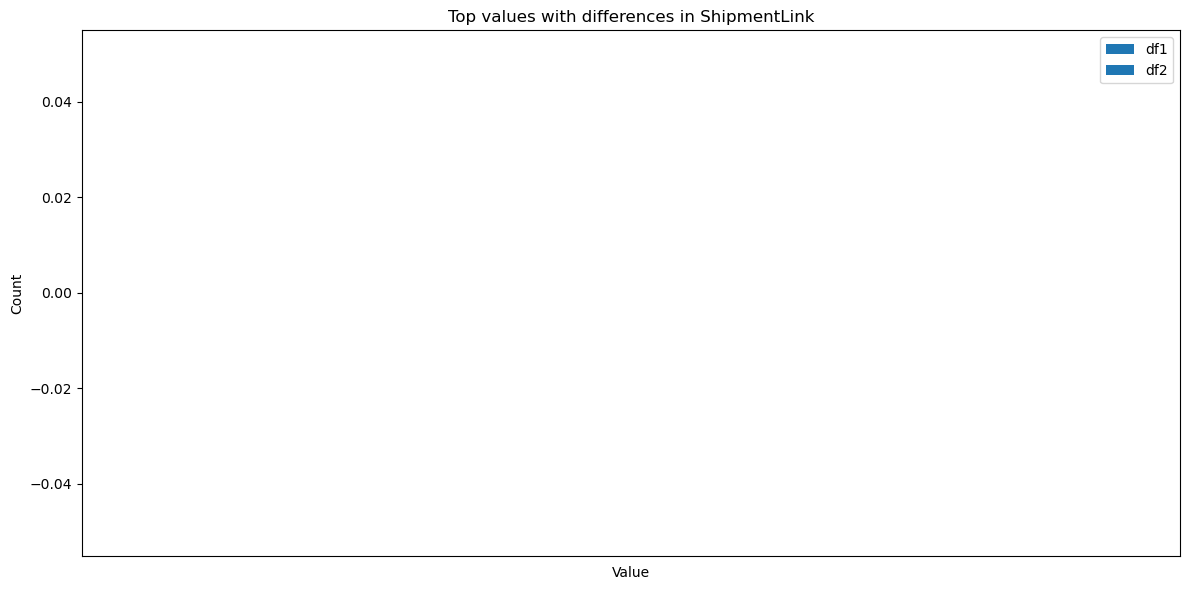

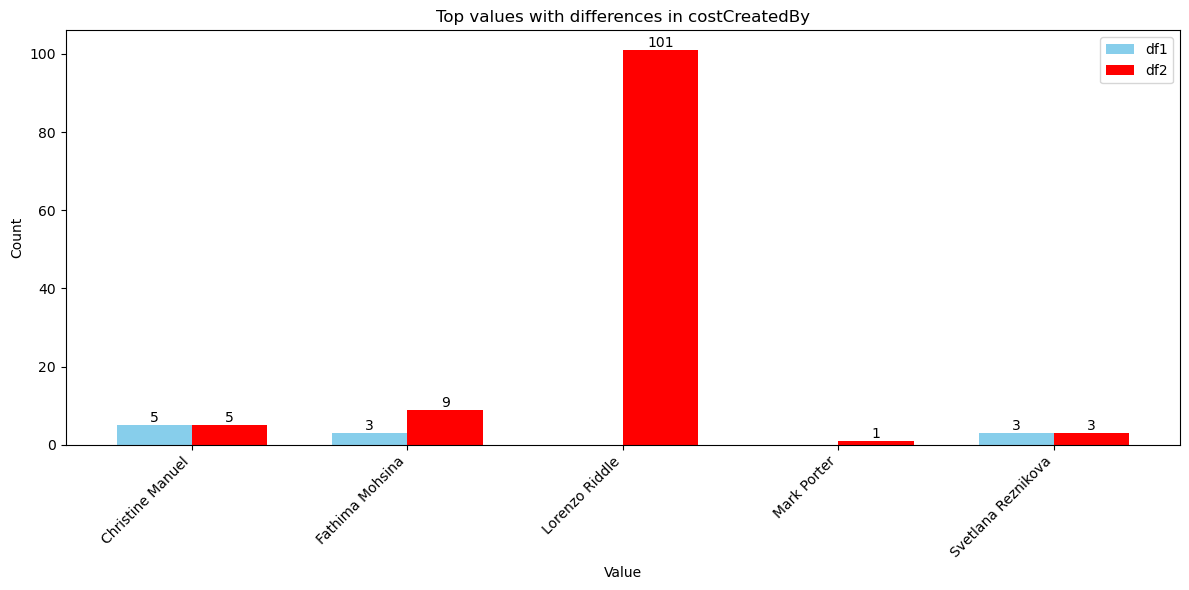

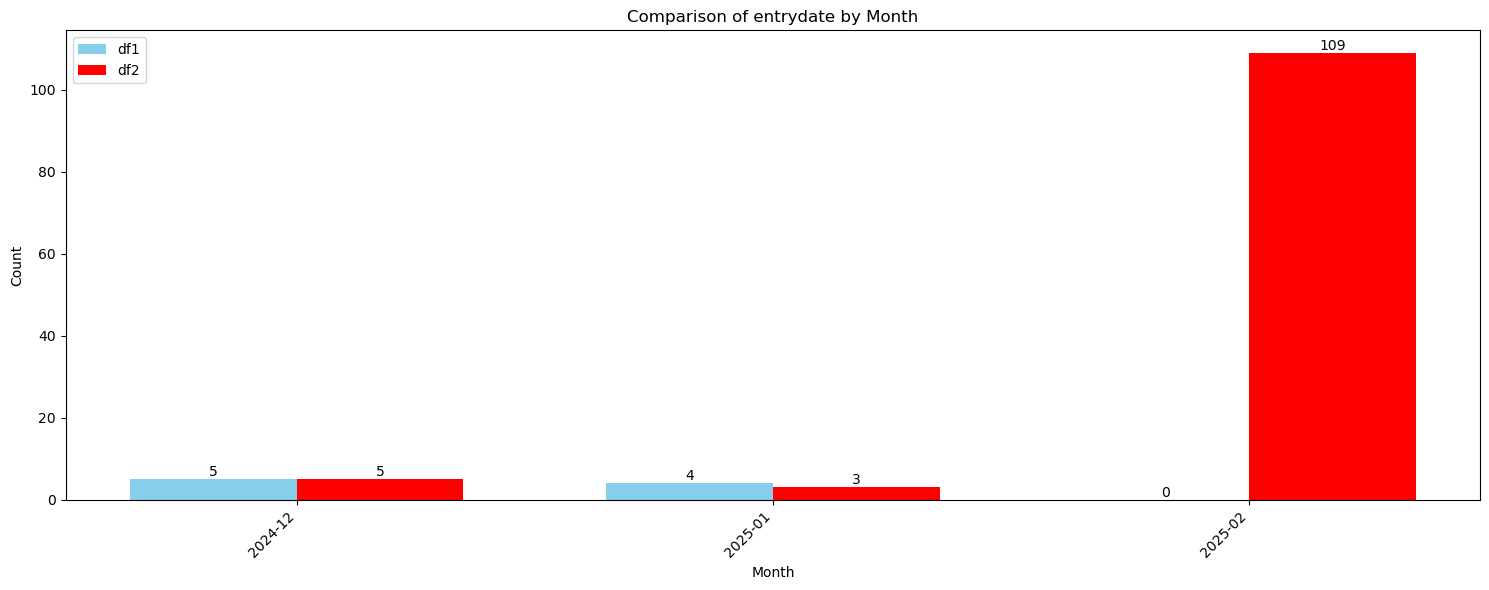

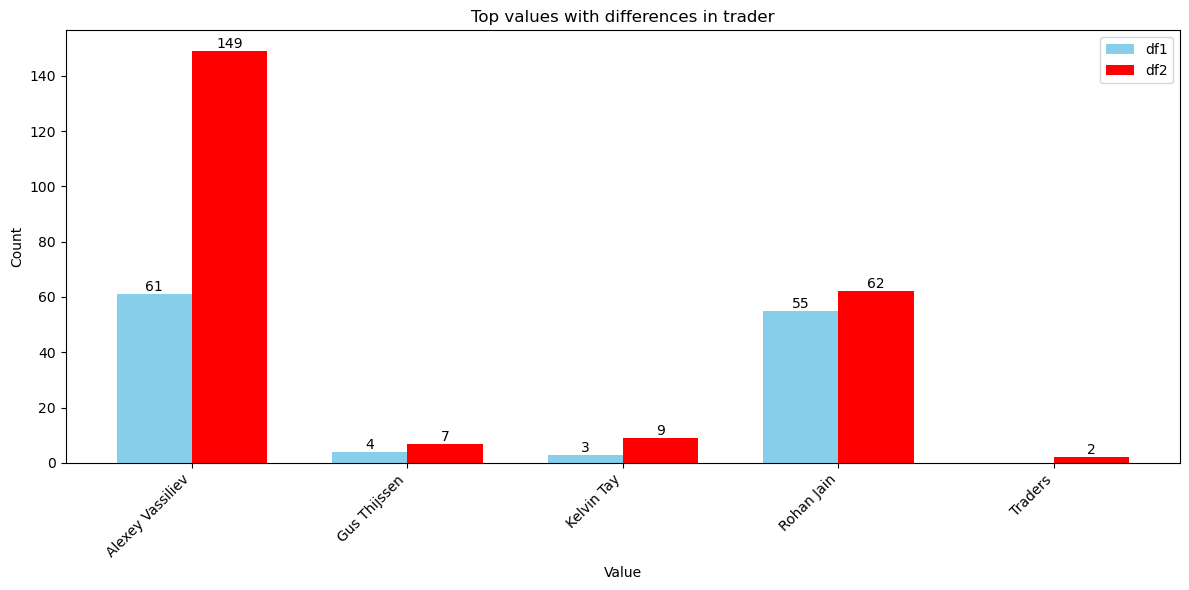

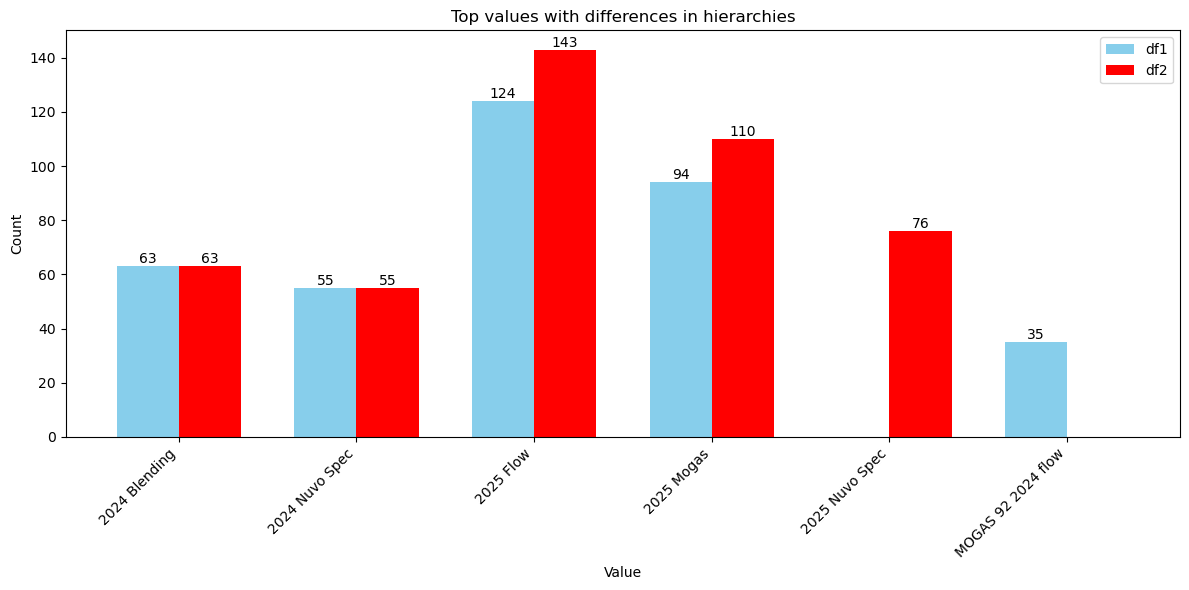

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import calendar

def prepare_label(label, max_length=20):
    return str(label)[:max_length] + '...' if len(str(label)) > max_length else str(label)

from scipy.stats import gaussian_kde

def plot_numeric_differences(data1, data2, col, bins=20, density=True):
    plt.figure(figsize=(12, 6))
    
    # Remove inf and nan values
    data1 = data1[np.isfinite(data1)]
    data2 = data2[np.isfinite(data2)]
    
    # Calculate the range for both datasets
    min_val = min(data1.min(), data2.min())
    max_val = max(data1.max(), data2.max())
    
    # Create histogram bins
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    
    # Plot histograms
    plt.hist(data1, bins=bin_edges, color='skyblue', alpha=0.6, density=density, label='df1')
    plt.hist(data2, bins=bin_edges, color='red', alpha=0.6, density=density, label='df2')
    
    # Add KDE (similar to sns.histplot with kde=True)
    if density and len(data1) > 0 and len(data2) > 0:
        x_range = np.linspace(min_val, max_val, 300)
        if len(data1) > 1:
            kde1 = gaussian_kde(data1)
            plt.plot(x_range, kde1(x_range), color='blue', linewidth=2)
        if len(data2) > 1:
            kde2 = gaussian_kde(data2)
            plt.plot(x_range, kde2(x_range), color='darkred', linewidth=2)
    
    plt.title(f"Distribution of differences in {col}")
    plt.xlabel("Value")
    plt.ylabel("Density" if density else "Count")
    plt.legend()
    
    # Adjust y-axis to show the full height of the histogram bars
    plt.ylim(bottom=0)
    
    plt.tight_layout()

def plot_categorical_differences(data1, data2, col):
    top_5_1 = data1.value_counts().nlargest(5)
    top_5_2 = data2.value_counts().nlargest(5)
    
    plt.figure(figsize=(12, 6))
    
    # Get the union of top 5 categories from both datasets
    all_categories = list(set(top_5_1.index) | set(top_5_2.index))
    all_categories.sort()  # Sort for consistent ordering
    x = range(len(all_categories))
    width = 0.35
    
    # Prepare data for plotting
    values_1 = [top_5_1.get(cat, 0) for cat in all_categories]
    values_2 = [top_5_2.get(cat, 0) for cat in all_categories]
    
    plt.bar([i - width/2 for i in x], values_1, width, label='df1', color='skyblue')
    plt.bar([i + width/2 for i in x], values_2, width, label='df2', color='red')
    
    plt.title(f"Top values with differences in {col}")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.xticks(x, [prepare_label(label) for label in all_categories], rotation=45, ha='right')
    
    for i, v in enumerate(values_1):
        if v > 0:
            plt.text(i - width/2, v, str(v), ha='center', va='bottom')
    for i, v in enumerate(values_2):
        if v > 0:
            plt.text(i + width/2, v, str(v), ha='center', va='bottom')
    
    plt.legend()
    plt.tight_layout()
    

def plot_date_differences(data1, data2, col):
    # Convert string dates to datetime
    data1 = pd.to_datetime(data1, errors='coerce')
    data2 = pd.to_datetime(data2, errors='coerce')

    # Group by month and count
    counts1 = data1.groupby(data1.dt.to_period('M')).size().reset_index(name='count')
    counts2 = data2.groupby(data2.dt.to_period('M')).size().reset_index(name='count')

    # Rename the period column to a common name for merging
    counts1 = counts1.rename(columns={counts1.columns[0]: 'period'})
    counts2 = counts2.rename(columns={counts2.columns[0]: 'period'})

    # Merge the two datasets
    merged = pd.merge(counts1, counts2, on='period', how='outer', suffixes=('_1', '_2')).fillna(0)
    
    # Convert period to string for plotting
    merged['month'] = merged['period'].astype(str)
    merged = merged.sort_values('period')

    # Prepare data for plotting
    months = merged['month']
    counts1 = merged['count_1']
    counts2 = merged['count_2']

    # Create the plot
    plt.figure(figsize=(15, 6))
    
    x = range(len(months))
    width = 0.35

    plt.bar([i - width/2 for i in x], counts1, width, label='df1', color='skyblue')
    plt.bar([i + width/2 for i in x], counts2, width, label='df2', color='red')

    plt.xlabel('Month')
    plt.ylabel('Count')
    plt.title(f'Comparison of {col} by Month')
    plt.xticks(x, months, rotation=45, ha='right')
    plt.legend()

    # Add value labels on the bars
    for i, v in enumerate(counts1):
        plt.text(i - width/2, v, str(int(v)), ha='center', va='bottom')
    for i, v in enumerate(counts2):
        plt.text(i + width/2, v, str(int(v)), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
    
def visualize_differences(merged, diff_columns):
    for col in diff_columns:
        diff_mask = merged[f'diff_{col}'] == True
        data1 = merged.loc[diff_mask, f'{col}_1']
        data2 = merged.loc[diff_mask, f'{col}_2']
        
        if 'date' in col.lower():
            plot_date_differences(data1, data2, col)
            continue
            
        
        # Check if the column can be converted to numeric
        try:
            data1 = pd.to_numeric(data1, errors='raise')
            data2 = pd.to_numeric(data2, errors='raise')
            is_numeric = True
        except (ValueError, TypeError):
            is_numeric = False
        if is_numeric and (data1.nunique() > 5 or data2.nunique() > 5):
            plot_numeric_differences(data1, data2, col)
        else:
            plot_categorical_differences(data1, data2, col)
        
        plt.tight_layout()
        plt.show()

# Usage
visualize_differences(merged, diff_columns)